In [4]:
install.packages(c("rstatix", "svglite", "ez", "ggbeeswarm", "gridExtra"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘rbibutils’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘corrplot’, ‘car’, ‘lme4’, ‘plyr’, ‘reshape2’, ‘beeswarm’, ‘vipor’




In [3]:
library(rstatix)
library(svglite)
library(ez)
library(ggplot2)
library(ggbeeswarm)
library(gridExtra)

ERROR: Error in library(rstatix): there is no package called ‘rstatix’


## Load and prepare the data

In [ ]:
df.surveys <- read.csv('csv/surveys.csv', sep=',')
df.conditions <- read.csv('csv/conditions.csv', sep=',')
df.participants <- read.csv('csv/participants.csv', sep=',')

# Filter out to only have valid participants
valid_participants <- df.participants$participantID[df.participants$valid == 'Yes']
print(valid_participants)
print(paste("Number of valid participants:", length(valid_participants)))

# Filter all dataframes to only include valid participants
df.surveys <- df.surveys[df.surveys$participantID %in% valid_participants,]
df.conditions <- df.conditions[df.conditions$participantID %in% valid_participants,]
df.conditions <- df.conditions[df.conditions$participantID %in% valid_participants,]


 [1]  1  2  4  5  6  7  8 10 11 12 13 14 17 18 19 20 21 22 23 24 26 27 28 29
[1] "Number of valid participants: 24"


# Demographics and prior knowledge

Figure 2: Prior knowledge

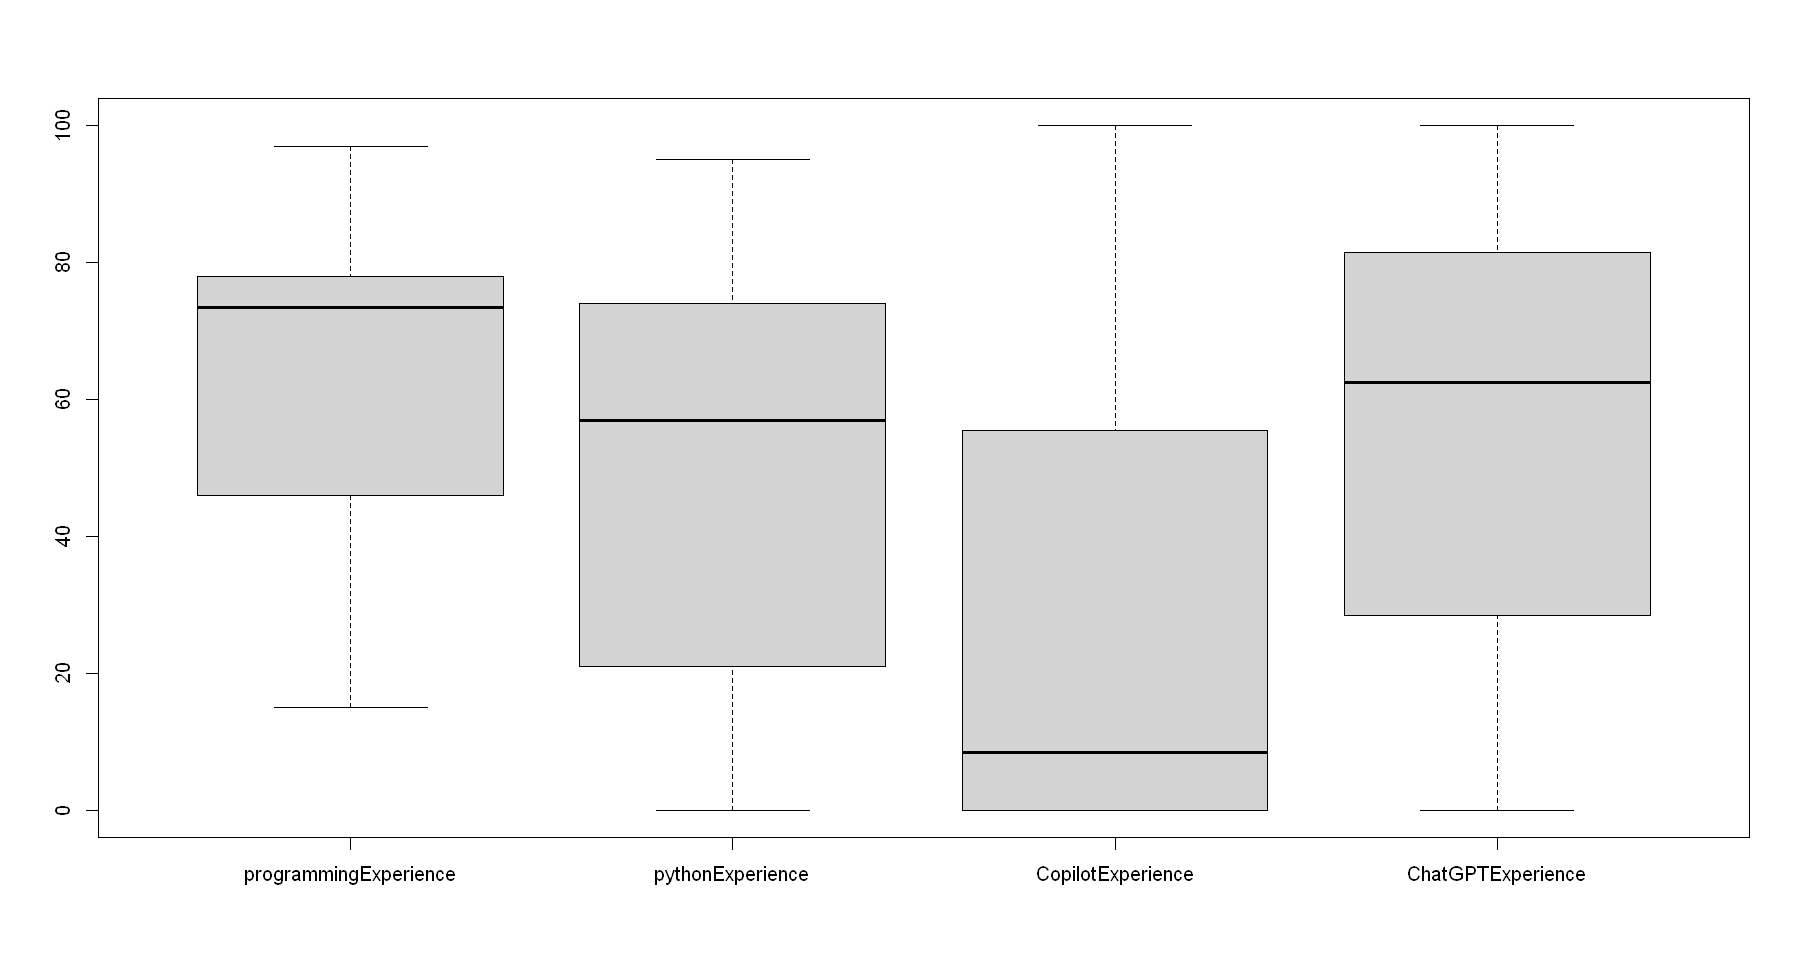

In [ ]:
boxplot(df.surveys[c(
  'programmingExperience',
  'pythonExperience',
  'CopilotExperience',
  'ChatGPTExperience'
)])

# Data collected for each conditions

### Task-completion time

In [ ]:
# Preprocess datetimes to be in POSIXct format
df.conditions$speed.task.start <- as.POSIXct (df.conditions$speedTaskTimeStart, format="%d.%m.%Y %H:%M:%S")
df.conditions$speed.task.end <- as.POSIXct(df.conditions$speedTaskTimeEnd, format="%d.%m.%Y %H:%M:%S")
df.conditions$total.task.time <- difftime(df.conditions$speed.task.end, df.conditions$speed.task.start, units = "secs")


	Shapiro-Wilk normality test

data:  as.numeric(df.conditions$total.task.time)
W = 0.71387, p-value = 1.508e-10



	Friedman rank sum test

data:  as.numeric(total.task.time) and environmentName and participantID
Friedman chi-squared = 6.5833, df = 2, p-value = 0.03719

# A tibble: 1 × 5
  .y.                             n effsize method    magnitude
* <chr>                       <int>   <dbl> <chr>     <ord>    
1 as.numeric(total.task.time)    24   0.137 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  as.numeric(df.conditions$total.task.time) and df.conditions$environmentName 

               autocomplete control
control        0.028        -      
conversational 1.000        0.025  

P value adjustment method: bonferroni 


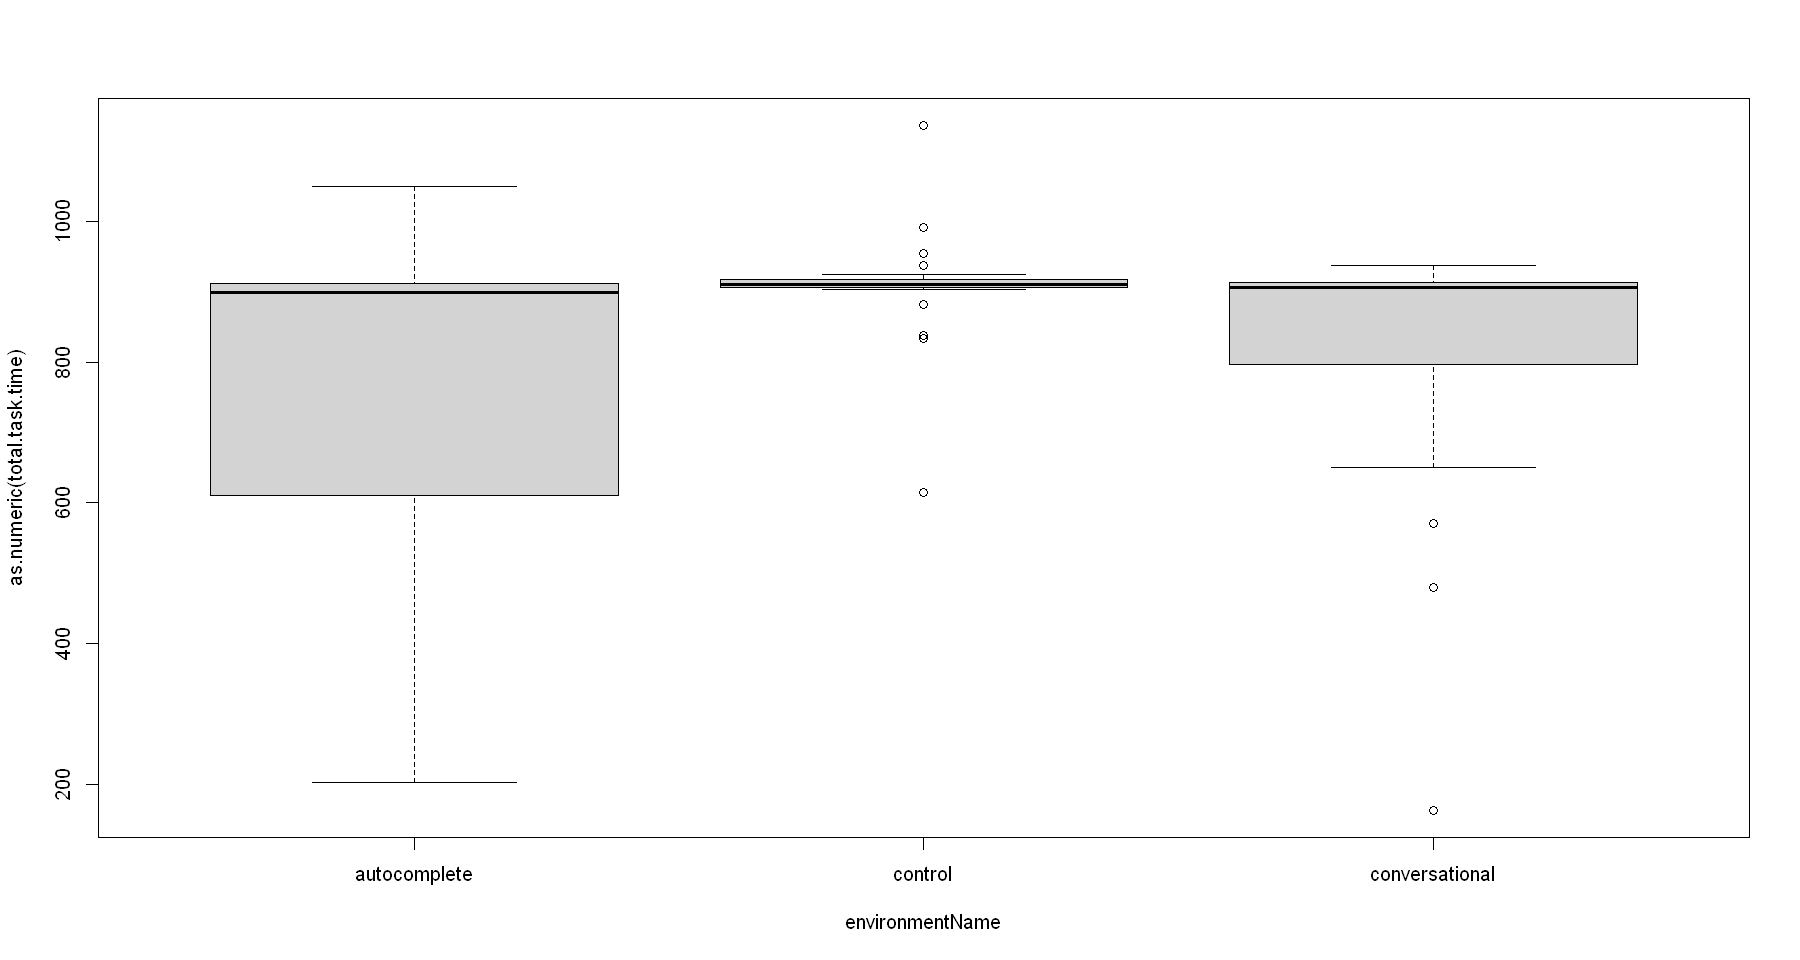

In [ ]:
boxplot(as.numeric(total.task.time) ~ environmentName, data = df.conditions)

shapiro.test(as.numeric(df.conditions$total.task.time))

# Effect of the AI tools on task completion time
f <- friedman.test(as.numeric(total.task.time) ~ environmentName | participantID, data = df.conditions)
print(f)

f.effect <- friedman_effsize(as.numeric(total.task.time) ~ environmentName | participantID, data = df.conditions)
print(f.effect)

wilcox <- pairwise.wilcox.test(as.numeric(df.conditions$total.task.time), df.conditions$environmentName, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)



# SPACE Framework Categories

### Satisfaction 


	Shapiro-Wilk normality test

data:  cond.satisfaction$satisfaction
W = 0.95313, p-value = 0.009194



	Friedman rank sum test

data:  satisfaction and env and pid
Friedman chi-squared = 21.447, df = 2, p-value = 2.202e-05

# A tibble: 1 × 5
  .y.              n effsize method    magnitude
* <chr>        <int>   <dbl> <chr>     <ord>    
1 satisfaction    24   0.447 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction$satisfaction and cond.satisfaction$env 

               autocomplete control
control        0.00051      -      
conversational 1.00000      0.00212

P value adjustment method: bonferroni 


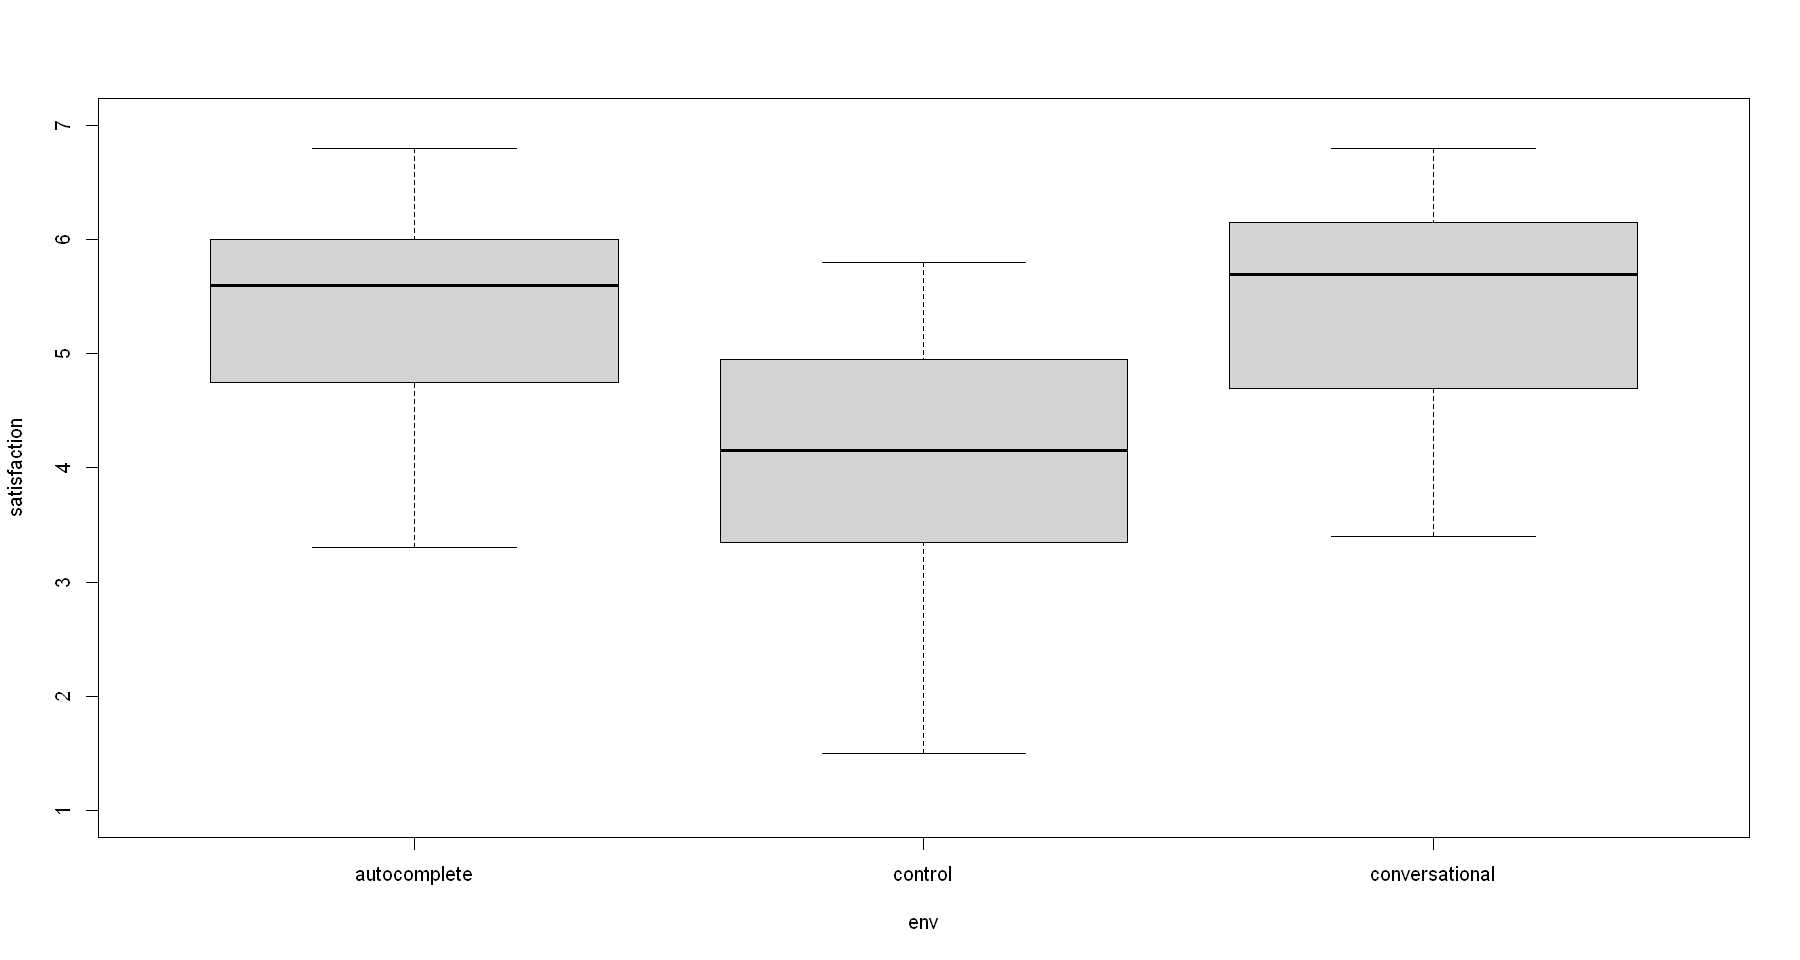

In [ ]:
# Select subset of the data related to the AttrakDiff questionnaire
cond.satisfaction <- data.frame(
  simple = df.conditions$satisfactionSimpleComplicated,
  attractive = df.conditions$satisfactionUglyAttractive,
  practical = df.conditions$satisfactionPracticalImpractical,
  stylish = df.conditions$satisfactionStylishTacky,
  predictable = df.conditions$satisfactionPredictableUnpredictable,
  premium = df.conditions$satisfactionCheapPremium,
  creative = df.conditions$satisfactionUnimaginativeCreative,
  good = df.conditions$satisfactionGoodBad,
  structured = df.conditions$satisfactionConfusingClearlyStructured,
  captivating = df.conditions$satisfactionDullCaptivating)

attrakdiff.categories = names(cond.satisfaction)

# Calcualte the different categories of the AttrakDiff for each participant
cond.satisfaction$satisfaction <- rowMeans(cond.satisfaction)

cond.satisfaction$pq <- rowMeans(data.frame(
  simple = df.conditions$satisfactionSimpleComplicated,
  practical = df.conditions$satisfactionPracticalImpractical,
  predictable = df.conditions$satisfactionPredictableUnpredictable,
  structured = df.conditions$satisfactionConfusingClearlyStructured
))

cond.satisfaction$hq <- rowMeans(data.frame(
  stylish = df.conditions$satisfactionStylishTacky,
  premium = df.conditions$satisfactionCheapPremium,
  creative = df.conditions$satisfactionUnimaginativeCreative,
  captivating = df.conditions$satisfactionDullCaptivating
))

cond.satisfaction$att <- rowMeans(data.frame(
  attractive = df.conditions$satisfactionUglyAttractive,
  good = df.conditions$satisfactionGoodBad
))
cond.satisfaction$env <- df.conditions$environmentName
cond.satisfaction$pid <- df.conditions$participantID

boxplot(satisfaction ~ env, data = cond.satisfaction, ylim=c(1, 7))

shapiro.test(cond.satisfaction$satisfaction)

f <- friedman.test(satisfaction ~ env | pid, data = cond.satisfaction)
print(f)

f.effect <- friedman_effsize(satisfaction ~ env | pid, data = cond.satisfaction)
print(f.effect)

wilcox <- pairwise.wilcox.test(cond.satisfaction$satisfaction, cond.satisfaction$env, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)


	Shapiro-Wilk normality test

data:  cond.satisfaction$pq
W = 0.91736, p-value = 0.0001636



	Friedman rank sum test

data:  pq and env and pid
Friedman chi-squared = 7.4667, df = 2, p-value = 0.02391

# A tibble: 1 × 5
  .y.       n effsize method    magnitude
* <chr> <int>   <dbl> <chr>     <ord>    
1 pq       24   0.156 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction$pq and cond.satisfaction$env 

               autocomplete control
control        0.027        -      
conversational 1.000        0.064  

P value adjustment method: bonferroni 


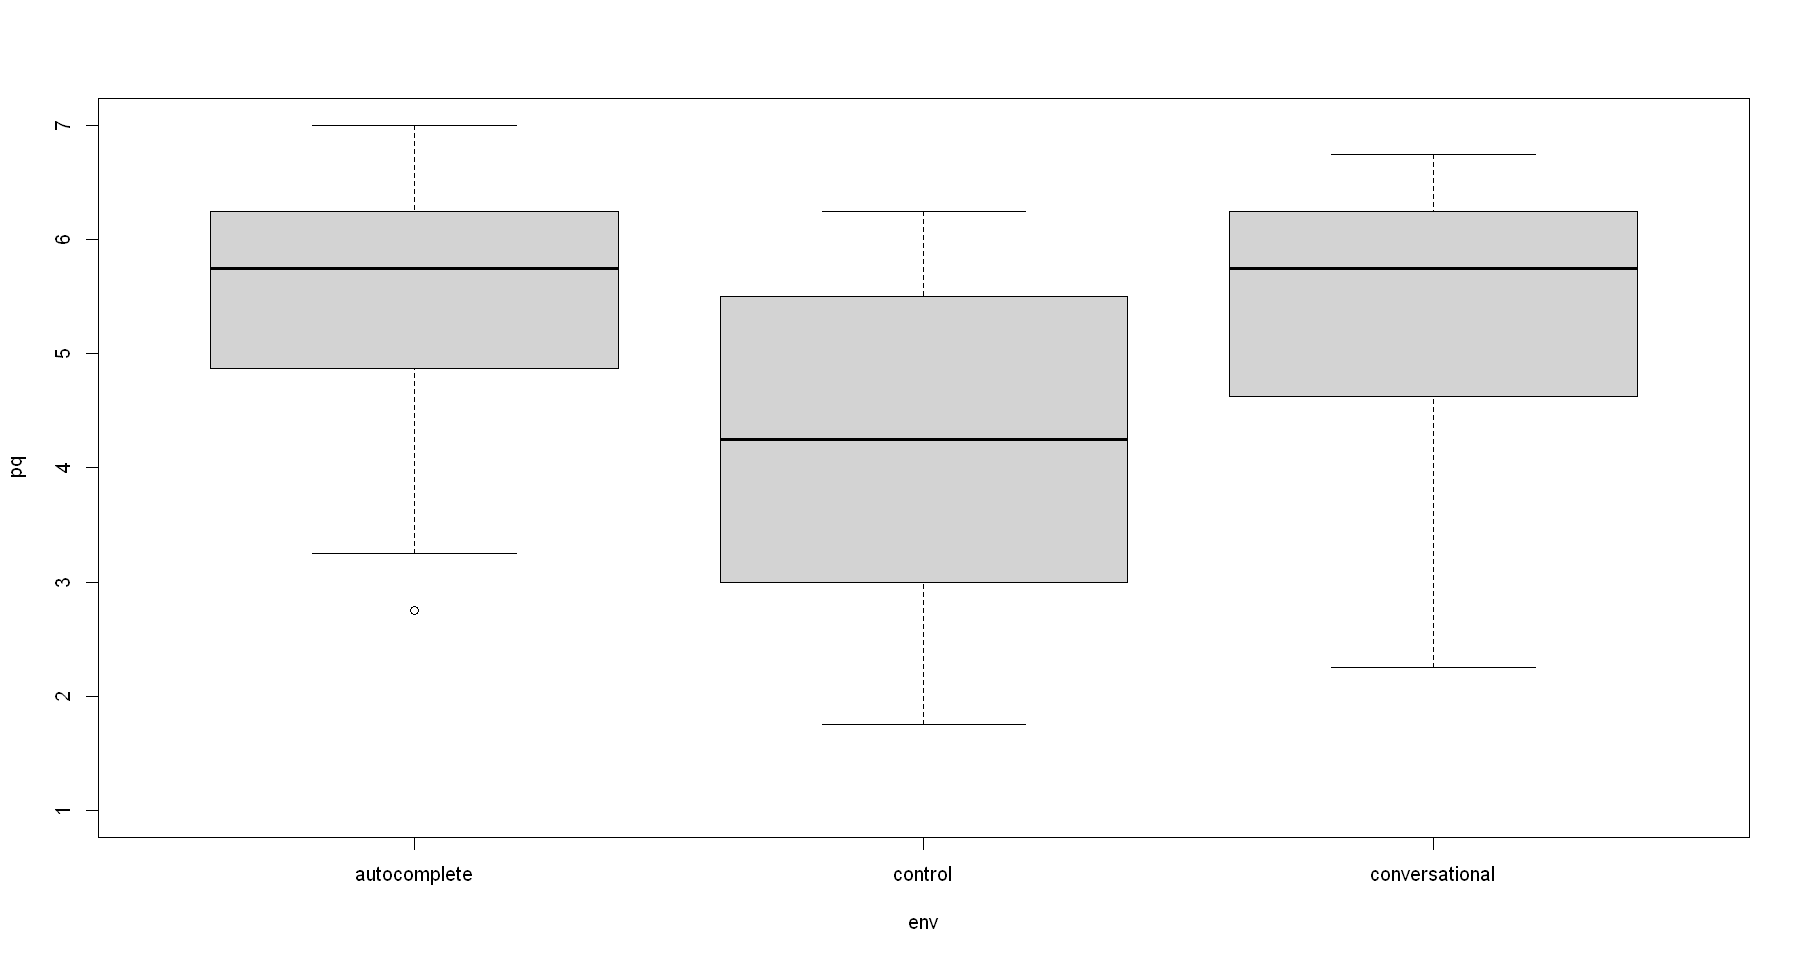


	Shapiro-Wilk normality test

data:  cond.satisfaction$hq
W = 0.97863, p-value = 0.259



	Friedman rank sum test

data:  hq and env and pid
Friedman chi-squared = 20.667, df = 2, p-value = 3.253e-05

# A tibble: 1 × 5
  .y.       n effsize method    magnitude
* <chr> <int>   <dbl> <chr>     <ord>    
1 hq       24   0.431 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction$hq and cond.satisfaction$env 

               autocomplete control
control        0.00051      -      
conversational 1.00000      0.00015

P value adjustment method: bonferroni 


Warning message:
"Converting "pid" to factor for ANOVA."
Warning message:
"Converting "env" to factor for ANOVA."


$ANOVA
  Effect DFn DFd        F            p p<.05       ges
2    env   2  46 19.76411 6.381357e-07     * 0.3485917

$`Mauchly's Test for Sphericity`
  Effect         W         p p<.05
2    env 0.8840159 0.2576683      

$`Sphericity Corrections`
  Effect       GGe        p[GG] p[GG]<.05       HFe        p[HF] p[HF]<.05
2    env 0.8960701 2.058857e-06         * 0.9668907 9.264635e-07         *


	Pairwise comparisons using paired t tests 

data:  cond.satisfaction$hq and cond.satisfaction$env 

               autocomplete control
control        0.00031      -      
conversational 1.00000      4e-05  

P value adjustment method: bonferroni 


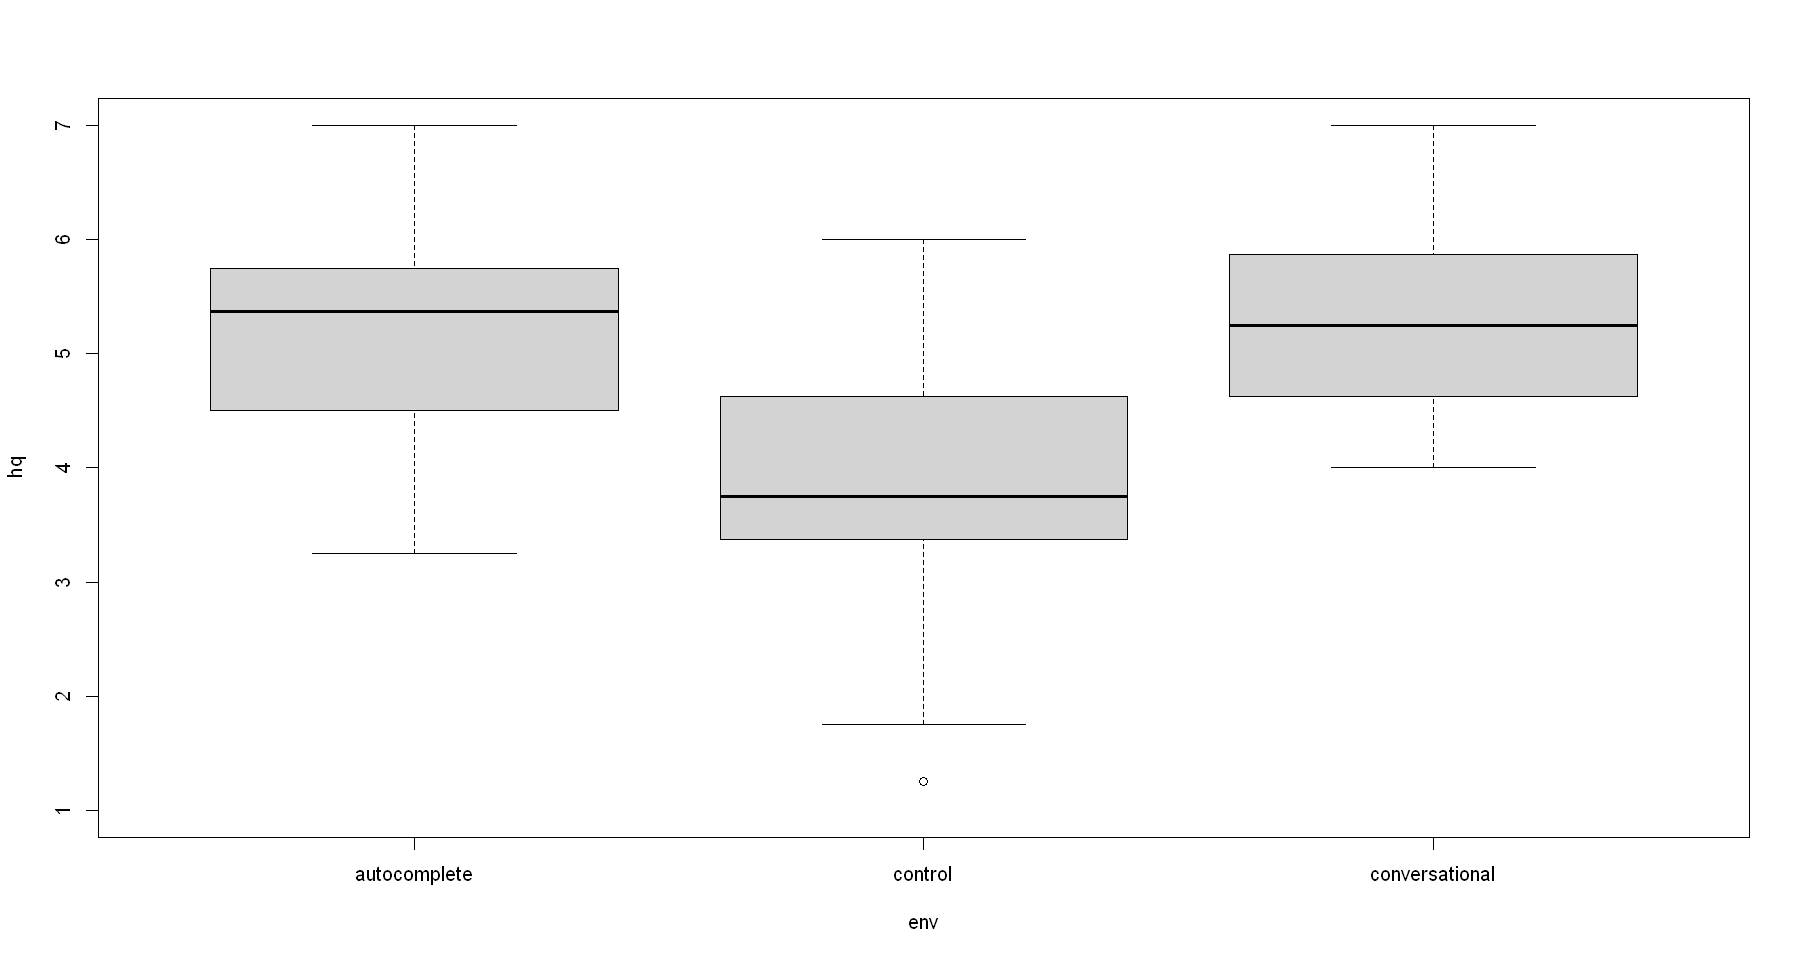


	Shapiro-Wilk normality test

data:  cond.satisfaction$att
W = 0.92569, p-value = 0.0003876



	Friedman rank sum test

data:  att and env and pid
Friedman chi-squared = 18.782, df = 2, p-value = 8.349e-05

# A tibble: 1 × 5
  .y.       n effsize method    magnitude
* <chr> <int>   <dbl> <chr>     <ord>    
1 att      24   0.391 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction$att and cond.satisfaction$env 

               autocomplete control
control        0.0010       -      
conversational 1.0000       0.0036 

P value adjustment method: bonferroni 


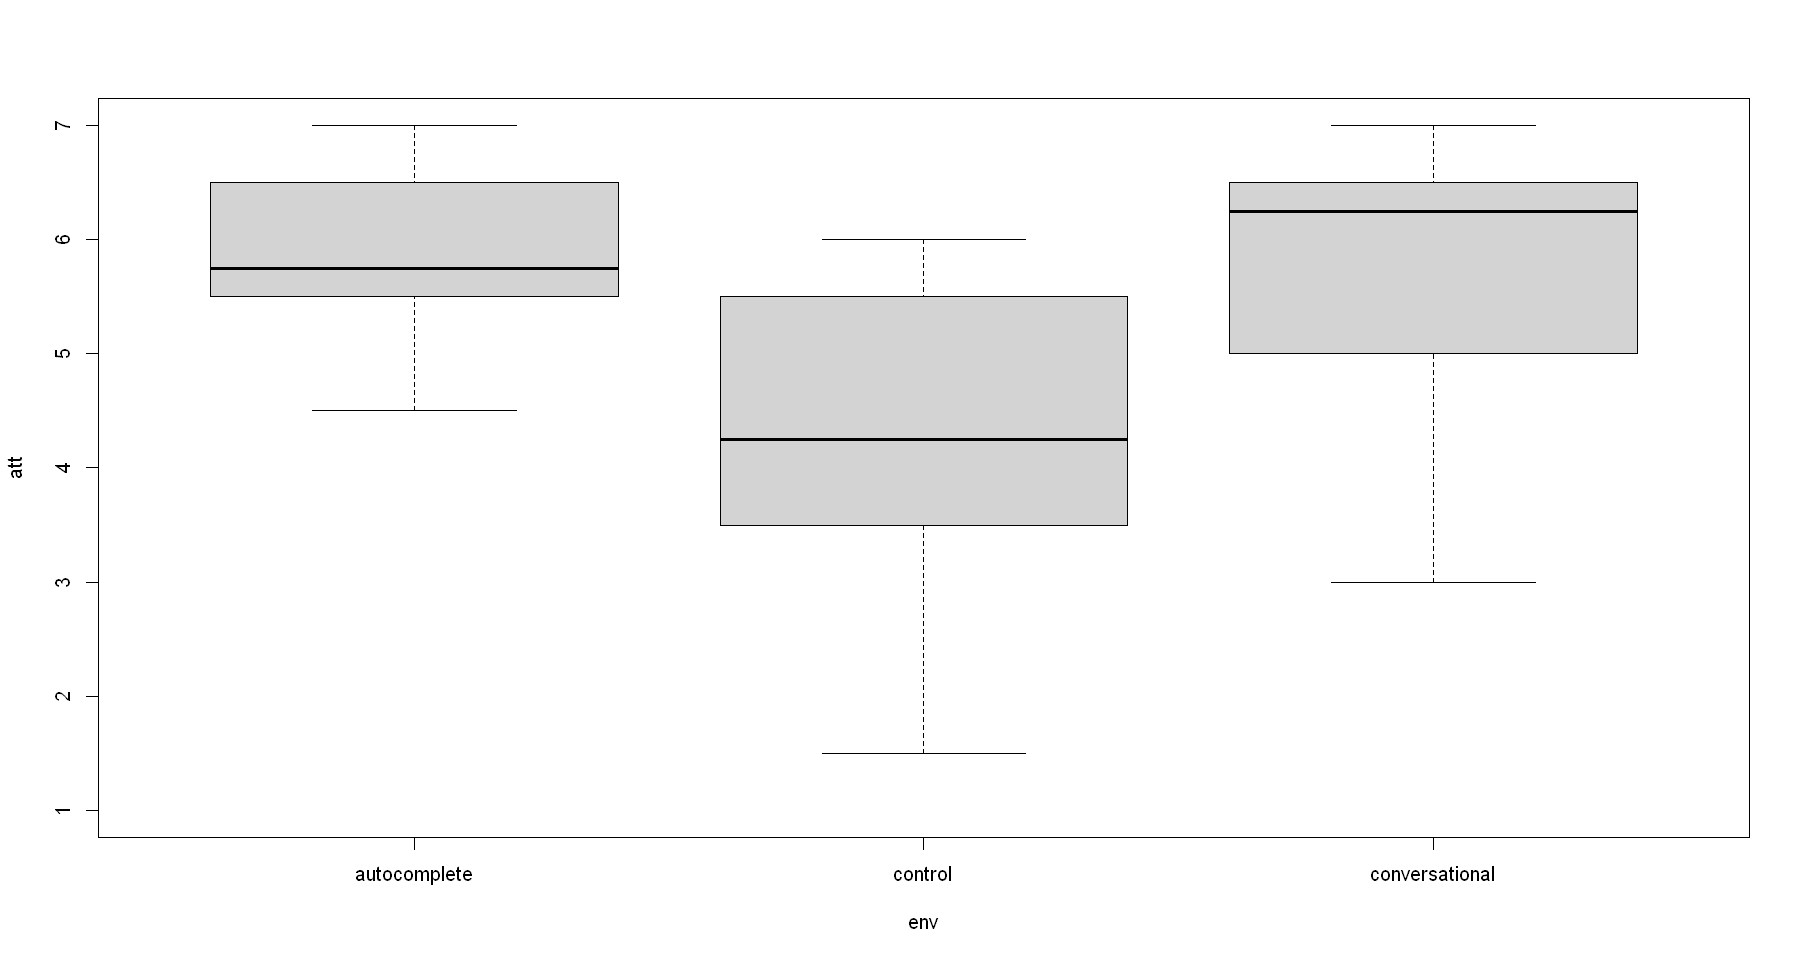

In [ ]:
# Subcategories of the AttrakDiff quesitonniare

# Practical Quality
boxplot(pq ~ env, data = cond.satisfaction, ylim=c(1, 7))

shapiro.test(cond.satisfaction$pq)
f <- friedman.test(pq ~ env | pid, data = cond.satisfaction)
print(f)

f.effect <- friedman_effsize(pq ~ env | pid, data = cond.satisfaction)
print(f.effect)

wilcox <- pairwise.wilcox.test(cond.satisfaction$pq, cond.satisfaction$env, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)

# Hedonic Quality
boxplot(hq ~ env, data = cond.satisfaction, ylim=c(1, 7))

shapiro.test(cond.satisfaction$hq)

f <- friedman.test(hq ~ env | pid, data = cond.satisfaction)
print(f)

f.effect <- friedman_effsize(hq ~ env | pid, data = cond.satisfaction)
print(f.effect)

wilcox <- pairwise.wilcox.test(cond.satisfaction$hq, cond.satisfaction$env, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)

ezANOVA(
  cond.satisfaction, 
  dv=hq,
  wid=pid,
  within=env,
  type=3
)

pairwise.t <- pairwise.t.test(cond.satisfaction$hq, cond.satisfaction$env, p.adj = "bonf", paired=TRUE, exact=F)
print(pairwise.t)

# Attractiveness
boxplot(att ~ env, data = cond.satisfaction, ylim=c(1, 7))

shapiro.test(cond.satisfaction$att)
f <- friedman.test(att ~ env | pid, data = cond.satisfaction)
print(f)

f.effect <- friedman_effsize(att ~ env | pid, data = cond.satisfaction)
print(f.effect)

wilcox <- pairwise.wilcox.test(cond.satisfaction$att, cond.satisfaction$env, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)

[1] "simple"

	Friedman rank sum test

data:  simple and env and pid
Friedman chi-squared = 10.225, df = 2, p-value = 0.006021

# A tibble: 1 × 5
  .y.        n effsize method    magnitude
* <chr>  <int>   <dbl> <chr>     <ord>    
1 simple    24   0.213 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.0048       -      
conversational 1.0000       0.0519 

P value adjustment method: bonferroni 
[1] "attractive"


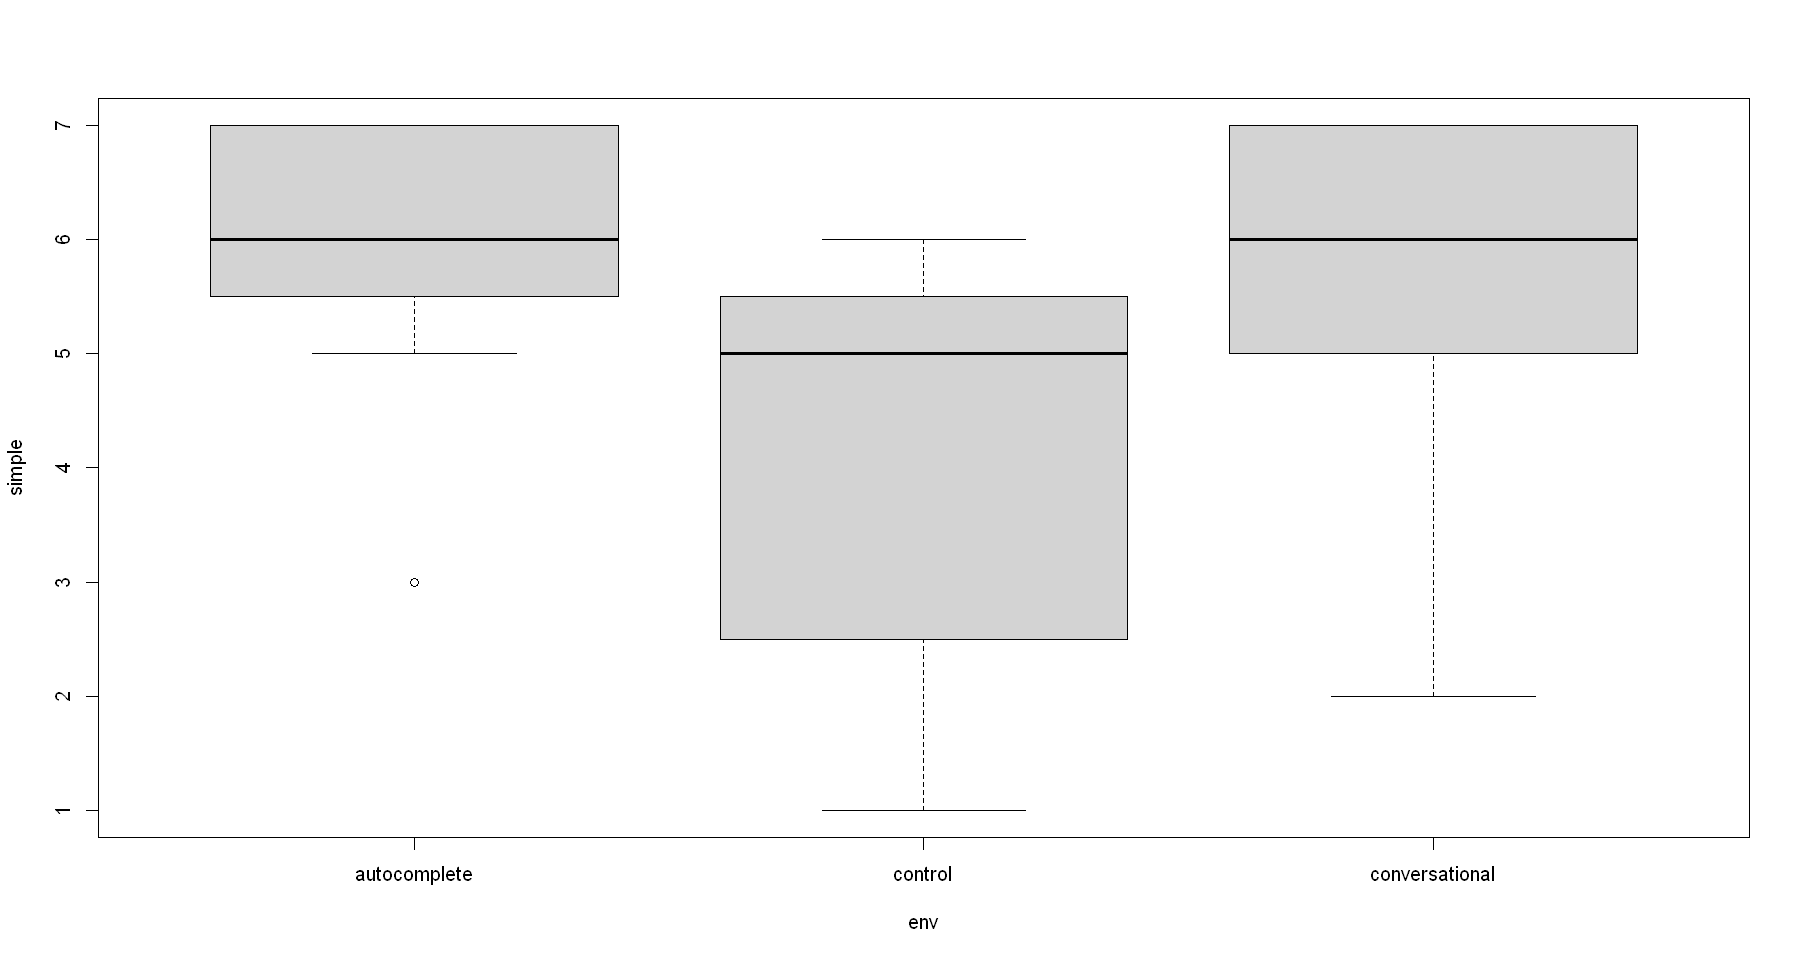


	Friedman rank sum test

data:  attractive and env and pid
Friedman chi-squared = 12.343, df = 2, p-value = 0.002088

# A tibble: 1 × 5
  .y.            n effsize method    magnitude
* <chr>      <int>   <dbl> <chr>     <ord>    
1 attractive    24   0.257 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.0056       -      
conversational 1.0000       0.0107 

P value adjustment method: bonferroni 
[1] "practical"


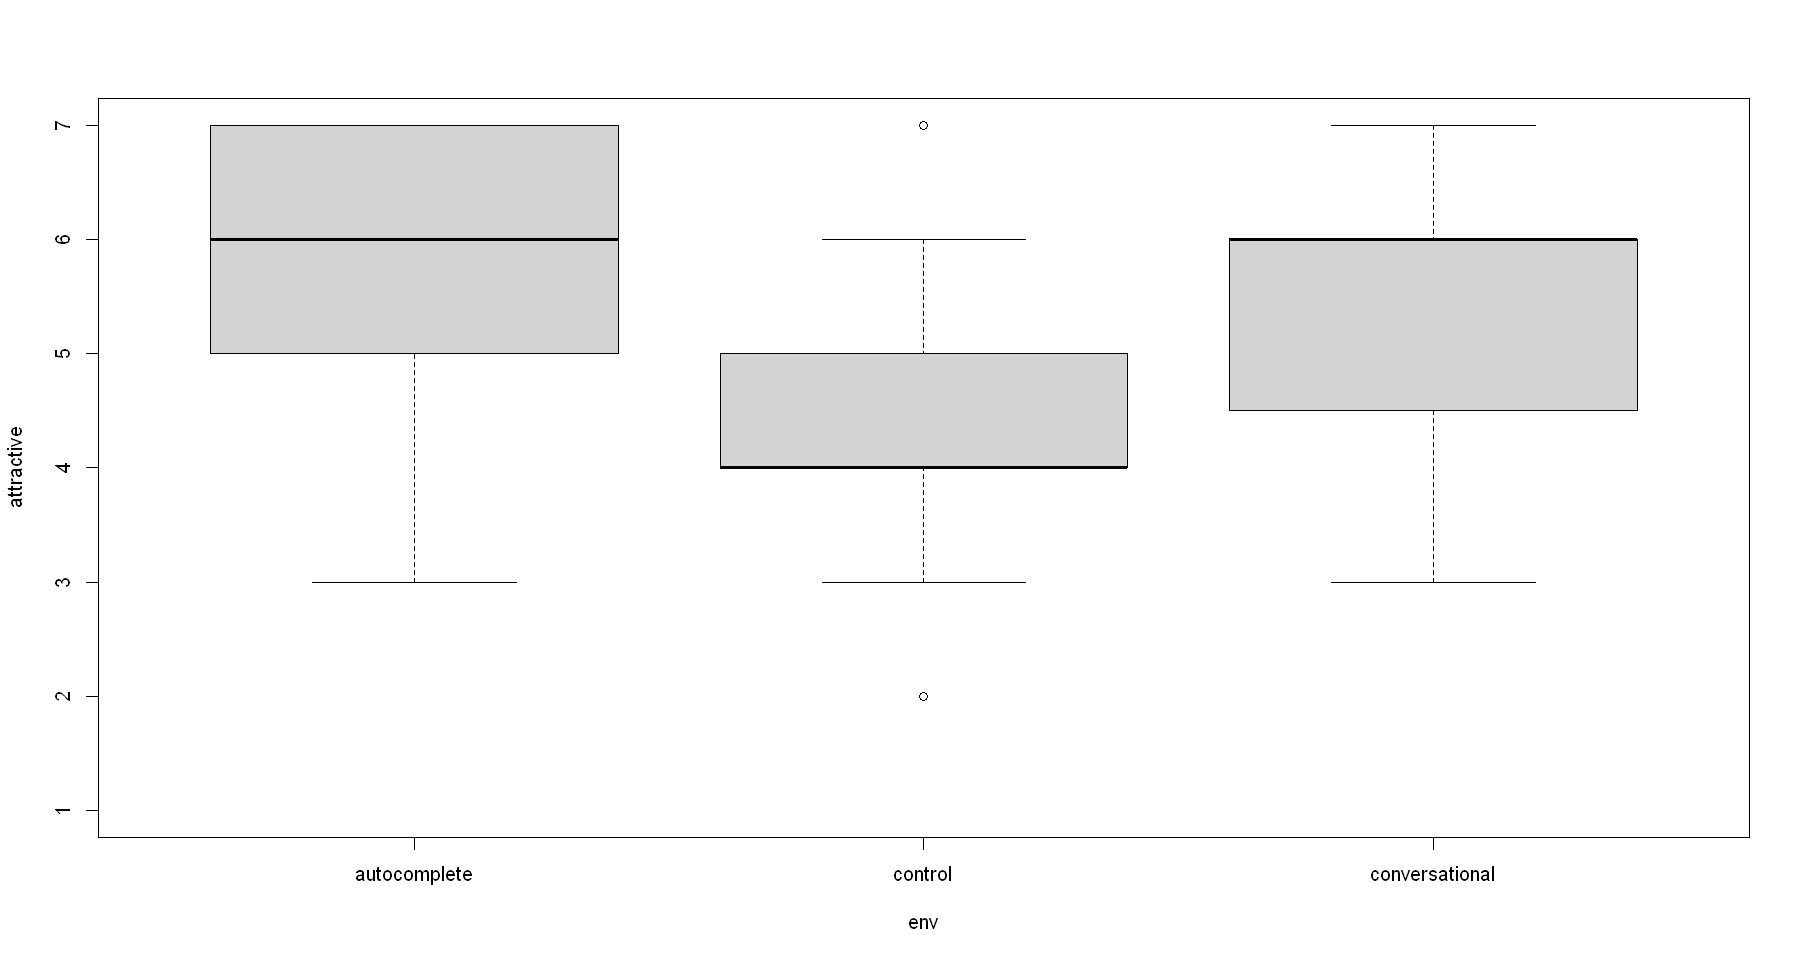


	Friedman rank sum test

data:  practical and env and pid
Friedman chi-squared = 10.64, df = 2, p-value = 0.004893

# A tibble: 1 × 5
  .y.           n effsize method    magnitude
* <chr>     <int>   <dbl> <chr>     <ord>    
1 practical    24   0.222 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.014        -      
conversational 1.000        0.020  

P value adjustment method: bonferroni 
[1] "stylish"


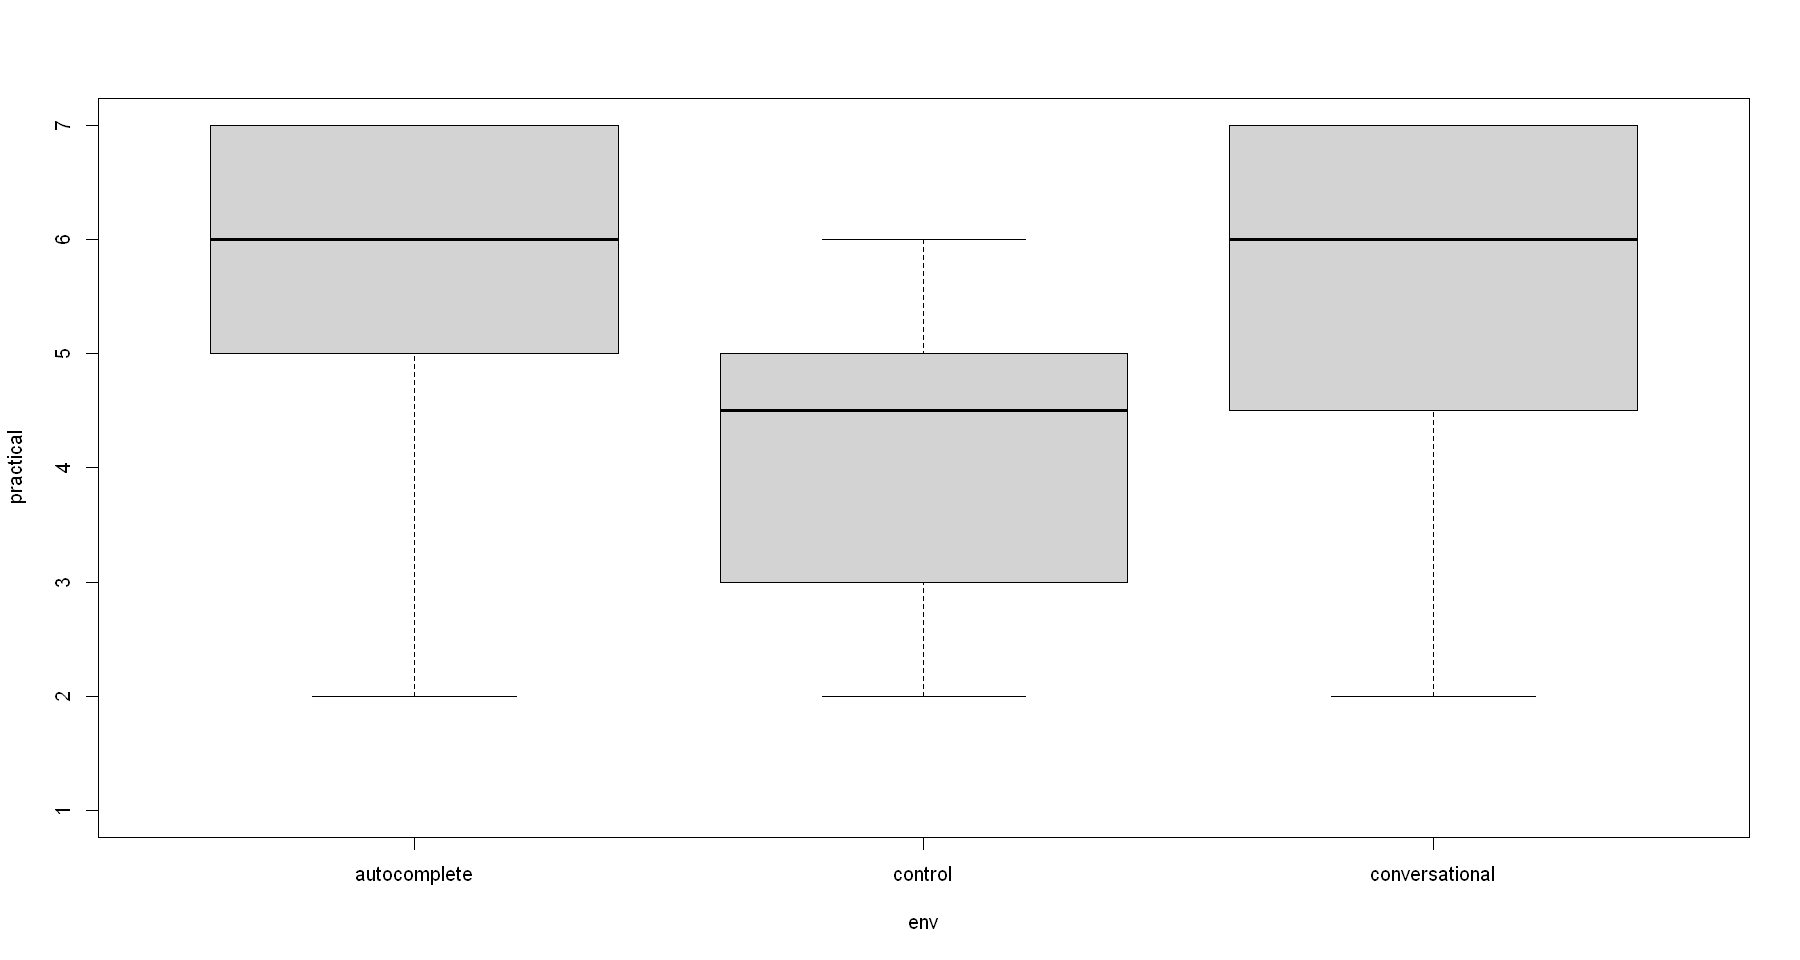


	Friedman rank sum test

data:  stylish and env and pid
Friedman chi-squared = 3.7353, df = 2, p-value = 0.1545

# A tibble: 1 × 5
  .y.         n effsize method    magnitude
* <chr>   <int>   <dbl> <chr>     <ord>    
1 stylish    24  0.0778 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.72         -      
conversational 1.00         0.41   

P value adjustment method: bonferroni 
[1] "predictable"


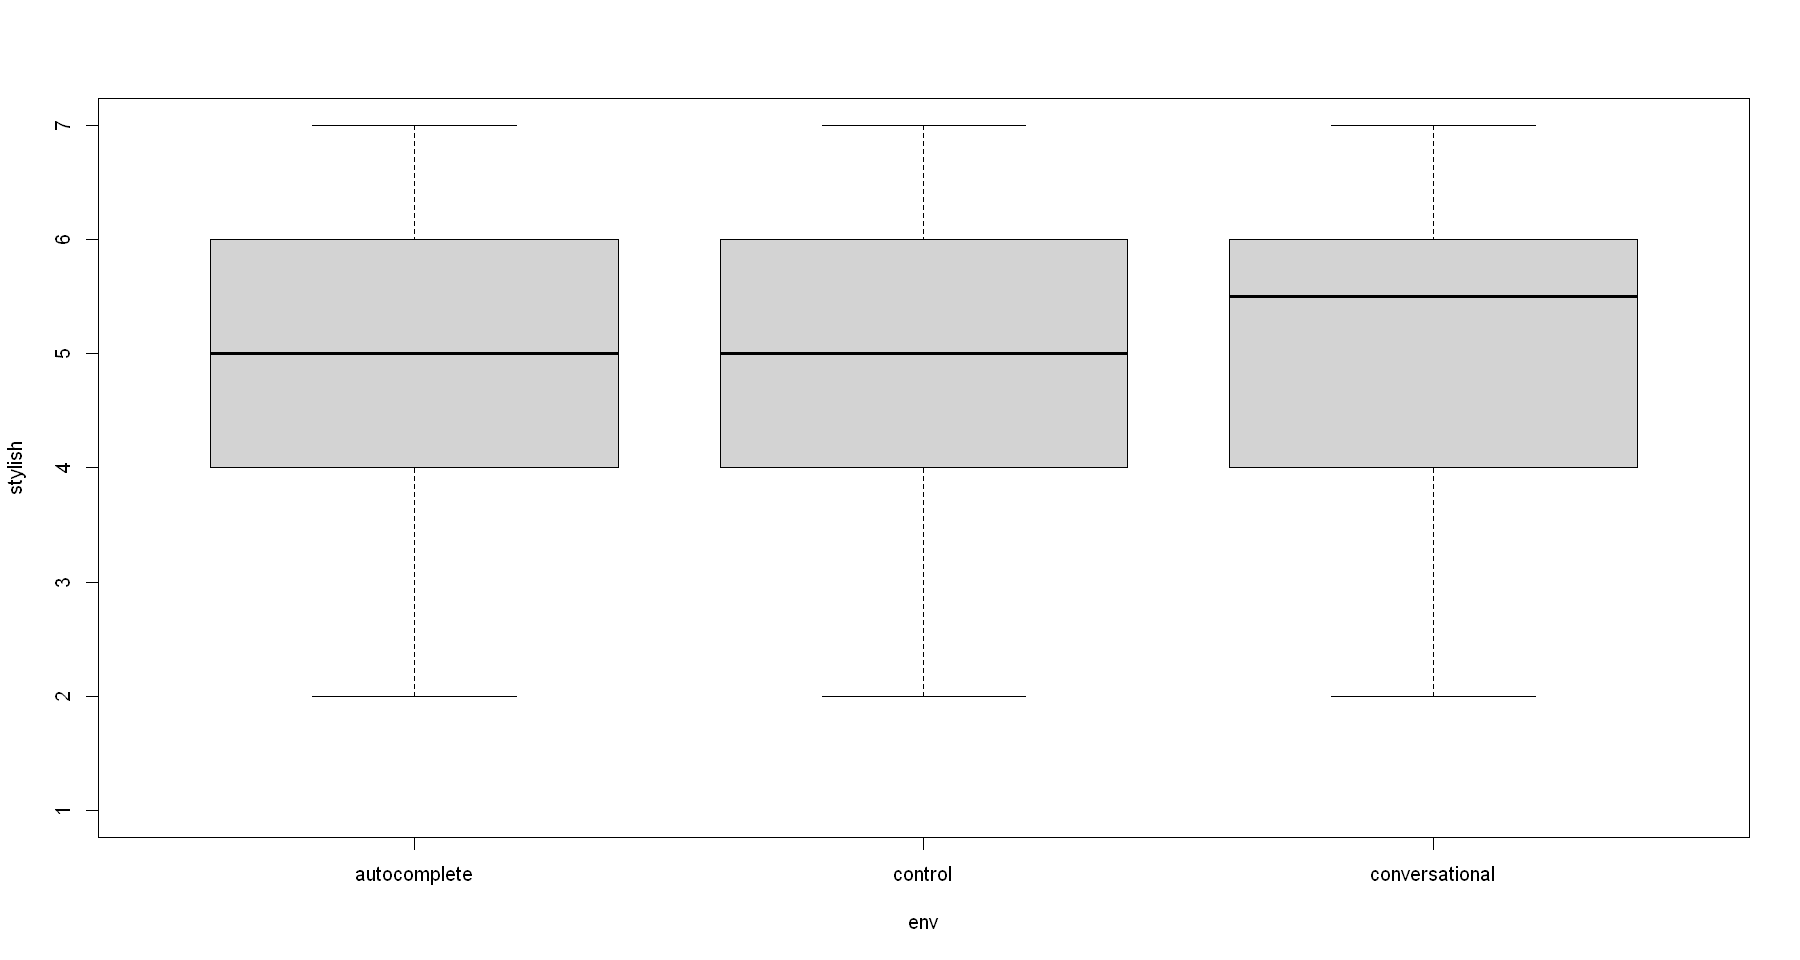


	Friedman rank sum test

data:  predictable and env and pid
Friedman chi-squared = 0.6747, df = 2, p-value = 0.7137

# A tibble: 1 × 5
  .y.             n effsize method    magnitude
* <chr>       <int>   <dbl> <chr>     <ord>    
1 predictable    24  0.0141 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        1            -      
conversational 1            1      

P value adjustment method: bonferroni 
[1] "premium"


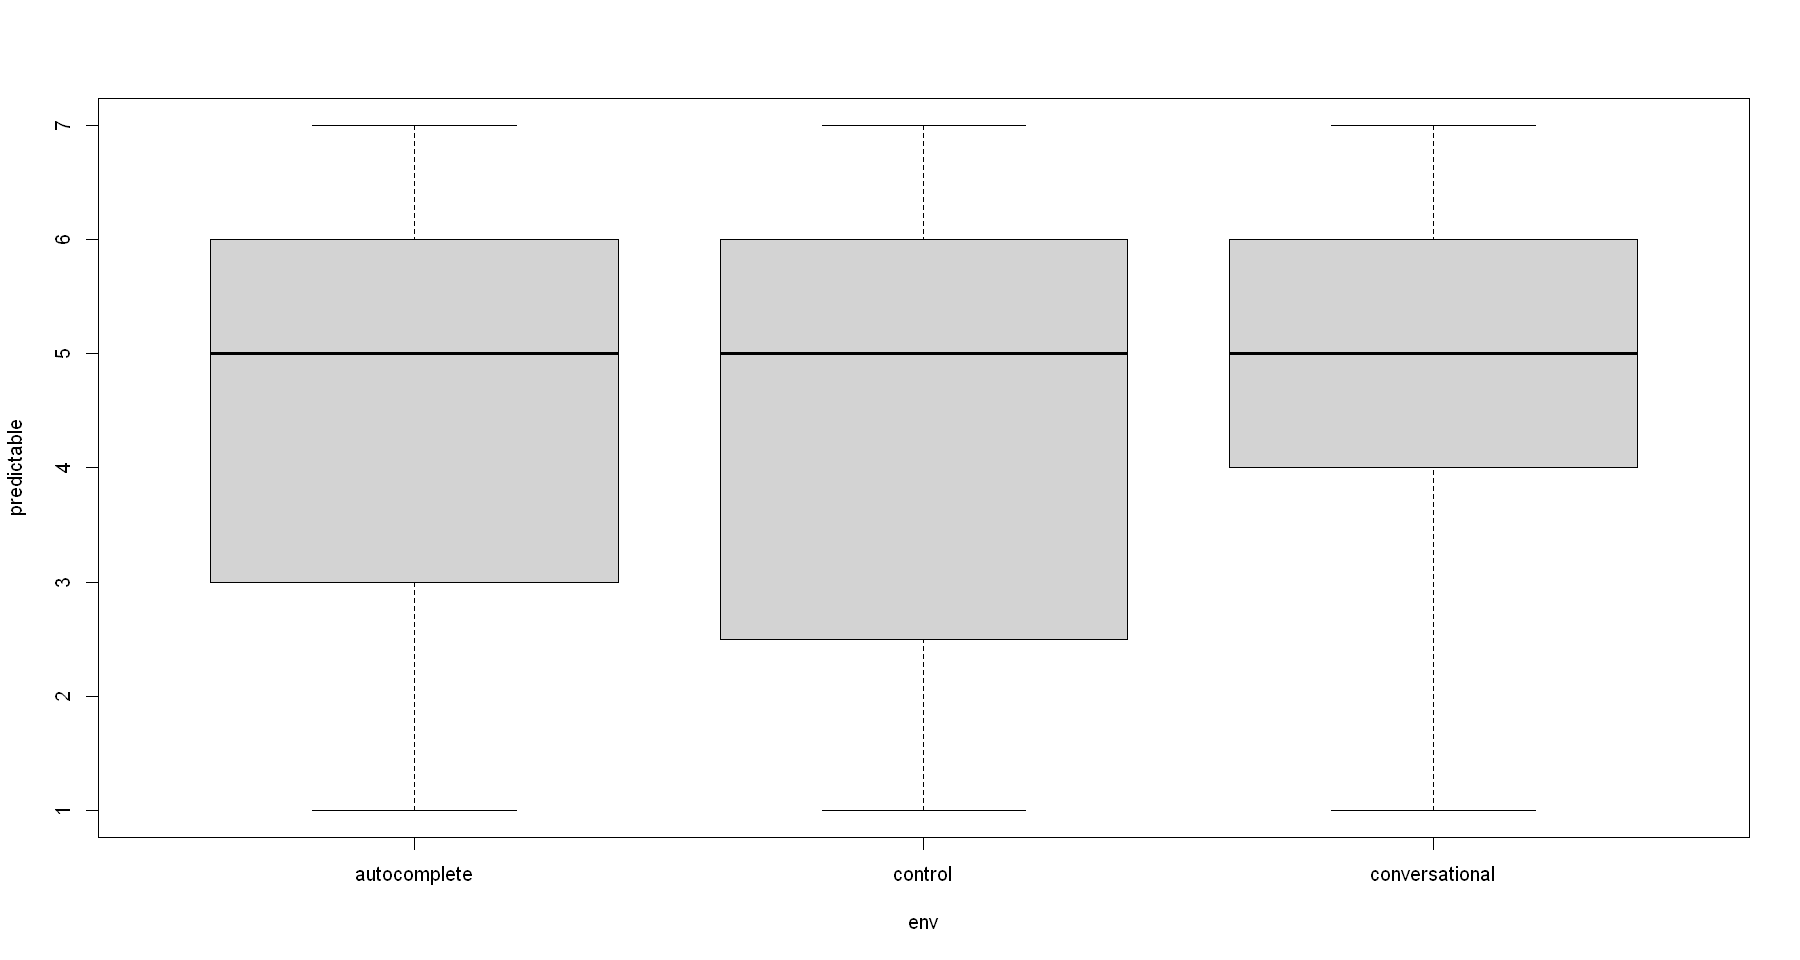


	Friedman rank sum test

data:  premium and env and pid
Friedman chi-squared = 19.785, df = 2, p-value = 5.056e-05

# A tibble: 1 × 5
  .y.         n effsize method    magnitude
* <chr>   <int>   <dbl> <chr>     <ord>    
1 premium    24   0.412 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.0033       -      
conversational 1.0000       0.0019 

P value adjustment method: bonferroni 
[1] "creative"


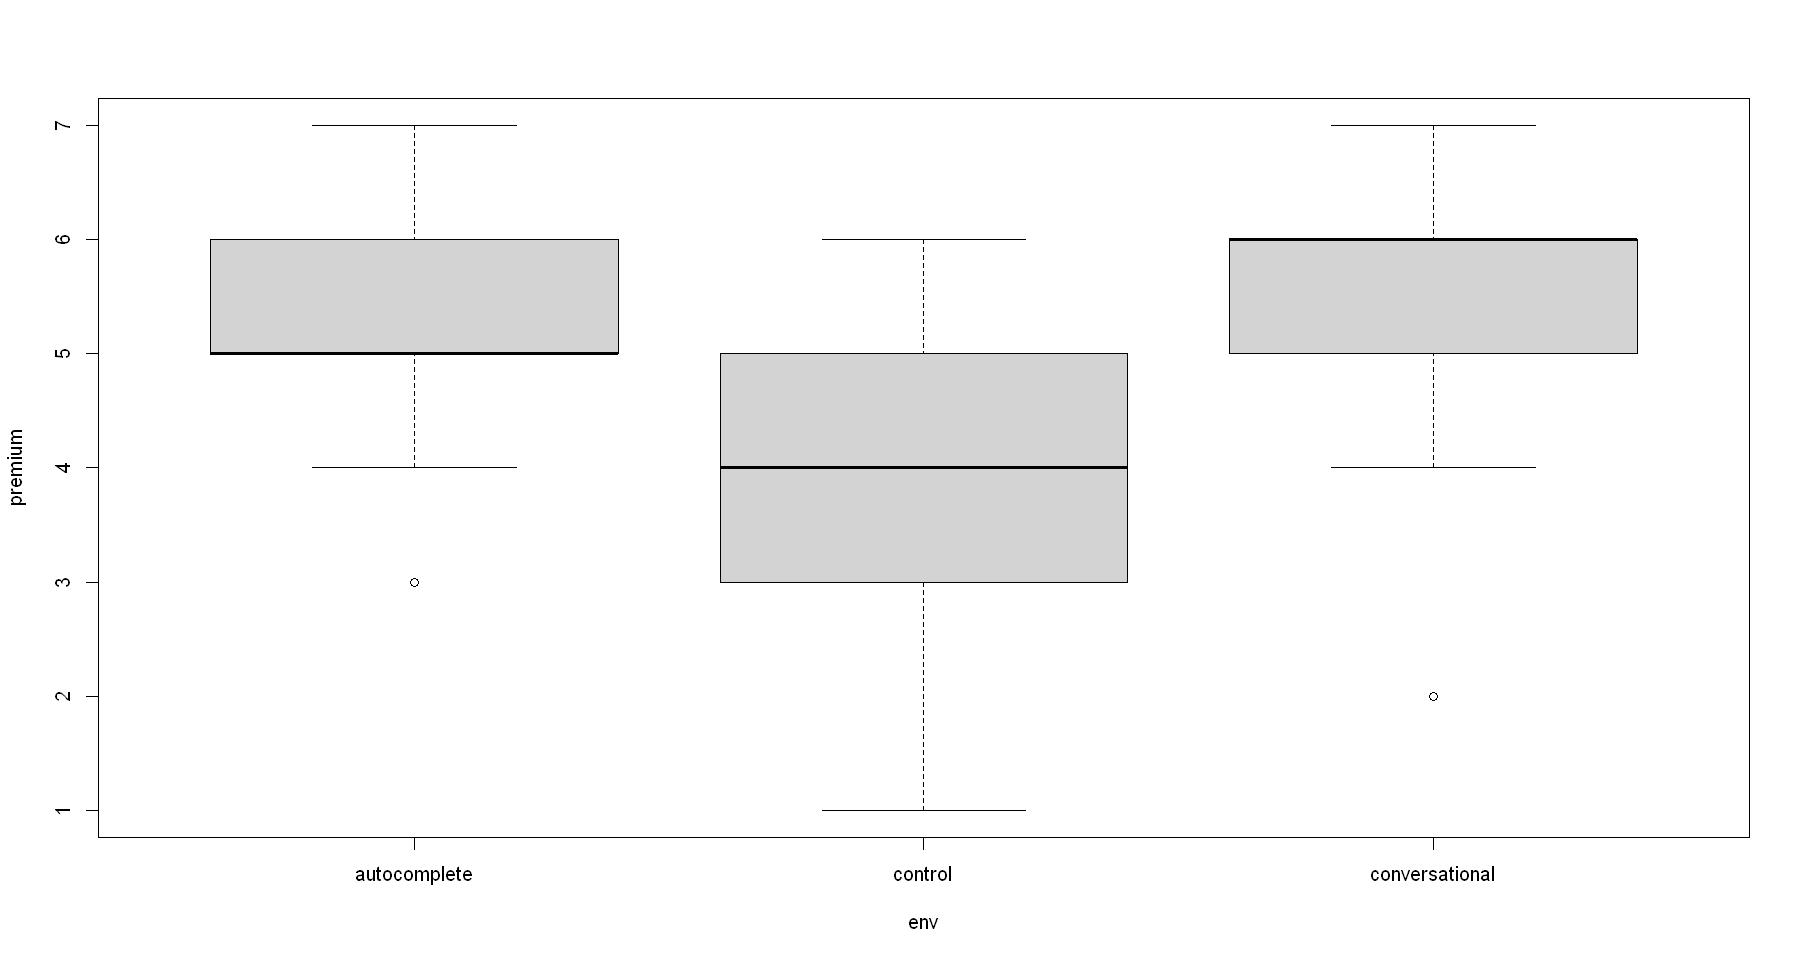


	Friedman rank sum test

data:  creative and env and pid
Friedman chi-squared = 16.651, df = 2, p-value = 0.0002423

# A tibble: 1 × 5
  .y.          n effsize method    magnitude
* <chr>    <int>   <dbl> <chr>     <ord>    
1 creative    24   0.347 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.0029       -      
conversational 0.7208       0.0013 

P value adjustment method: bonferroni 
[1] "good"


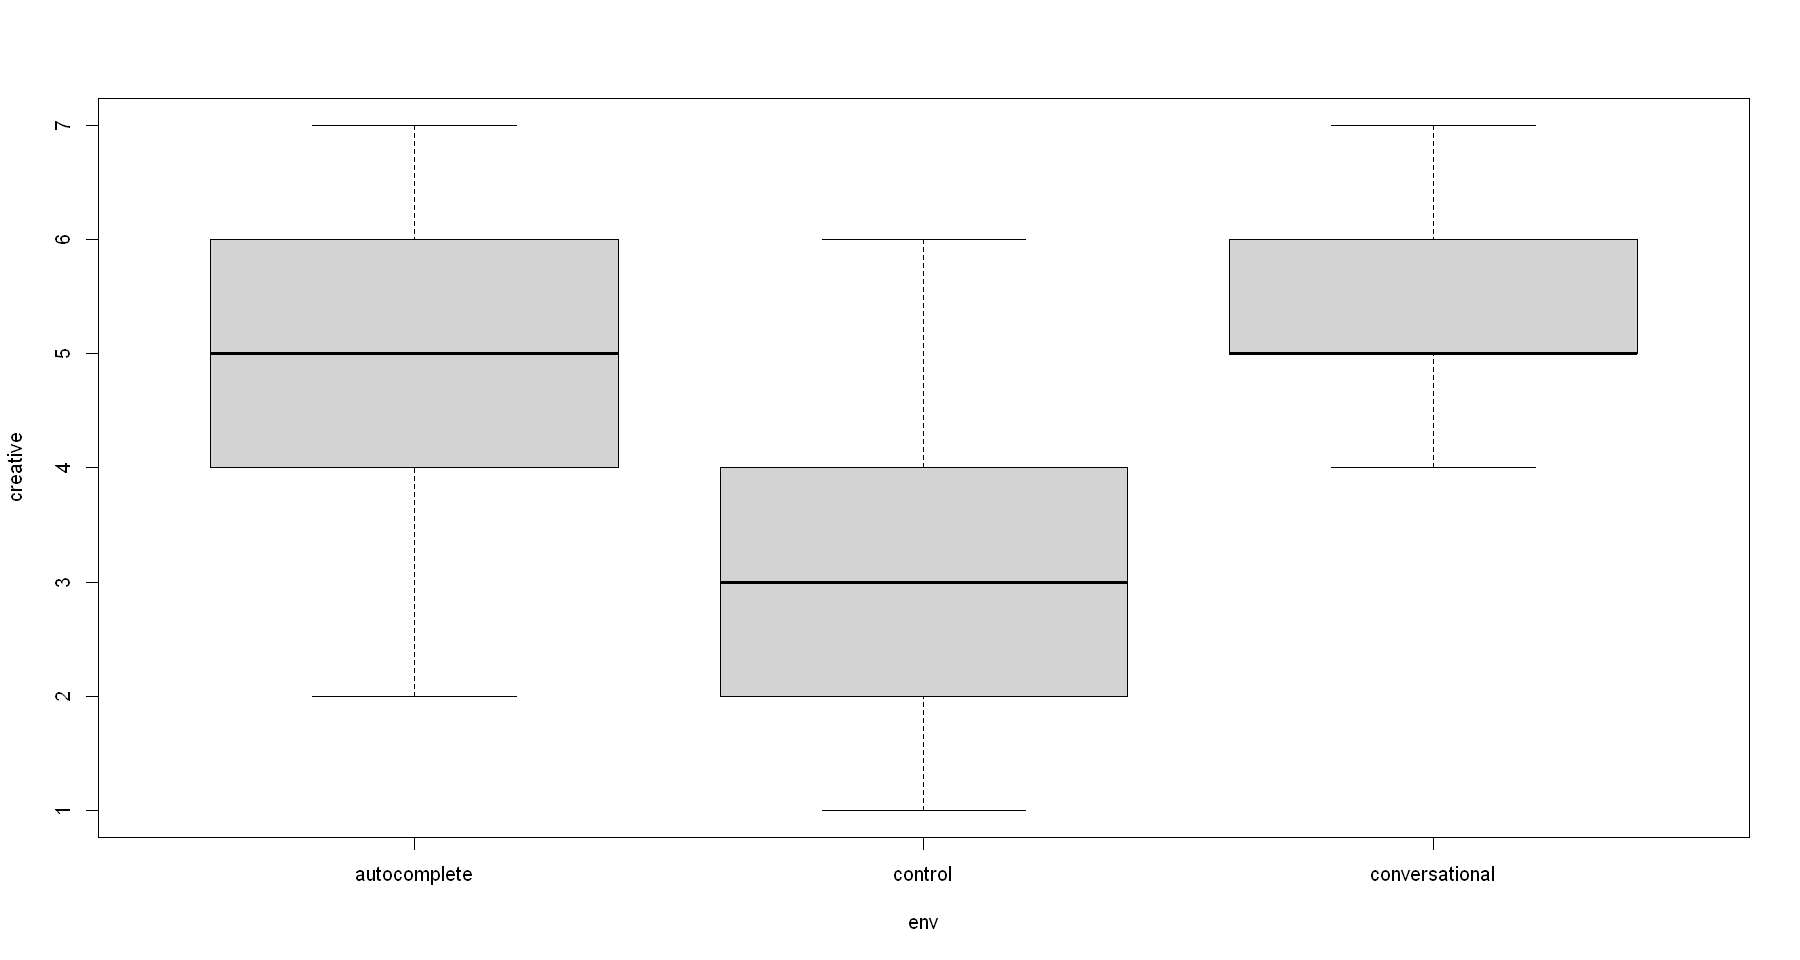


	Friedman rank sum test

data:  good and env and pid
Friedman chi-squared = 15.485, df = 2, p-value = 0.000434

# A tibble: 1 × 5
  .y.       n effsize method    magnitude
* <chr> <int>   <dbl> <chr>     <ord>    
1 good     24   0.323 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.0059       -      
conversational 1.0000       0.0061 

P value adjustment method: bonferroni 
[1] "structured"


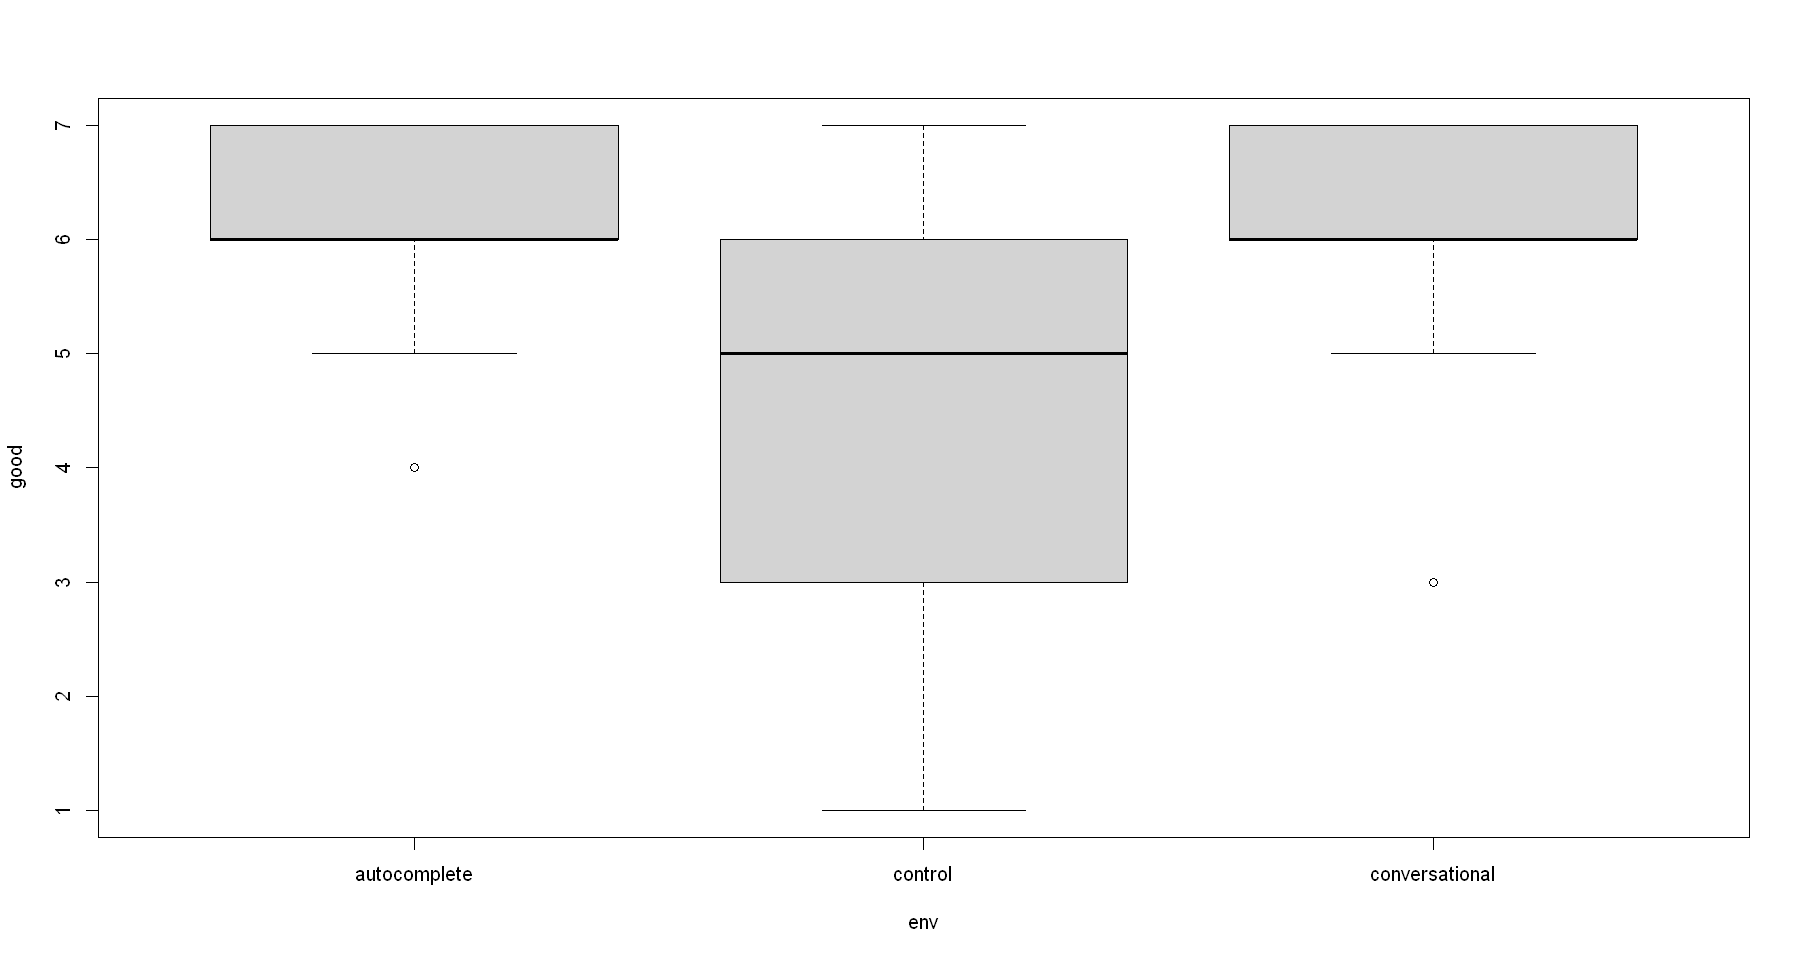


	Friedman rank sum test

data:  structured and env and pid
Friedman chi-squared = 5.403, df = 2, p-value = 0.06711

# A tibble: 1 × 5
  .y.            n effsize method    magnitude
* <chr>      <int>   <dbl> <chr>     <ord>    
1 structured    24   0.113 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.095        -      
conversational 1.000        0.286  

P value adjustment method: bonferroni 
[1] "captivating"


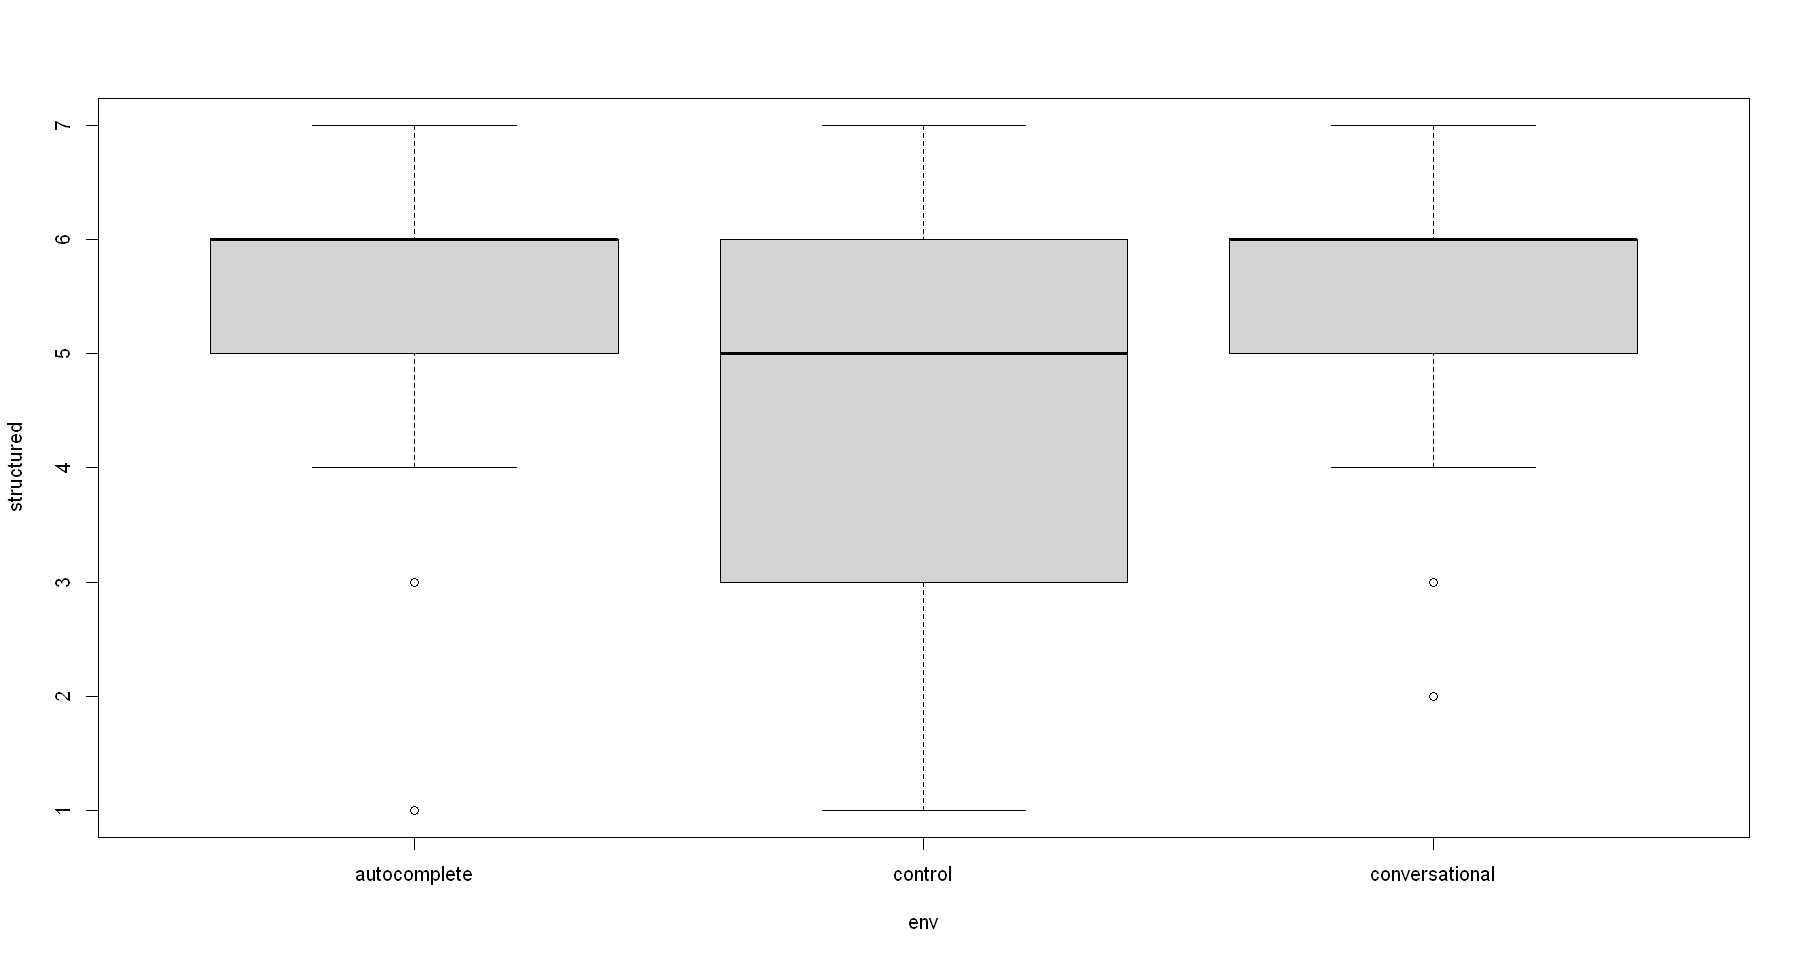


	Friedman rank sum test

data:  captivating and env and pid
Friedman chi-squared = 24.194, df = 2, p-value = 5.575e-06

# A tibble: 1 × 5
  .y.             n effsize method    magnitude
* <chr>       <int>   <dbl> <chr>     <ord>    
1 captivating    24   0.504 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.satisfaction[[category]] and cond.satisfaction$env 

               autocomplete control
control        0.00037      -      
conversational 1.00000      0.00305

P value adjustment method: bonferroni 


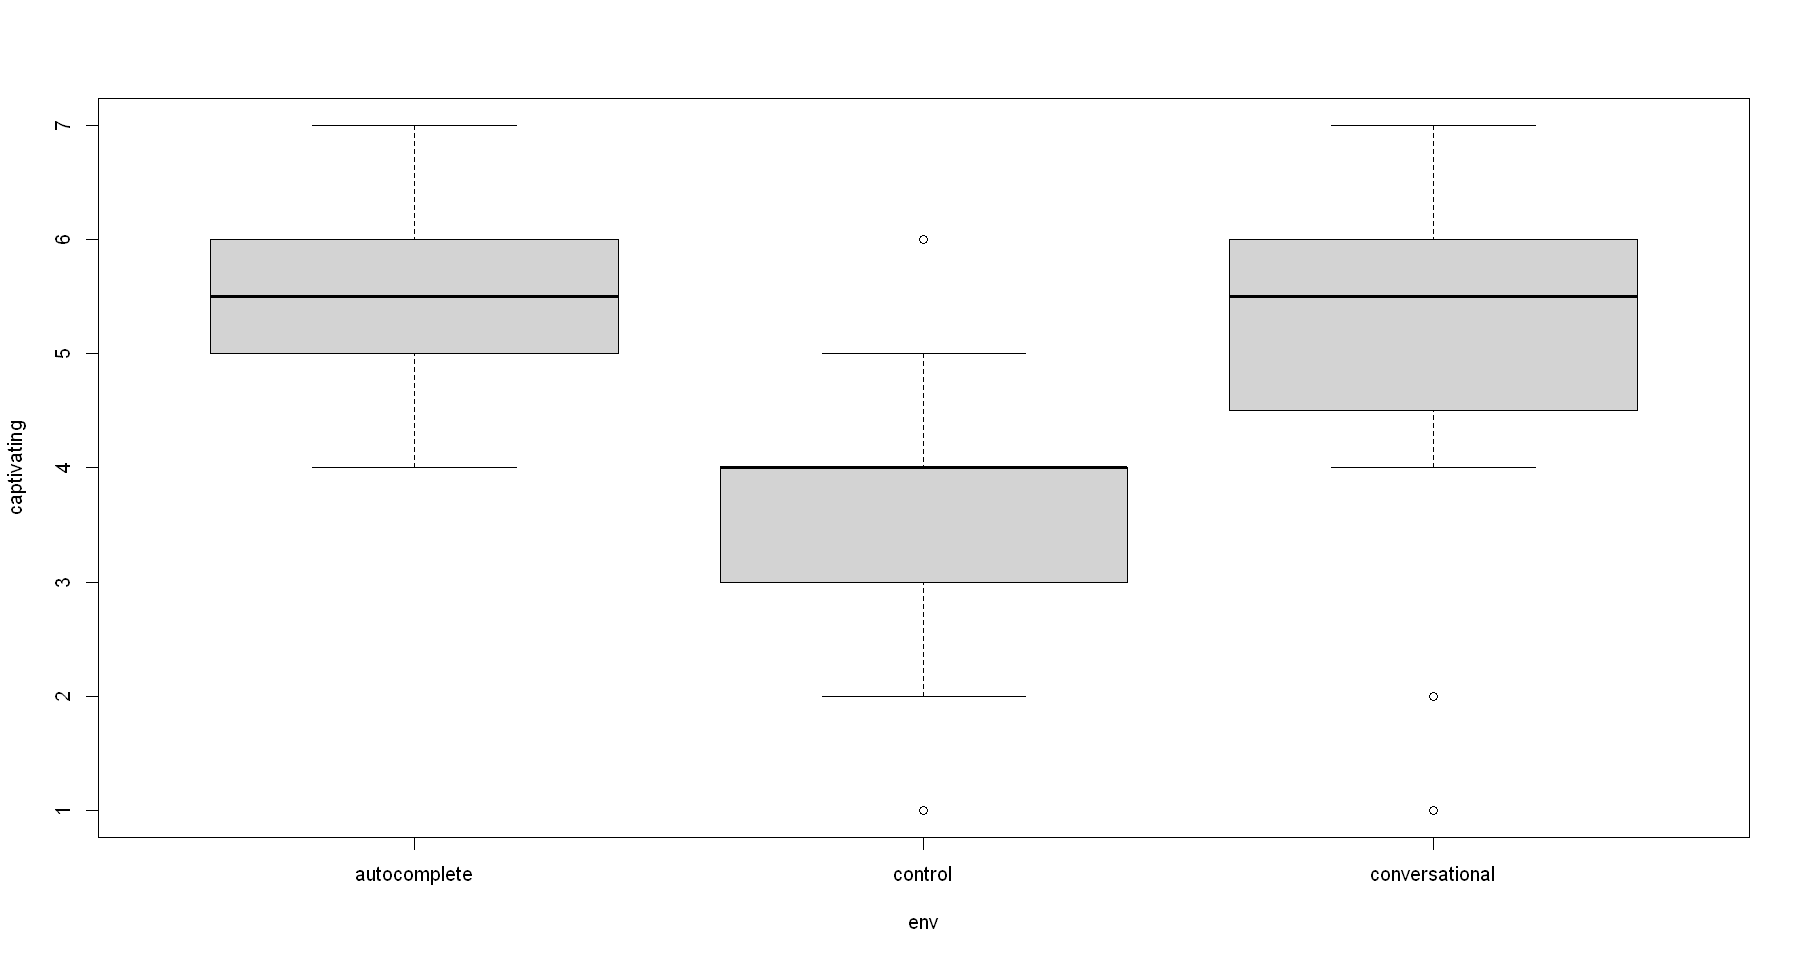

In [ ]:
# Analysis of each individual AttrakDiff question
for (category in attrakdiff.categories) {
  print(category)
  boxplot(formula(paste(category, ' ~ env')), data = cond.satisfaction, ylim=c(1, 7))

  shapiro.test(cond.satisfaction[[category]])
  f <- friedman.test(formula(paste(category, '~ env | pid')), data = cond.satisfaction)
  print(f)

  f.effect <- friedman_effsize(formula(paste(category, '~ env | pid')), data = cond.satisfaction)
  print(f.effect)

  wilcox <- pairwise.wilcox.test(cond.satisfaction[[category]], cond.satisfaction$env, p.adj = "bonf", paired=TRUE, exact=F)
  print(wilcox)
}


### Performance

In [ ]:
# Select subset of performance related data

cond.performance <- data.frame(
    mi = df.conditions$QualityMaintainabilityIndex, 
    implemented.quality = df.conditions$qualityCorrectlyImplementedRequirements, 
    percentage.quality = df.conditions$qualityCorrectlyImplementedRequirements / df.conditions$speedRequirementsImplemented, 
    env = df.conditions$environmentName, 
    task = df.conditions$taskName,
    pid = df.conditions$participantID
)



	Shapiro-Wilk normality test

data:  cond.performance$percentage.quality
W = 0.72365, p-value = 2.452e-10



	Friedman rank sum test

data:  percentage.quality and env and pid
Friedman chi-squared = 0.63636, df = 2, p-value = 0.7275


# A tibble: 1 × 5
  .y.                    n effsize method    magnitude
* <chr>              <int>   <dbl> <chr>     <ord>    
1 percentage.quality    24  0.0133 Kendall W small    



	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.performance$percentage.quality and cond.performance$env 

               autocomplete control
control        0.49         -      
conversational 0.67         1.00   

P value adjustment method: bonferroni 

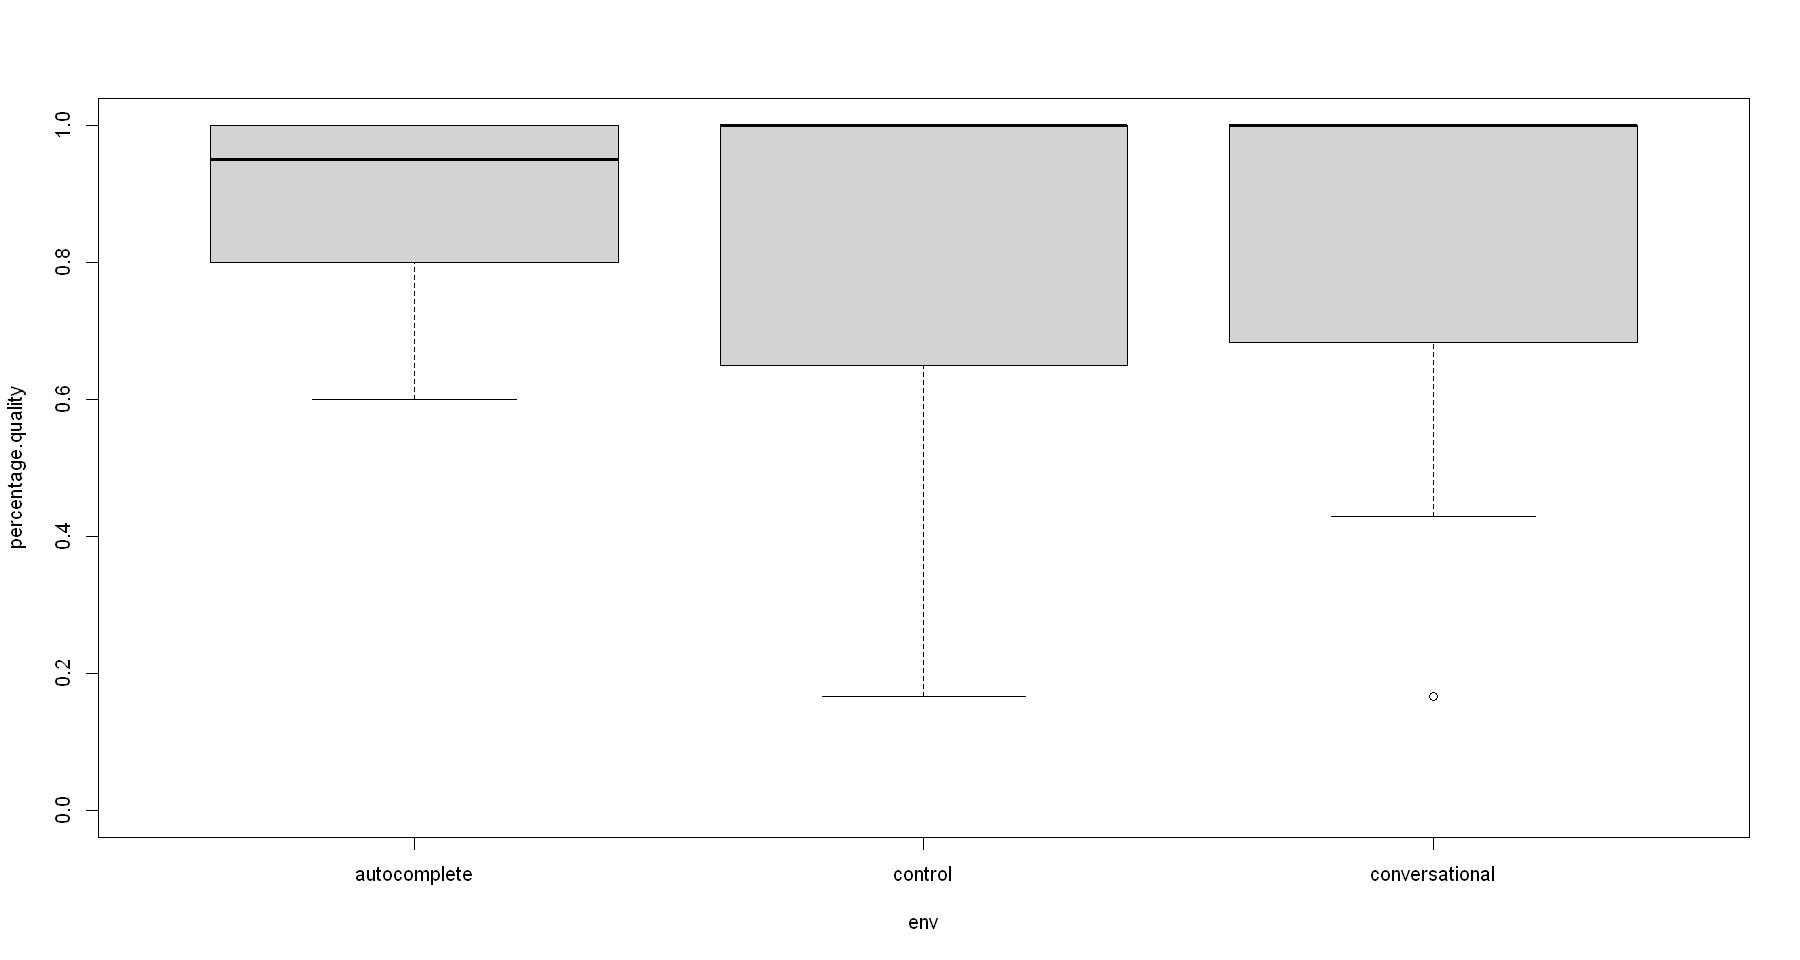

In [ ]:
# Percentage of correctly implemented requirements

boxplot(percentage.quality ~ env, data = cond.performance, ylim=c(0, 1))

shapiro.test(cond.performance$percentage.quality)

friedman.test(percentage.quality ~ env | pid, data = cond.performance)

f.effect <- friedman_effsize(percentage.quality ~ env | pid, data = cond.performance)
print(f.effect)

pairwise.wilcox.test(cond.performance$percentage.quality, cond.performance$env, p.adj = "bonf", paired=TRUE, exact=F)


	Shapiro-Wilk normality test

data:  cond.performance$mi
W = 0.94915, p-value = 0.005621



	Friedman rank sum test

data:  cond.performance$mi, cond.performance$env and cond.performance$pid
Friedman chi-squared = 0.27368, df = 2, p-value = 0.8721


# A tibble: 1 × 5
  .y.       n effsize method    magnitude
* <chr> <int>   <dbl> <chr>     <ord>    
1 mi       24 0.00570 Kendall W small    



	Exact two-sample Kolmogorov-Smirnov test

data:  cond.performance[cond.performance$env == "control", ]$mi and cond.performance[cond.performance$env == "autocomplete", ]$mi
D = 0.20833, p-value = 0.6794
alternative hypothesis: two-sided



	Exact two-sample Kolmogorov-Smirnov test

data:  cond.performance[cond.performance$env == "control", ]$mi and cond.performance[cond.performance$env == "conversational", ]$mi
D = 0.16667, p-value = 0.8982
alternative hypothesis: two-sided



	Exact two-sample Kolmogorov-Smirnov test

data:  cond.performance[cond.performance$env == "autocomplete", ]$mi and cond.performance[cond.performance$env == "conversational", ]$mi
D = 0.125, p-value = 0.9942
alternative hypothesis: two-sided



	Friedman rank sum test

data:  cond.performance$mi, cond.performance$task and cond.performance$pid
Friedman chi-squared = 30.084, df = 2, p-value = 2.933e-07



	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.performance$mi and cond.performance$task 

    CSV     PDF    
PDF 5.8e-05 -      
TXT 0.00013 1.00000

P value adjustment method: bonferroni 

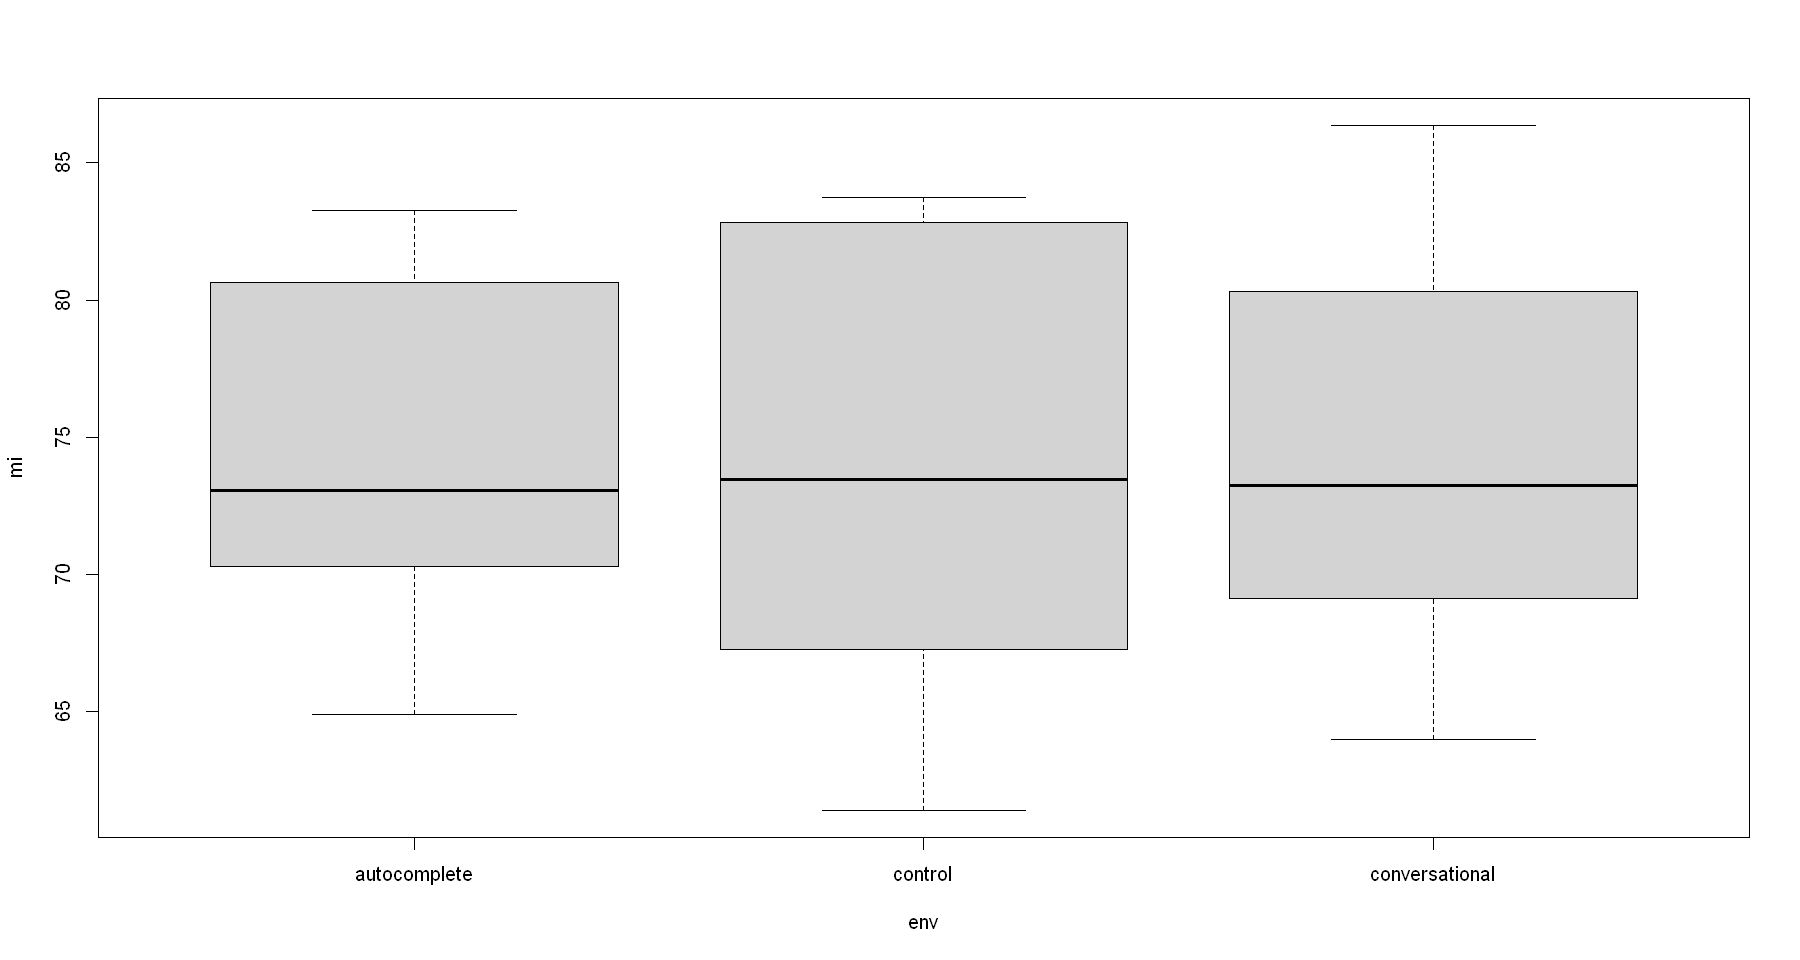

In [ ]:
# Maintainability index

boxplot(mi ~ env, data = cond.performance)

shapiro.test(cond.performance$mi)

friedman.test(cond.performance$mi, groups = cond.performance$env, blocks = cond.performance$pid)

f.effect <- friedman_effsize(mi ~ env | pid, data = cond.performance)
print(f.effect)

# Pairewise KS test to check whether they follow the samedistribution
ks.test(cond.performance[cond.performance$env == 'control',]$mi, cond.performance[cond.performance$env == 'autocomplete',]$mi)
ks.test(cond.performance[cond.performance$env == 'control',]$mi, cond.performance[cond.performance$env == 'conversational',]$mi)
ks.test(cond.performance[cond.performance$env == 'autocomplete',]$mi, cond.performance[cond.performance$env == 'conversational',]$mi)

friedman.test(cond.performance$mi, groups = cond.performance$task, blocks = cond.performance$pid)
pairwise.wilcox.test(cond.performance$mi, cond.performance$task, p.adj = "bonf", paired=TRUE, exact=F)


	Shapiro-Wilk normality test

data:  cond.performance$implemented.quality
W = 0.87614, p-value = 3.835e-06



	Friedman rank sum test

data:  implemented.quality and env and pid
Friedman chi-squared = 17.659, df = 2, p-value = 0.0001464

# A tibble: 1 × 5
  .y.                     n effsize method    magnitude
* <chr>               <int>   <dbl> <chr>     <ord>    
1 implemented.quality    24   0.368 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  cond.performance$implemented.quality and cond.performance$env 

               autocomplete control
control        0.00039      -      
conversational 0.34396      0.03072

P value adjustment method: bonferroni 


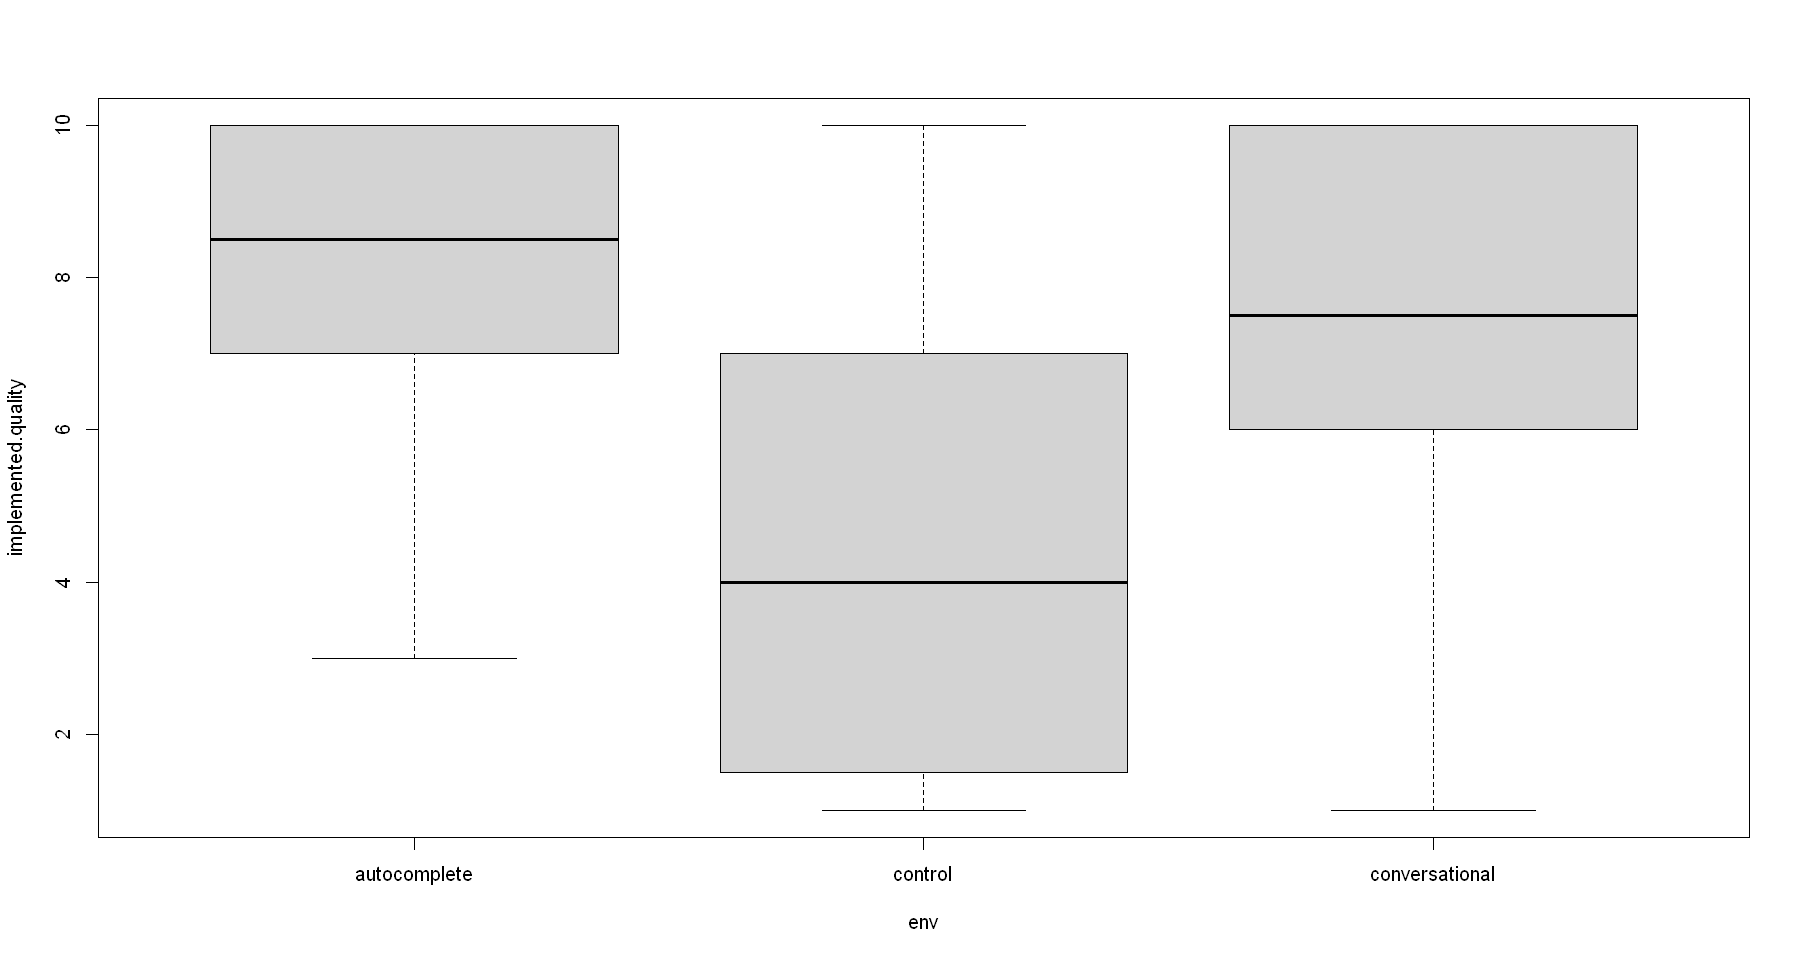

In [ ]:
# Number of correctly implemented requirements

boxplot(implemented.quality ~ env, data = cond.performance)
shapiro.test(cond.performance$implemented.quality)
f <- friedman.test(implemented.quality ~ env | pid, data = cond.performance)
print(f)

f.effect <- friedman_effsize(implemented.quality ~ env | pid, data = cond.performance)
print(f.effect)

wilcox <- pairwise.wilcox.test(cond.performance$implemented.quality, cond.performance$env, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)

### Communication

[1] "communicationBrowserNewSnippets"

	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.69022, p-value = 4.872e-11


	Friedman rank sum test

data:  communicationBrowserNewSnippets and environmentName and participantID
Friedman chi-squared = 41.325, df = 2, p-value = 1.063e-09


	Friedman rank sum test

data:  communicationBrowserNewSnippets and taskName and participantID
Friedman chi-squared = 0.18182, df = 2, p-value = 0.9131

# A tibble: 1 × 5
  .y.                                 n effsize method    magnitude
* <chr>                           <int>   <dbl> <chr>     <ord>    
1 communicationBrowserNewSnippets    24   0.861 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        8.6e-05      -      
conversational 1            5.5e-05

P value adjustment method: bonferroni 
[1] "communicationBrowserCharacter

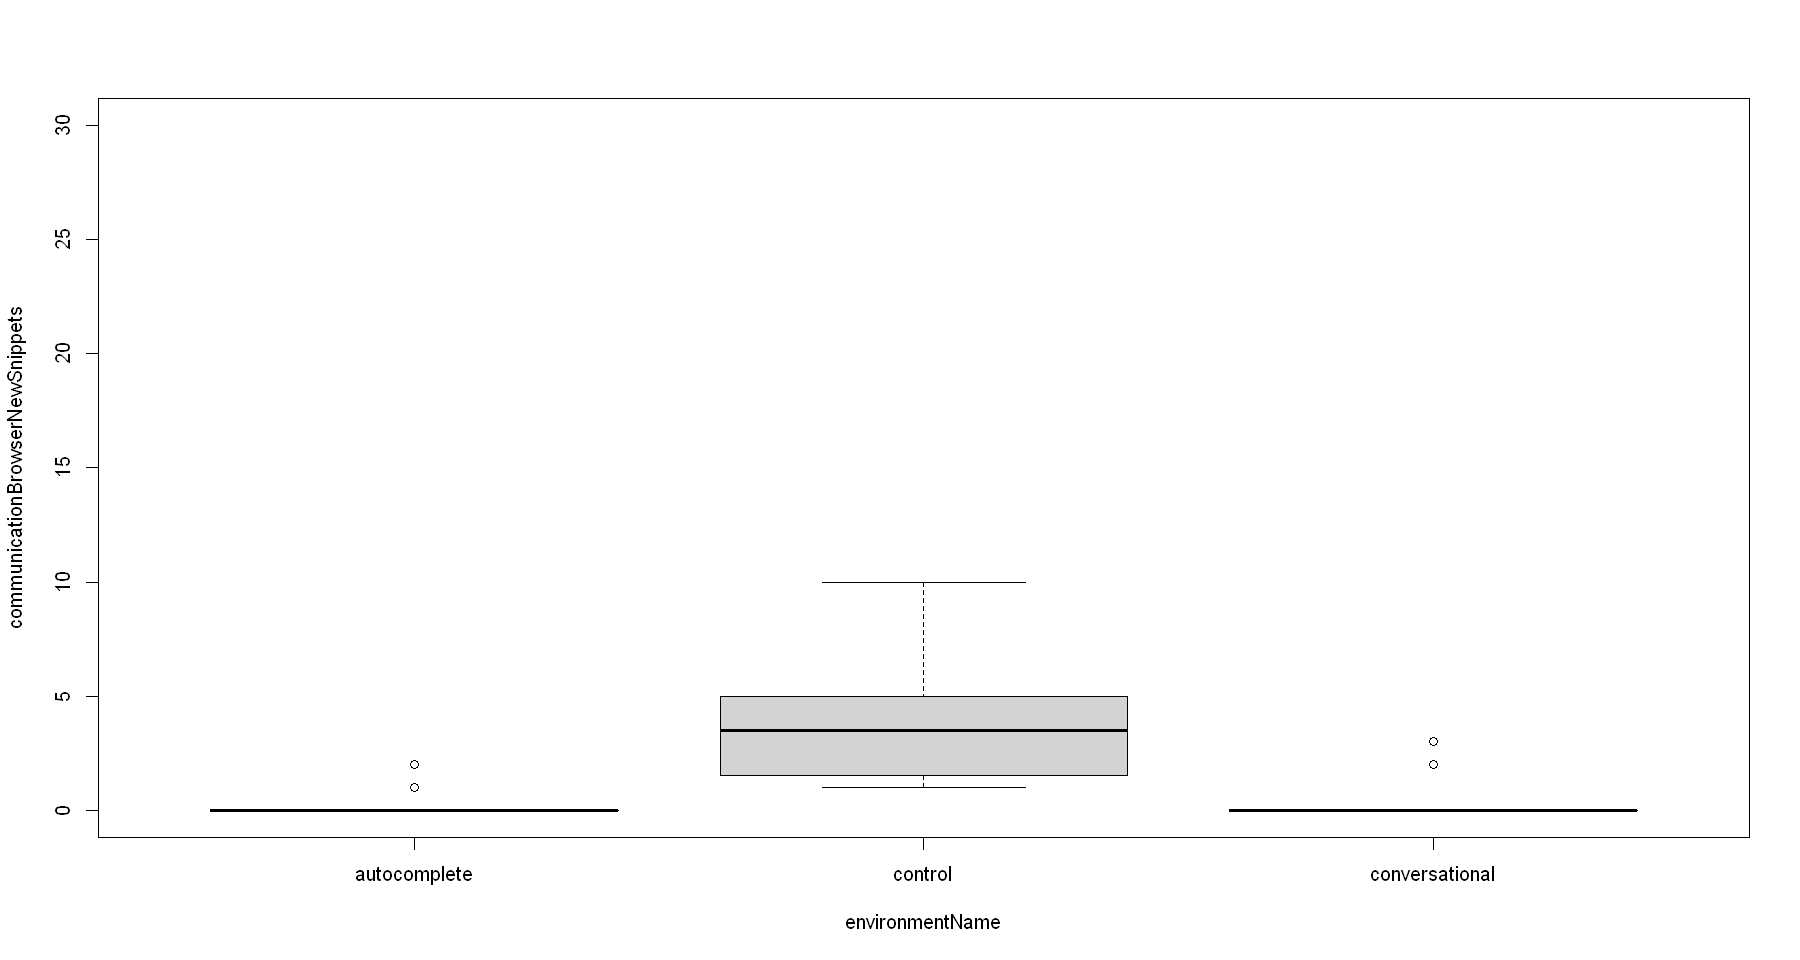


	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.47002, p-value = 1.082e-14


	Friedman rank sum test

data:  communicationBrowserCharacters and environmentName and participantID
Friedman chi-squared = 41.325, df = 2, p-value = 1.063e-09


	Friedman rank sum test

data:  communicationBrowserCharacters and taskName and participantID
Friedman chi-squared = 0.18182, df = 2, p-value = 0.9131

# A tibble: 1 × 5
  .y.                                n effsize method    magnitude
* <chr>                          <int>   <dbl> <chr>     <ord>    
1 communicationBrowserCharacters    24   0.861 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        0.00012      -      
conversational 1.00000      5.8e-05

P value adjustment method: bonferroni 
[1] "communicationBrowserSnippetSize"


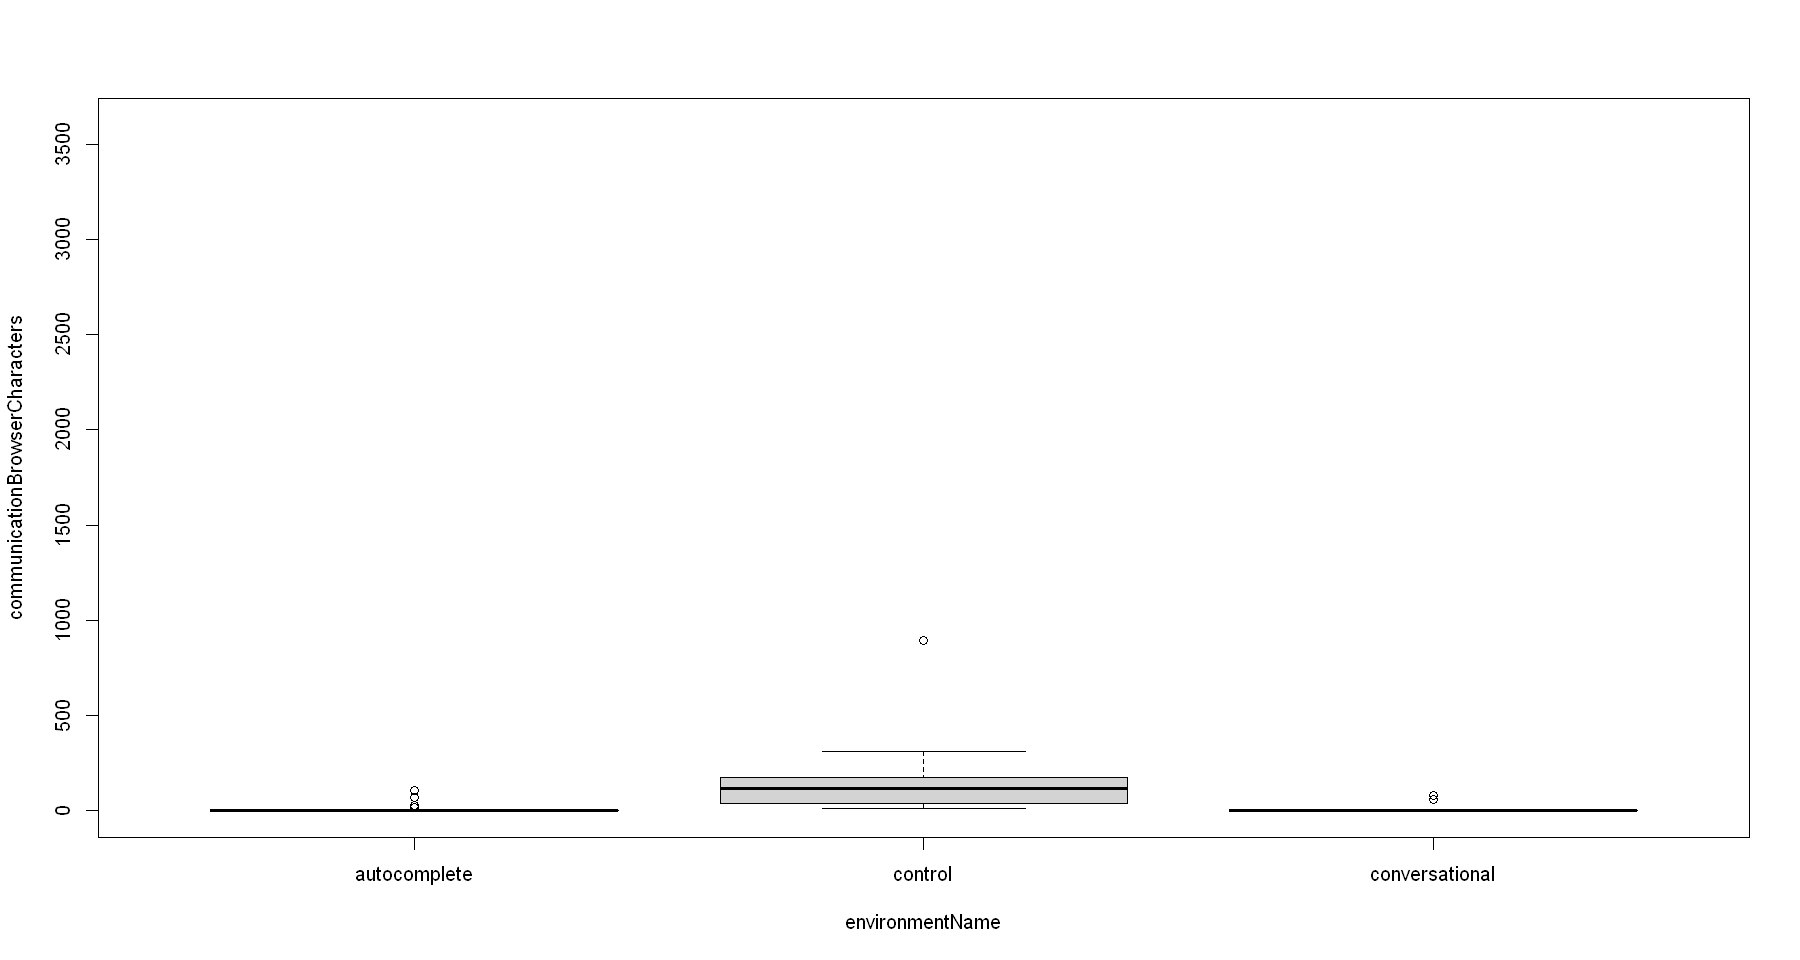


	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.57555, p-value = 4.127e-13


	Friedman rank sum test

data:  communicationBrowserSnippetSize and environmentName and participantID
Friedman chi-squared = 41.325, df = 2, p-value = 1.063e-09


	Friedman rank sum test

data:  communicationBrowserSnippetSize and taskName and participantID
Friedman chi-squared = 0.18182, df = 2, p-value = 0.9131

# A tibble: 1 × 5
  .y.                                 n effsize method    magnitude
* <chr>                           <int>   <dbl> <chr>     <ord>    
1 communicationBrowserSnippetSize    24   0.861 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        0.00023      -      
conversational 1.00000      5.8e-05

P value adjustment method: bonferroni 
[1] "communicationAINewSnippets"


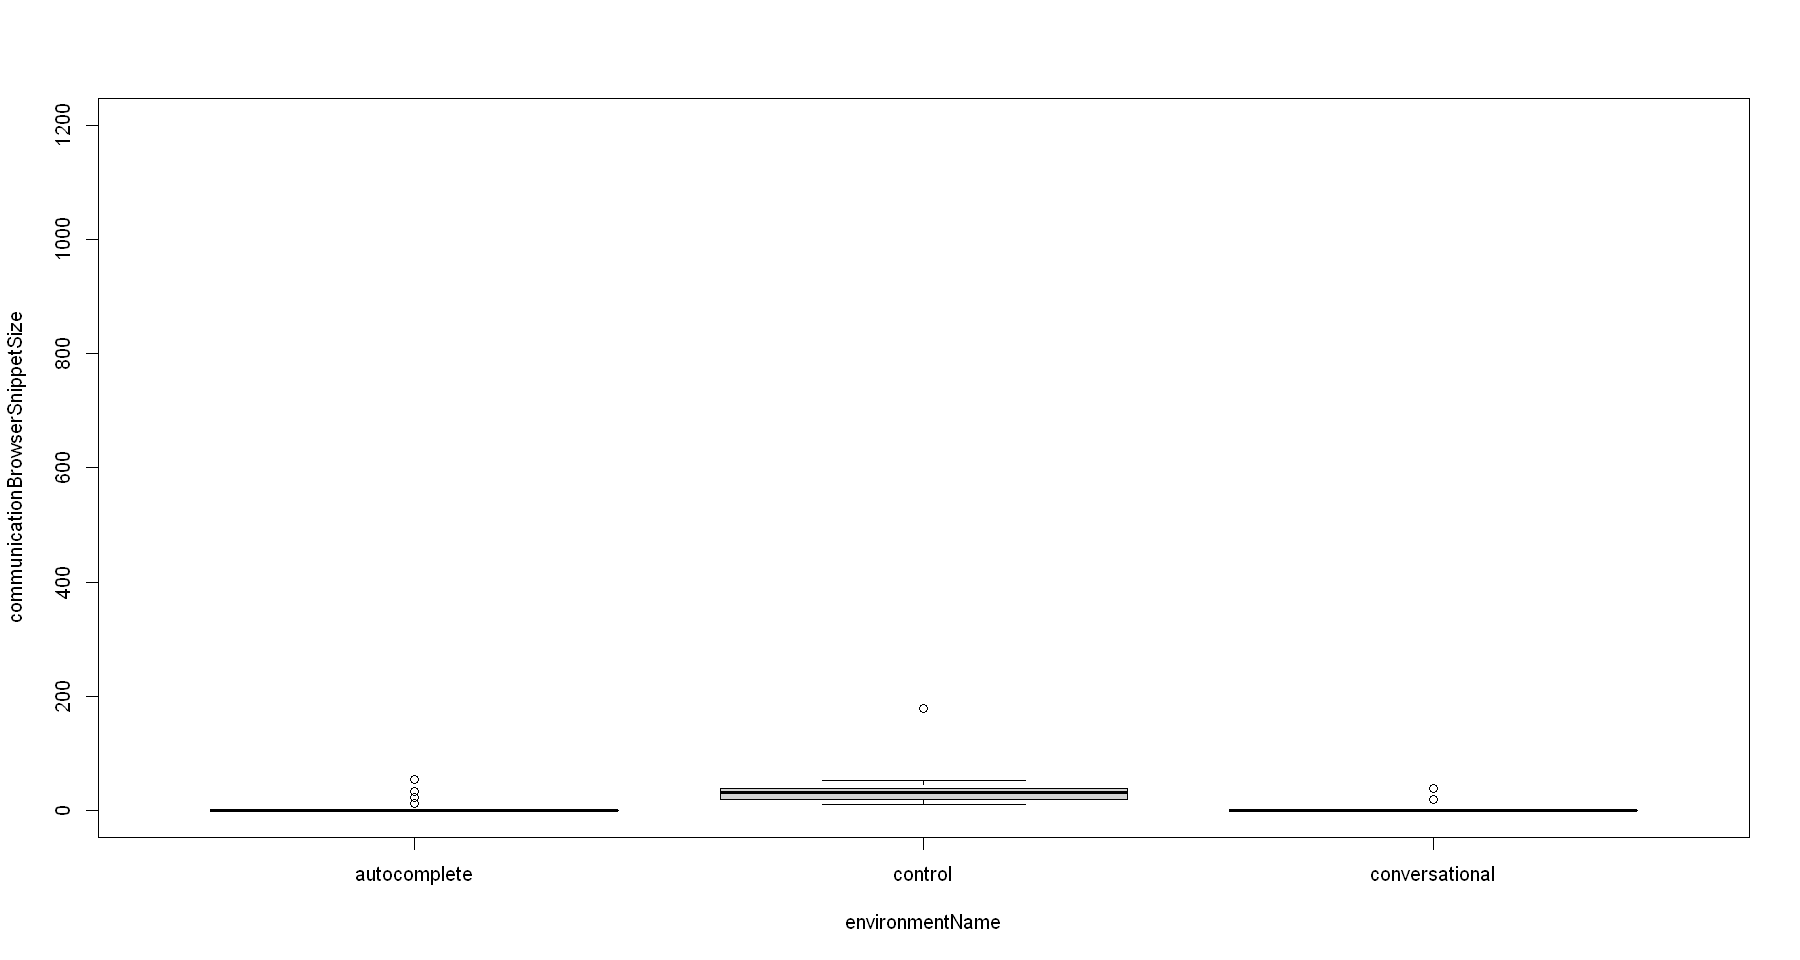


	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.85402, p-value = 6.754e-07


	Friedman rank sum test

data:  communicationAINewSnippets and environmentName and participantID
Friedman chi-squared = 42.75, df = 2, p-value = 5.211e-10


	Friedman rank sum test

data:  communicationAINewSnippets and taskName and participantID
Friedman chi-squared = 0.25, df = 2, p-value = 0.8825

# A tibble: 1 × 5
  .y.                            n effsize method    magnitude
* <chr>                      <int>   <dbl> <chr>     <ord>    
1 communicationAINewSnippets    24   0.891 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        5.8e-05      -      
conversational 0.00025      5.6e-05

P value adjustment method: bonferroni 
[1] "communicationAICharacters"


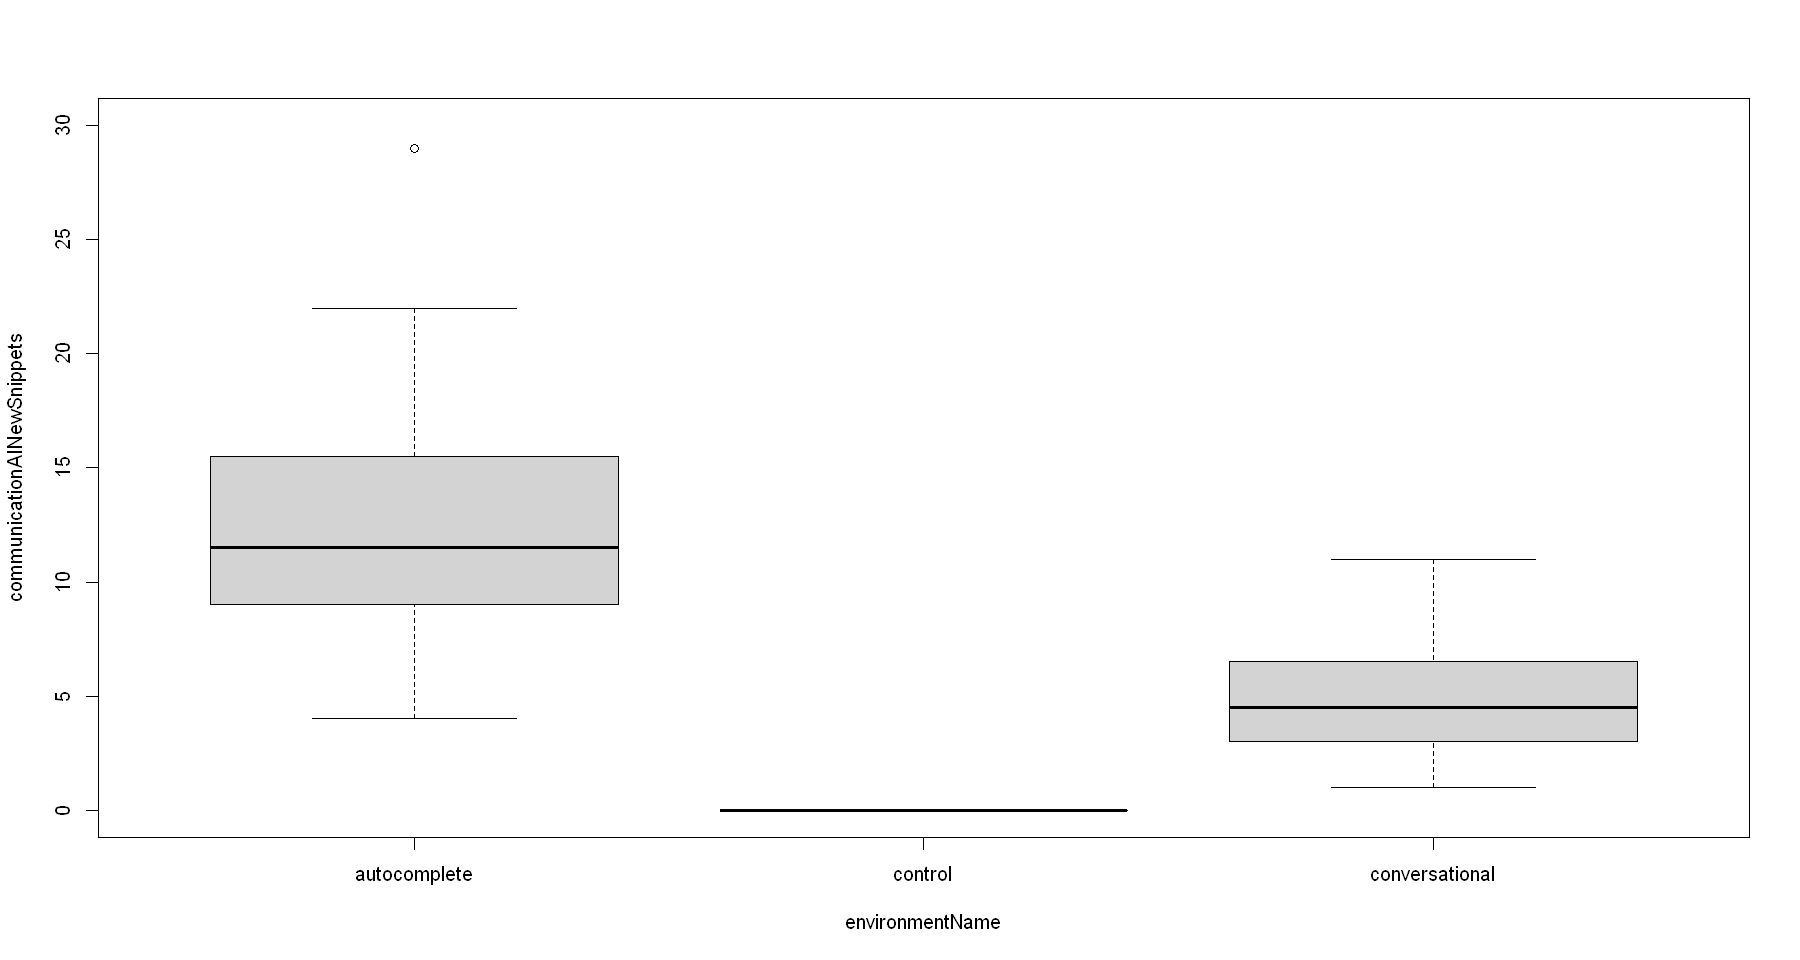


	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.70042, p-value = 7.871e-11


	Friedman rank sum test

data:  communicationAICharacters and environmentName and participantID
Friedman chi-squared = 36.333, df = 2, p-value = 1.289e-08


	Friedman rank sum test

data:  communicationAICharacters and taskName and participantID
Friedman chi-squared = 1.75, df = 2, p-value = 0.4169

# A tibble: 1 × 5
  .y.                           n effsize method    magnitude
* <chr>                     <int>   <dbl> <chr>     <ord>    
1 communicationAICharacters    24   0.757 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        5.8e-05      -      
conversational 0.93         5.8e-05

P value adjustment method: bonferroni 
[1] "communicationAISnippetSize"


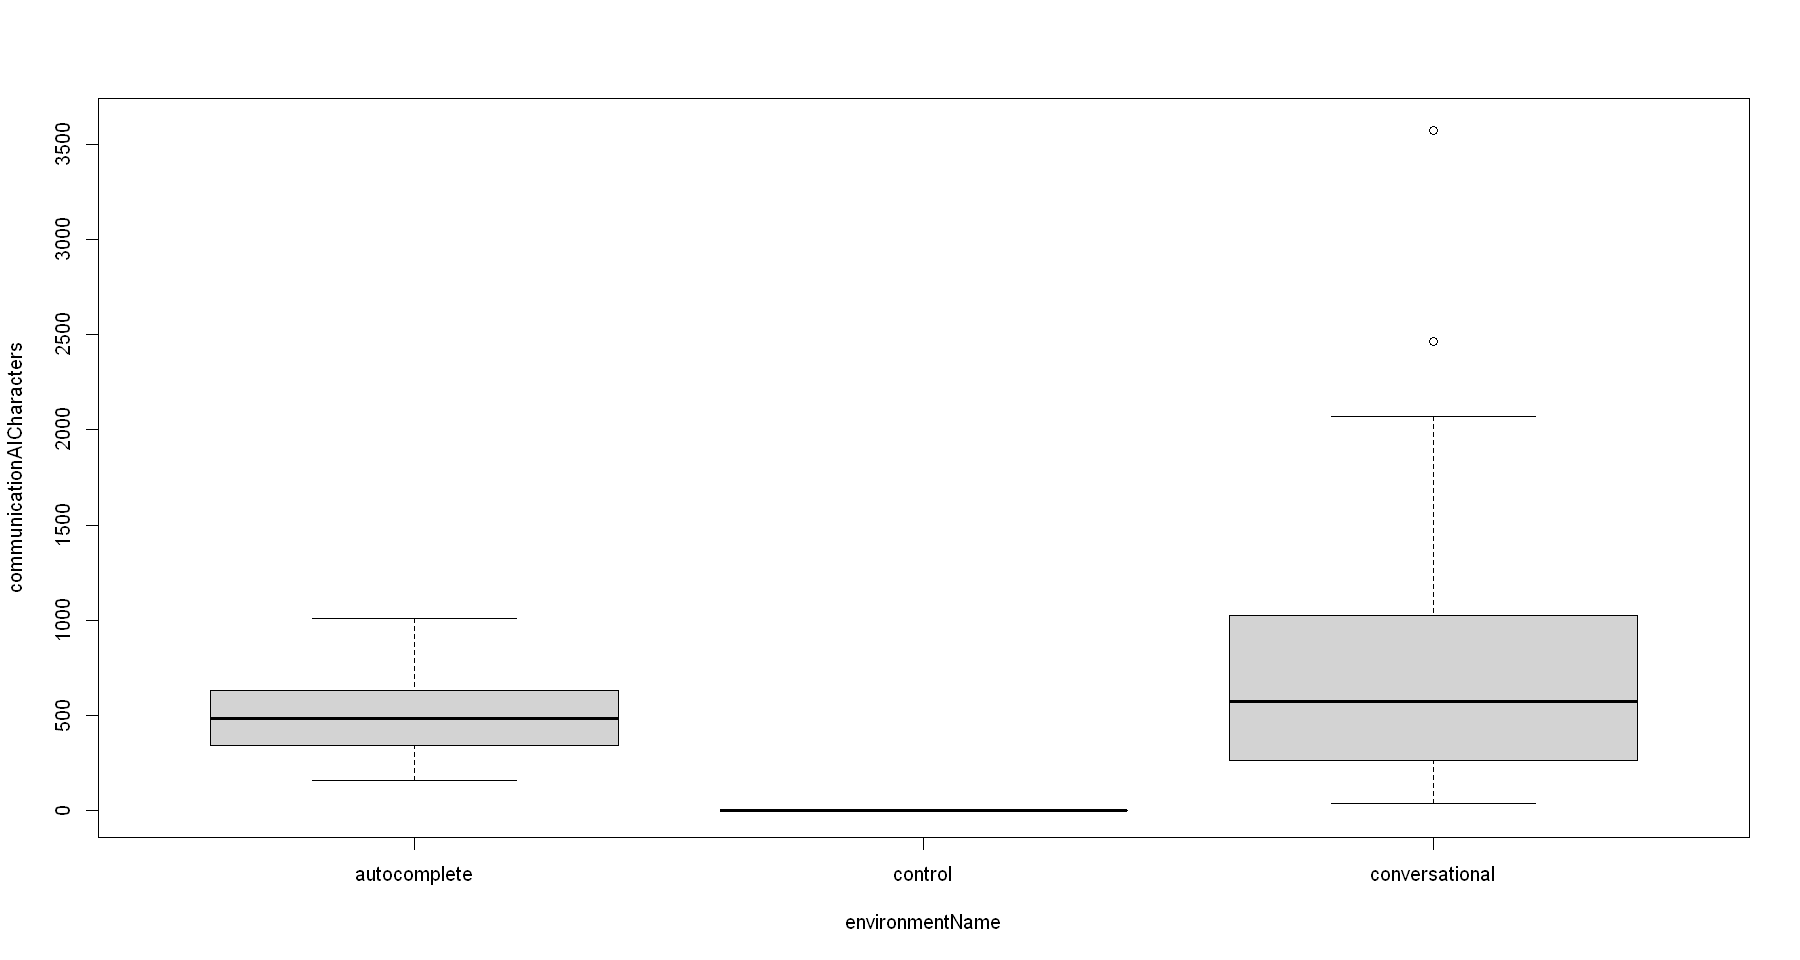


	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.45036, p-value = 5.825e-15


	Friedman rank sum test

data:  communicationAISnippetSize and environmentName and participantID
Friedman chi-squared = 42.75, df = 2, p-value = 5.211e-10


	Friedman rank sum test

data:  communicationAISnippetSize and taskName and participantID
Friedman chi-squared = 0.25, df = 2, p-value = 0.8825

# A tibble: 1 × 5
  .y.                            n effsize method    magnitude
* <chr>                      <int>   <dbl> <chr>     <ord>    
1 communicationAISnippetSize    24   0.891 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        5.8e-05      -      
conversational 0.00018      5.8e-05

P value adjustment method: bonferroni 
[1] "communication.overall.new.snippets"


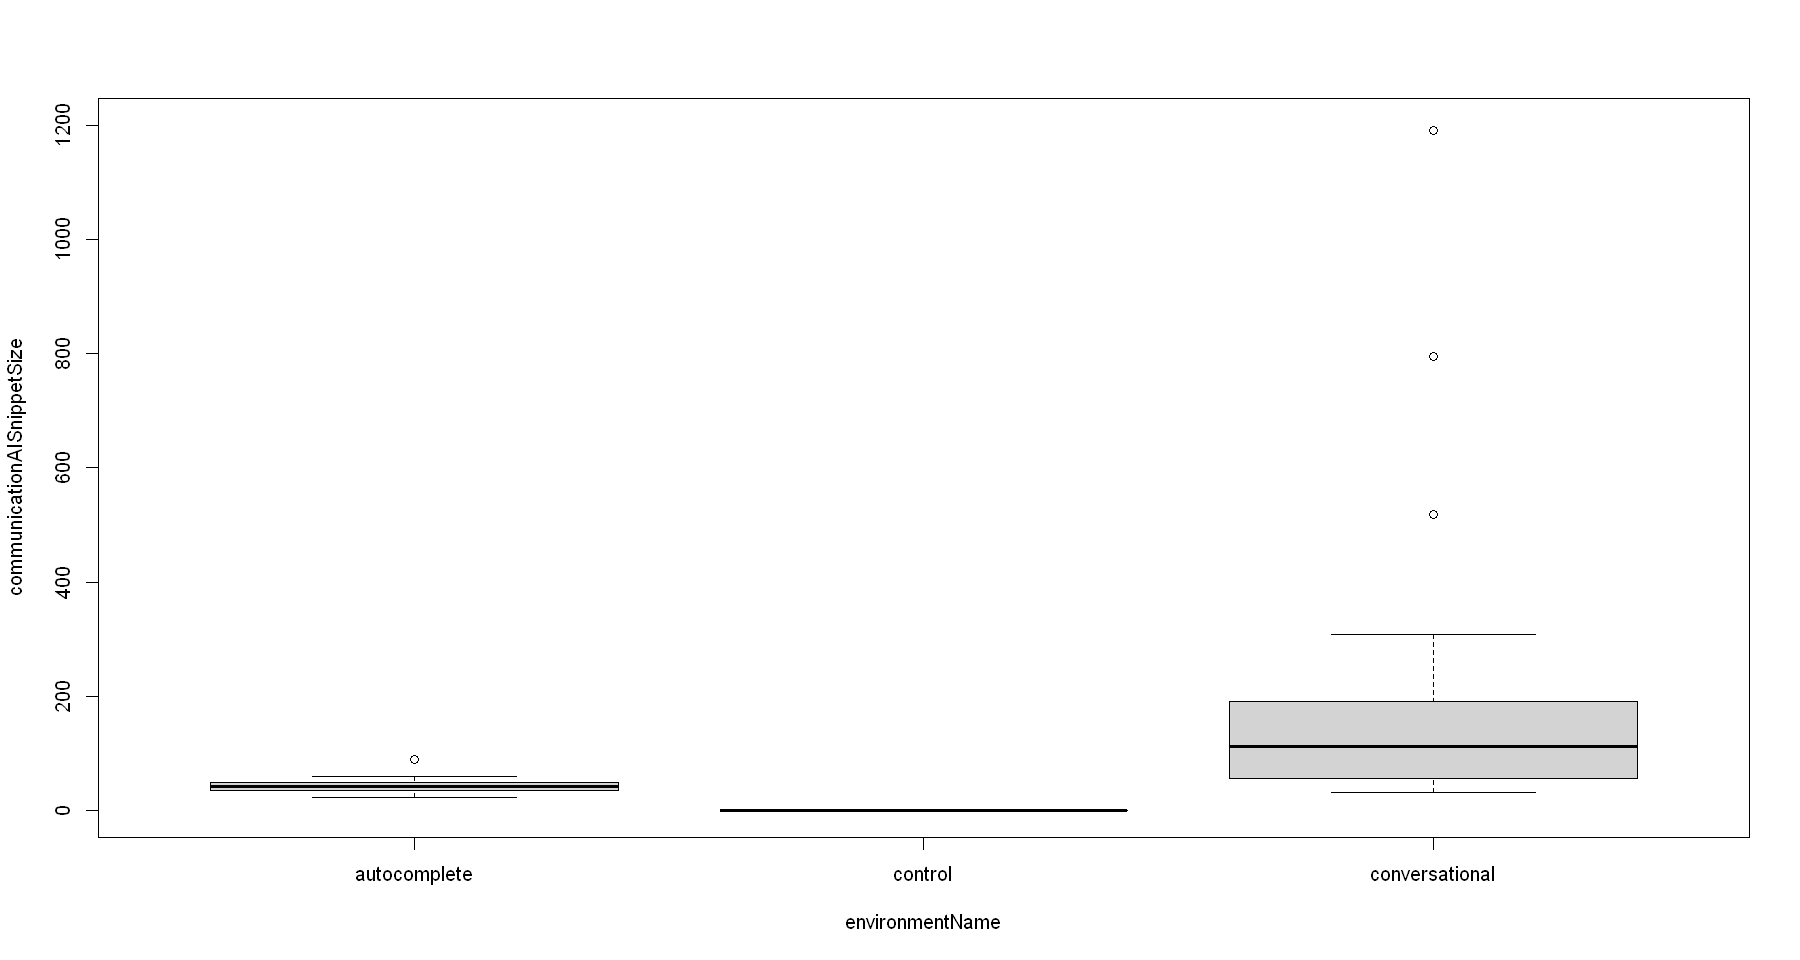


	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.87446, p-value = 3.343e-06


	Friedman rank sum test

data:  communication.overall.new.snippets and environmentName and participantID
Friedman chi-squared = 31.043, df = 2, p-value = 1.816e-07


	Friedman rank sum test

data:  communication.overall.new.snippets and taskName and participantID
Friedman chi-squared = 4.617, df = 2, p-value = 0.09941

# A tibble: 1 × 5
  .y.                                    n effsize method    magnitude
* <chr>                              <int>   <dbl> <chr>     <ord>    
1 communication.overall.new.snippets    24   0.647 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        8.5e-05      -      
conversational 0.00016      0.08343

P value adjustment method: bonferroni 
[1] "communication.overall.characters"


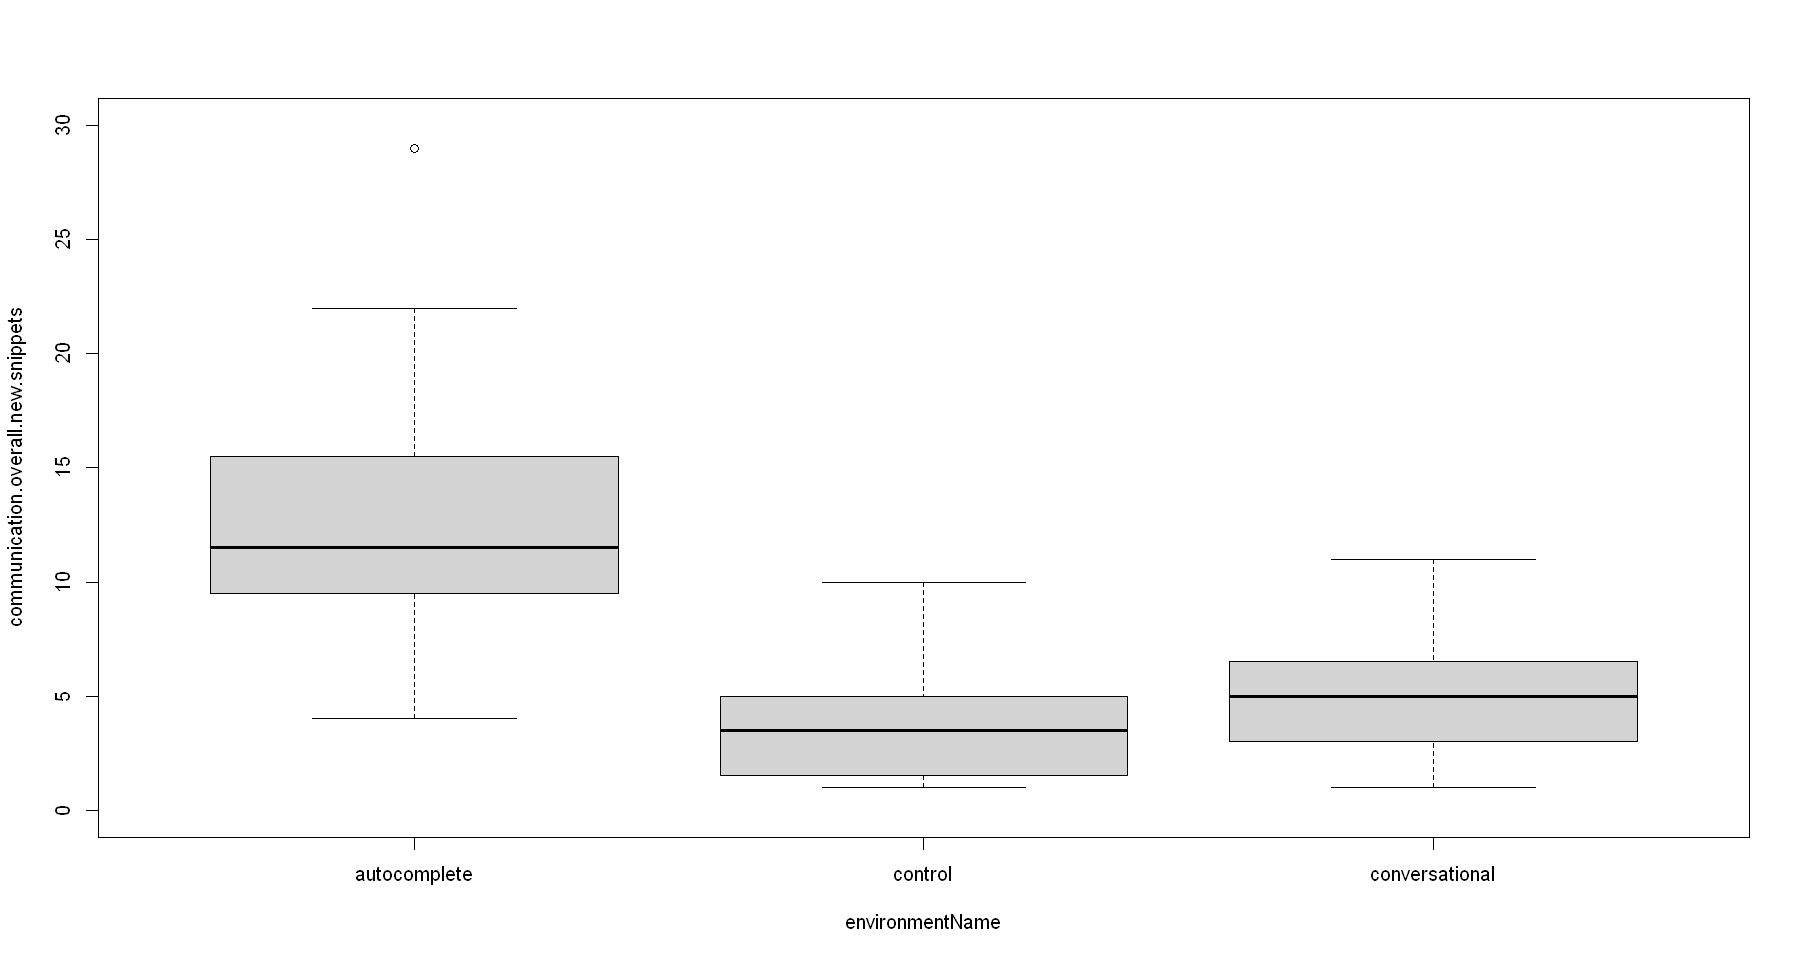


	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.69454, p-value = 5.963e-11


	Friedman rank sum test

data:  communication.overall.characters and environmentName and participantID
Friedman chi-squared = 27.583, df = 2, p-value = 1.024e-06


	Friedman rank sum test

data:  communication.overall.characters and taskName and participantID
Friedman chi-squared = 4, df = 2, p-value = 0.1353

# A tibble: 1 × 5
  .y.                                  n effsize method    magnitude
* <chr>                            <int>   <dbl> <chr>     <ord>    
1 communication.overall.characters    24   0.575 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        0.00058      -      
conversational 0.97282      0.00023

P value adjustment method: bonferroni 
[1] "communication.overall.avg.size"


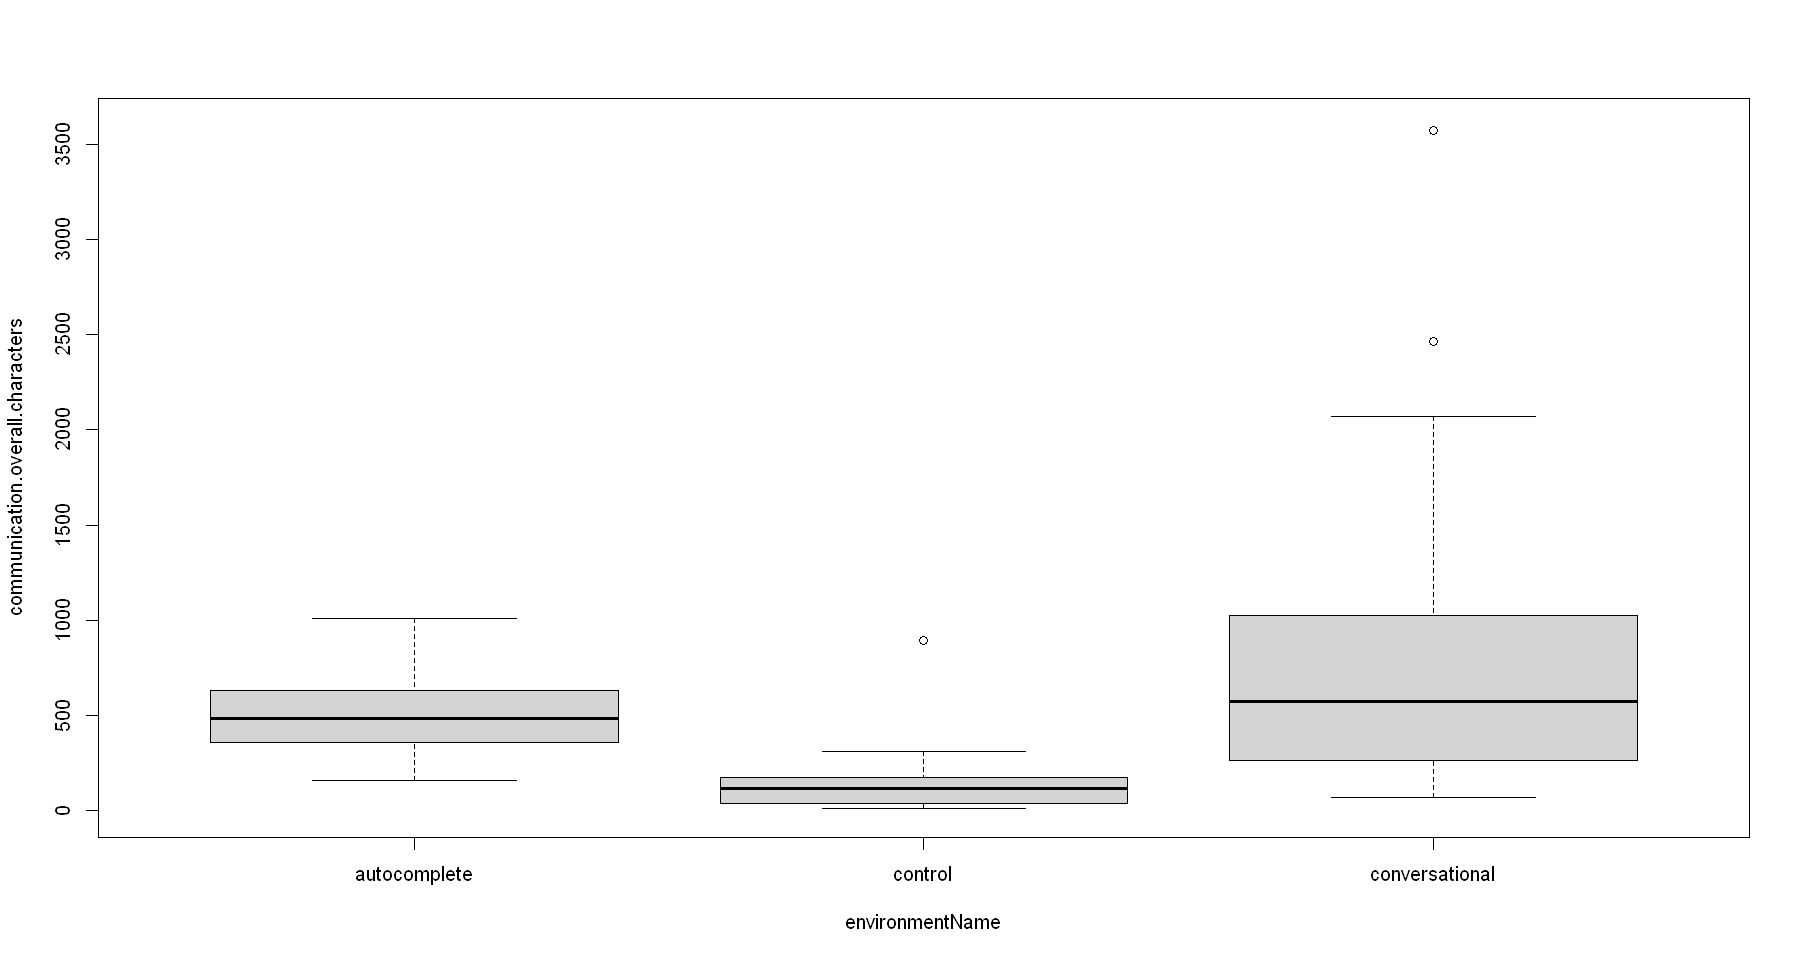


	Shapiro-Wilk normality test

data:  df.conditions[[col]]
W = 0.41828, p-value = 2.193e-15


	Friedman rank sum test

data:  communication.overall.avg.size and environmentName and participantID
Friedman chi-squared = 25.083, df = 2, p-value = 3.575e-06


	Friedman rank sum test

data:  communication.overall.avg.size and taskName and participantID
Friedman chi-squared = 1.75, df = 2, p-value = 0.4169

# A tibble: 1 × 5
  .y.                                n effsize method    magnitude
* <chr>                          <int>   <dbl> <chr>     <ord>    
1 communication.overall.avg.size    24   0.523 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions[[col]] and df.conditions$environmentName 

               autocomplete control
control        0.03726      -      
conversational 0.00020      0.00036

P value adjustment method: bonferroni 


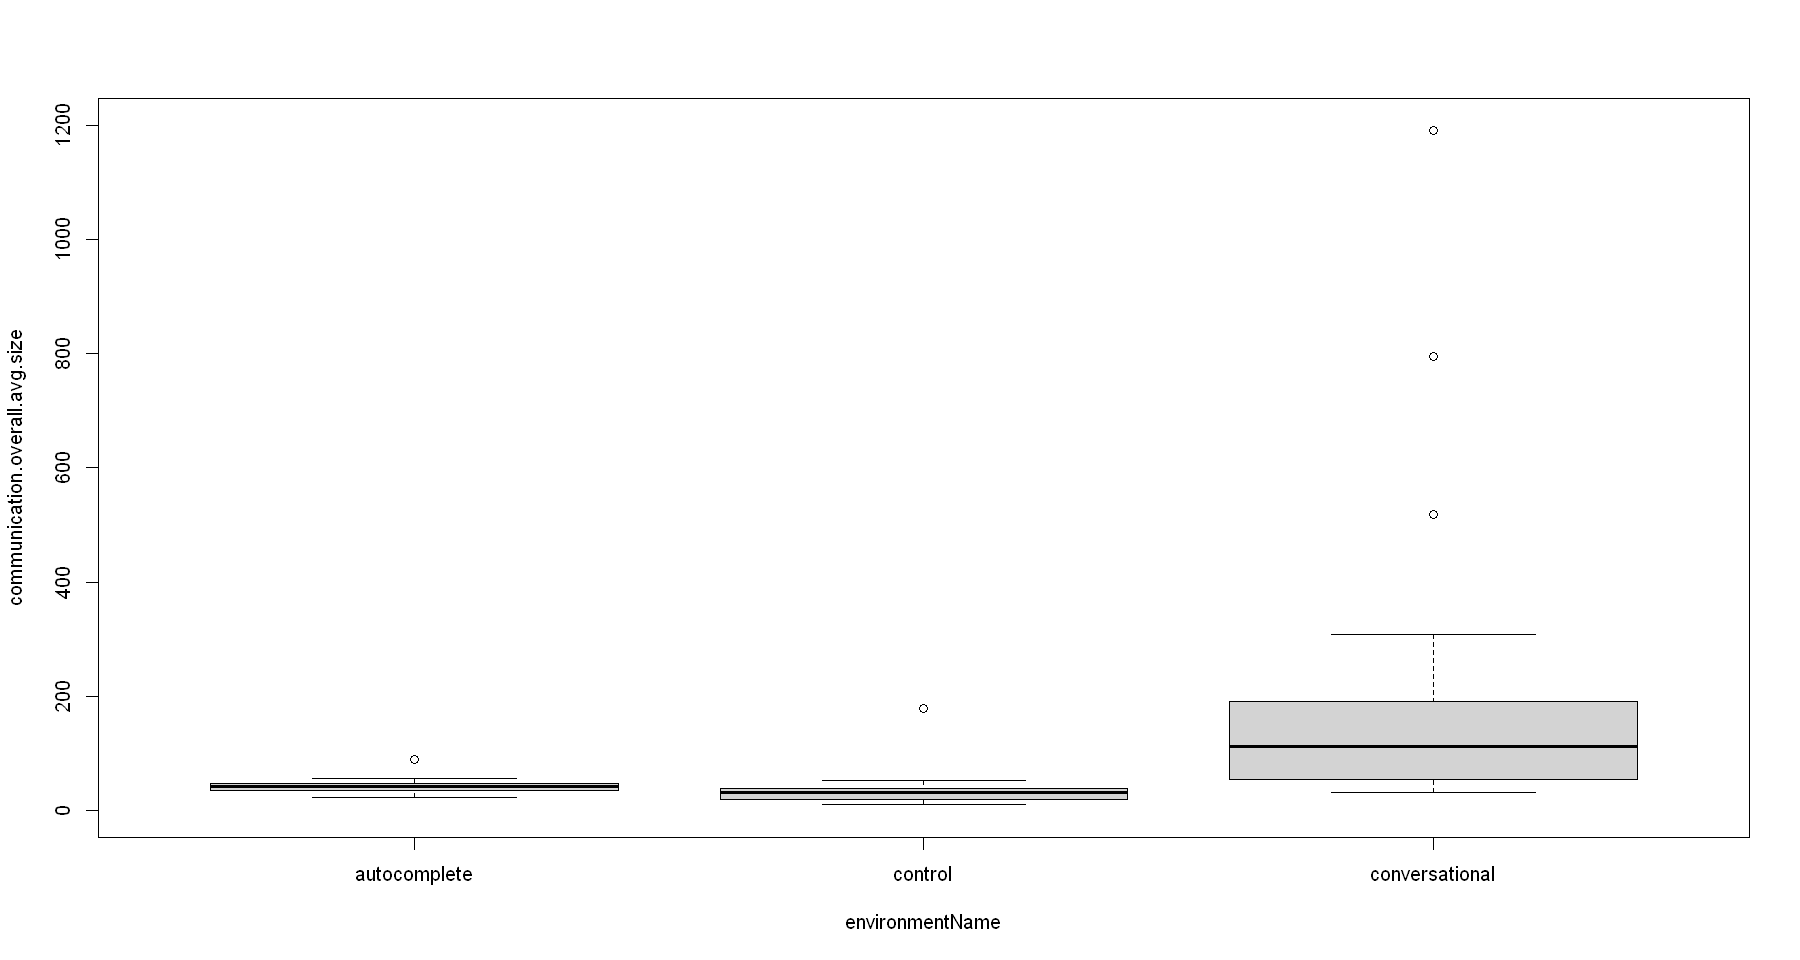

In [ ]:
df.conditions$communication.overall.new.snippets <- df.conditions$communicationBrowserNewSnippets + df.conditions$communicationAINewSnippets
df.conditions$communication.overall.characters <- df.conditions$communicationBrowserCharacters + df.conditions$communicationAICharacters
df.conditions$communication.overall.avg.size <- df.conditions$communication.overall.characters / df.conditions$communication.overall.new.snippets

comm.cols <- c(
    'communicationBrowserNewSnippets',
    'communicationBrowserCharacters',
    'communicationBrowserSnippetSize',
    'communicationAINewSnippets',
    'communicationAICharacters',
    'communicationAISnippetSize',
    'communication.overall.new.snippets',
    'communication.overall.characters',
    'communication.overall.avg.size'
)

i <- 0
for (col in comm.cols) {
    if (i %% 3 == 0) {
        ylim <- c(0, 30)
    } else if (i %% 3 == 1) {
        ylim <- c(0, 3600)
    } else {
        ylim <- c(0, 1200)
    }
    i <- i + 1
    print(col)
    boxplot(formula(paste(col, ' ~ environmentName')), data = df.conditions, ylim = ylim)
    
    shapiro <- shapiro.test(df.conditions[[col]])
    print(shapiro)
    f <- friedman.test(formula(paste(col, ' ~ environmentName | participantID')), data = df.conditions)
    print(f)
    f <- friedman.test(formula(paste(col, ' ~ taskName | participantID')), data = df.conditions)
    print(f)

    f.effect <- friedman_effsize(formula(paste(col, ' ~ environmentName | participantID')), data = df.conditions)
    print(f.effect)

    wilcox <- pairwise.wilcox.test(df.conditions[[col]], df.conditions$environmentName, p.adj = "bonf", paired=TRUE, exact=F)
    print(wilcox)
}

### Activity


	Shapiro-Wilk normality test

data:  df.conditions$activity.characters.normalized
W = 0.62745, p-value = 3.148e-12



	Friedman rank sum test

data:  activity.characters.normalized and environmentName and participantID
Friedman chi-squared = 23.083, df = 2, p-value = 9.717e-06

# A tibble: 1 × 5
  .y.                                n effsize method    magnitude
* <chr>                          <int>   <dbl> <chr>     <ord>    
1 activity.characters.normalized    24   0.481 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions$activity.characters.normalized and df.conditions$environmentName 

               autocomplete control
control        0.00011      -      
conversational 1.00000      0.00155

P value adjustment method: bonferroni 


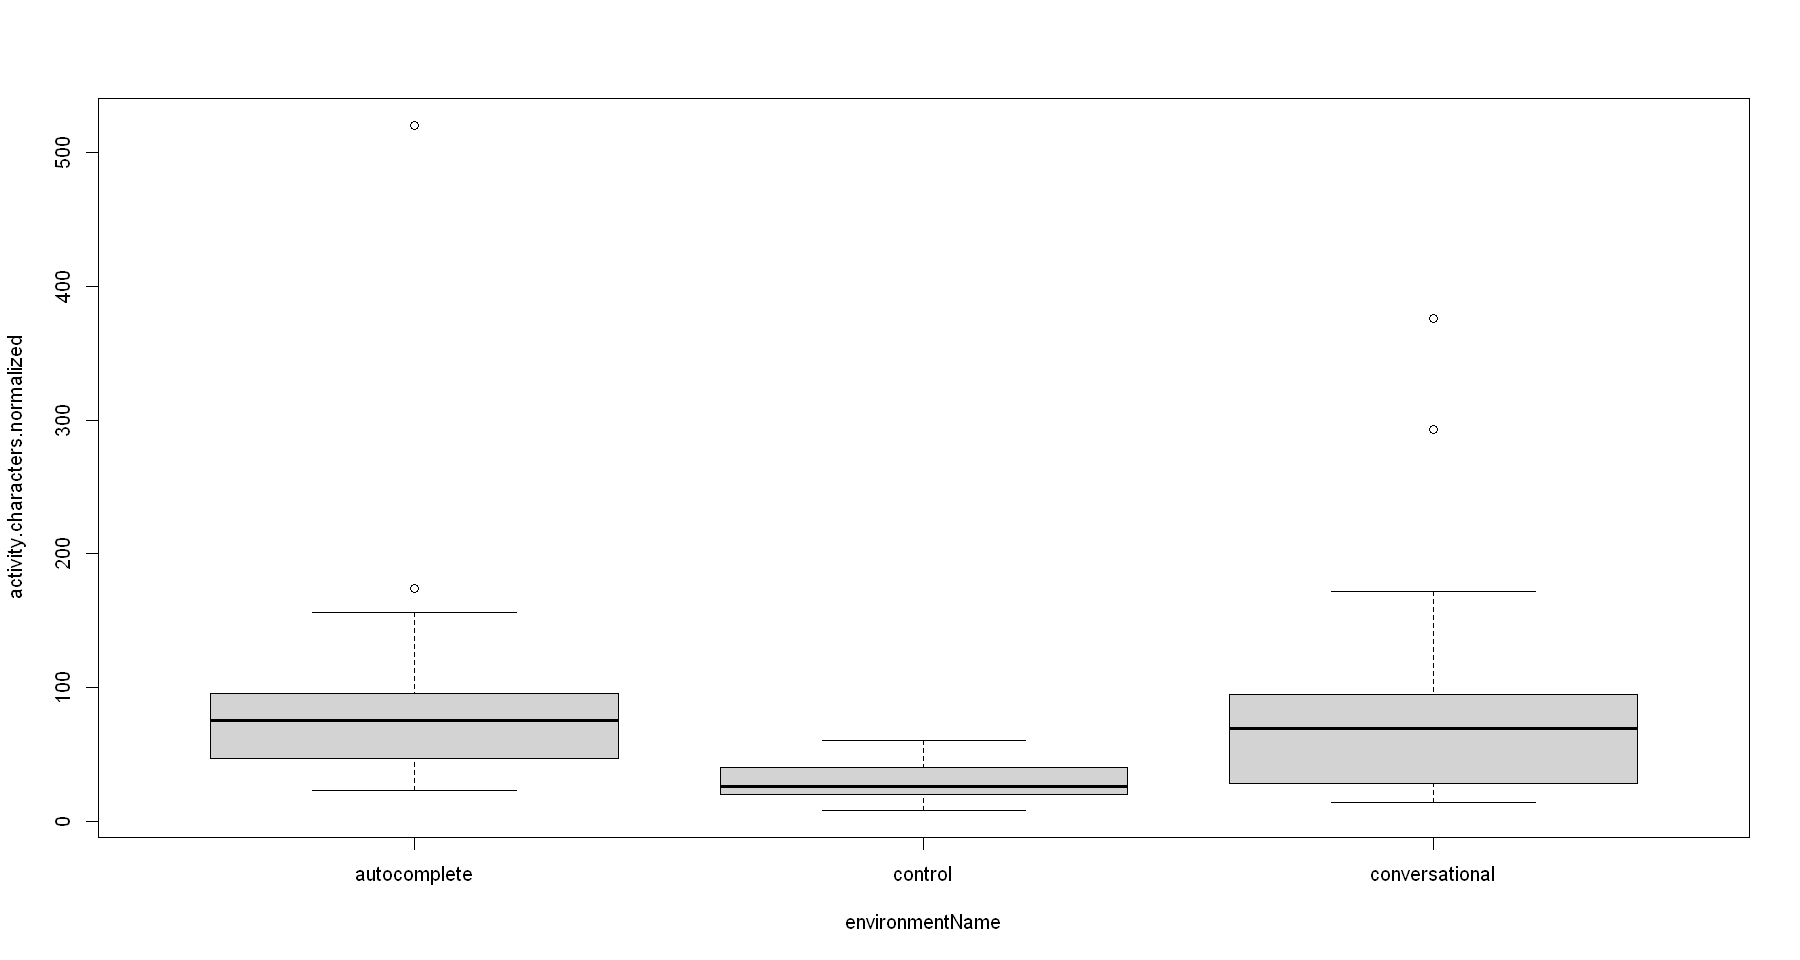

In [ ]:
# Character output per time

df.conditions$activity.characters.normalized <- df.conditions$activityCharacterOutput / as.numeric(df.conditions$total.task.time) * 60

shapiro.test(df.conditions$activity.characters.normalized)

boxplot(activity.characters.normalized ~ environmentName, data = df.conditions)

f <- friedman.test(activity.characters.normalized ~ environmentName | participantID, data = df.conditions)
print(f)

f.effect <- friedman_effsize(activity.characters.normalized ~ environmentName | participantID, data = df.conditions)
print(f.effect)

wilcox <- pairwise.wilcox.test(df.conditions$activity.characters.normalized, df.conditions$environmentName, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)



	Shapiro-Wilk normality test

data:  df.conditions$activity.percentage.self
W = 0.93119, p-value = 0.0007017



	Friedman rank sum test

data:  activity.percentage.self and environmentName and participantID
Friedman chi-squared = 27.75, df = 2, p-value = 9.422e-07

# A tibble: 1 × 5
  .y.                          n effsize method    magnitude
* <chr>                    <int>   <dbl> <chr>     <ord>    
1 activity.percentage.self    24   0.578 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions$activity.percentage.self and df.conditions$environmentName 

               autocomplete control
control        0.00072      -      
conversational 0.26739      0.00036

P value adjustment method: bonferroni 


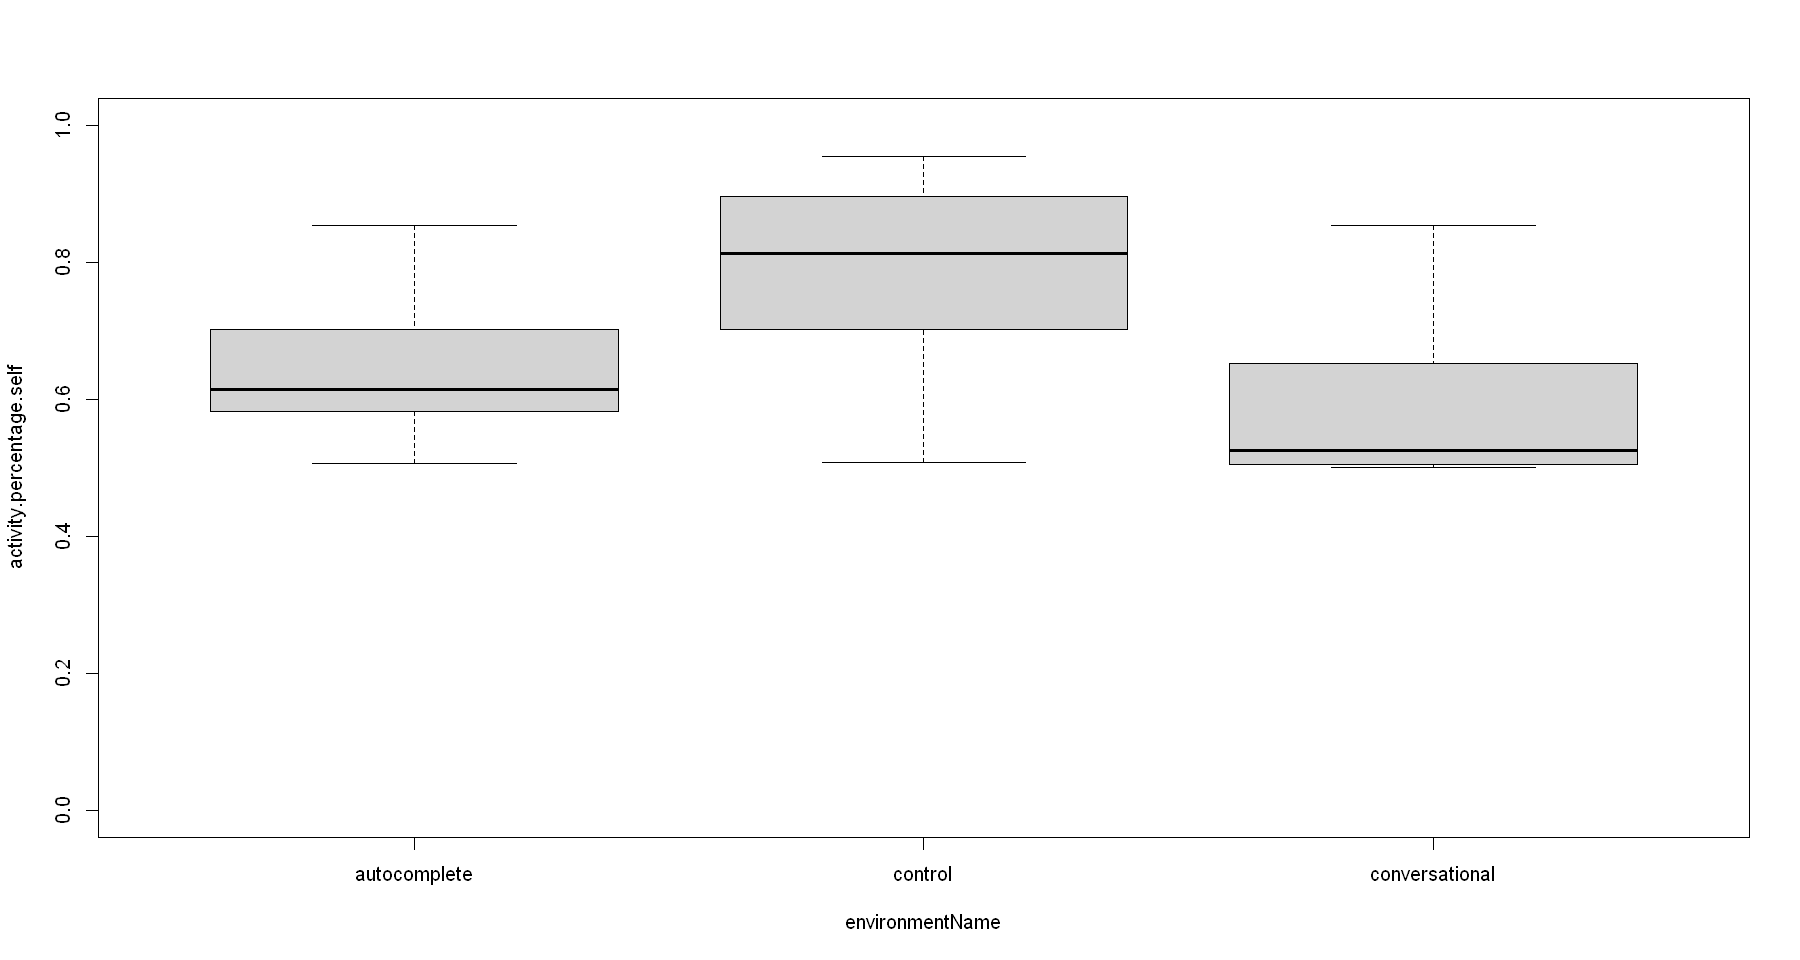

In [ ]:
# Percentage of code written by human

df.conditions$activity.percentage.self <- df.conditions$activityCharacterOutput / (df.conditions$activityCharacterOutput + df.conditions$communication.overall.characters)

shapiro.test(df.conditions$activity.percentage.self)

boxplot(activity.percentage.self ~ environmentName, data = df.conditions, ylim=c(0, 1))

f <- friedman.test(activity.percentage.self ~ environmentName | participantID, data = df.conditions)
print(f)

f.effect <- friedman_effsize(activity.percentage.self ~ environmentName | participantID, data = df.conditions)
print(f.effect)

wilcox <- pairwise.wilcox.test(df.conditions$activity.percentage.self, df.conditions$environmentName, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)


### Efficiency


	Shapiro-Wilk normality test

data:  as.numeric(df.conditions$total.task.time)
W = 0.71387, p-value = 1.508e-10


png 
  2


	Friedman rank sum test

data:  as.numeric(total.task.time) and environmentName and participantID
Friedman chi-squared = 6.5833, df = 2, p-value = 0.03719


	Friedman rank sum test

data:  as.numeric(total.task.time) and taskName and participantID
Friedman chi-squared = 4.3333, df = 2, p-value = 0.1146

# A tibble: 1 × 5
  .y.                             n effsize method    magnitude
* <chr>                       <int>   <dbl> <chr>     <ord>    
1 as.numeric(total.task.time)    24   0.137 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  as.numeric(df.conditions$total.task.time) and df.conditions$environmentName 

               autocomplete control
control        0.028        -      
conversational 1.000        0.025  

P value adjustment method: bonferroni 


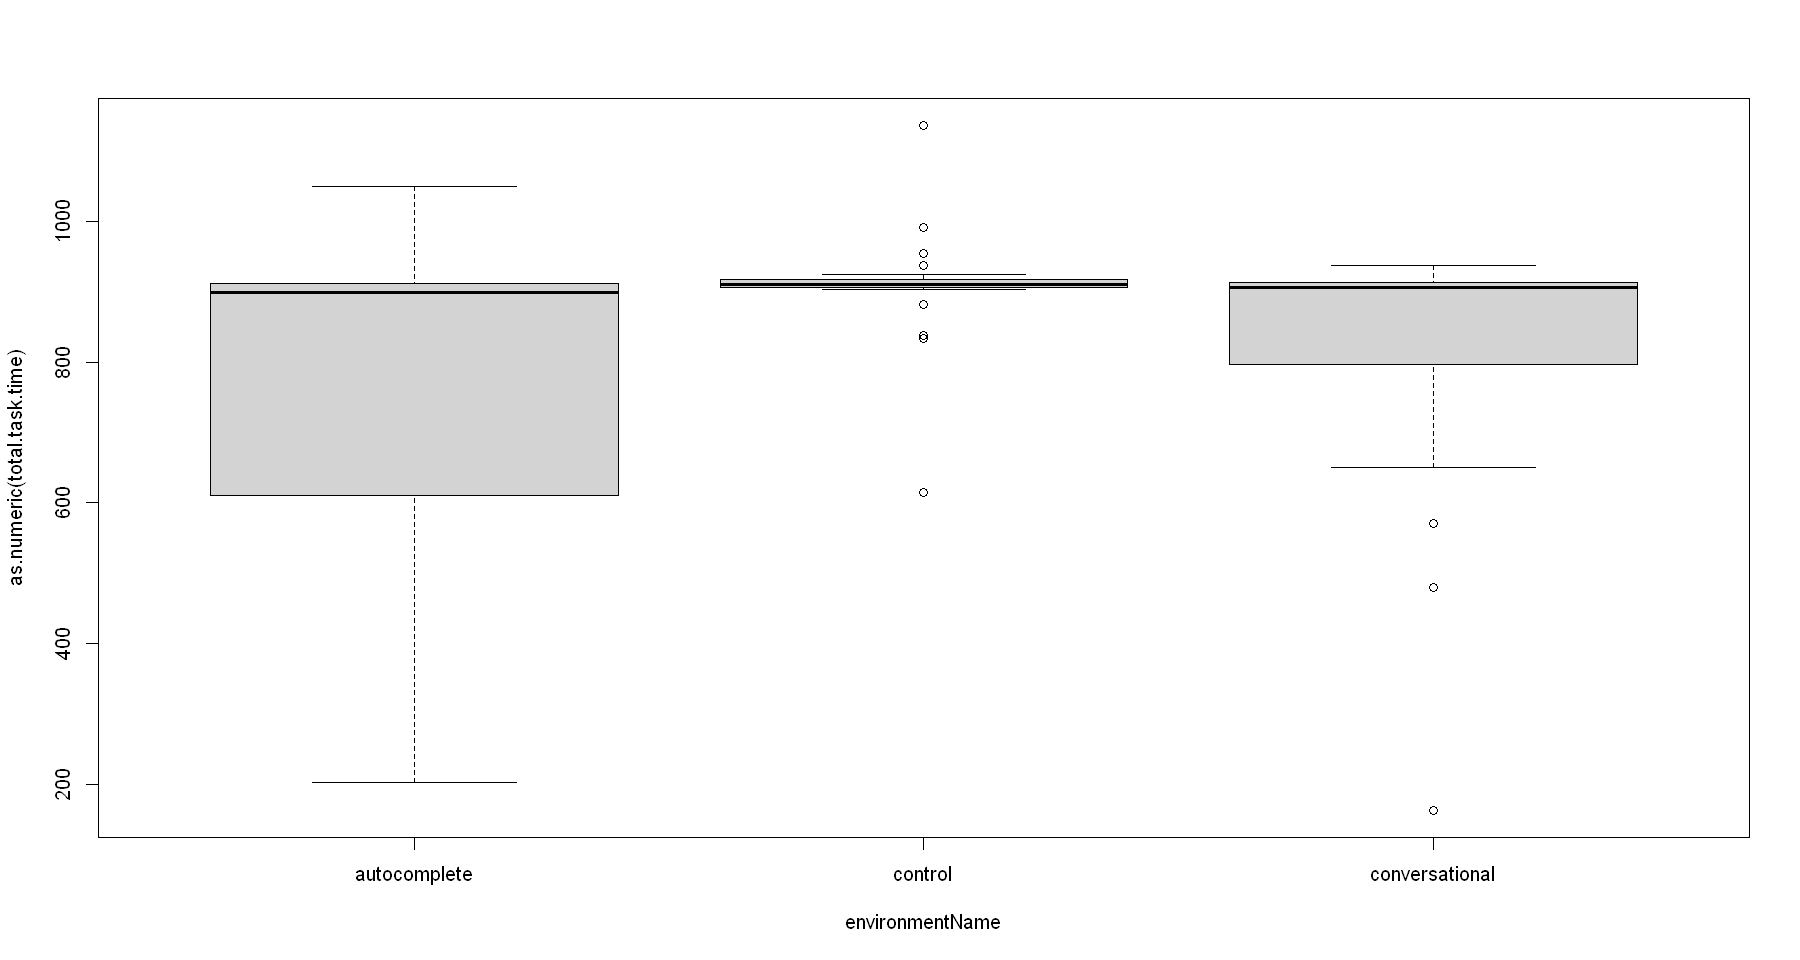

In [ ]:
shapiro.test(as.numeric(df.conditions$total.task.time))

svglite("out/post-conditions/activity-total-task-time.svg", width = 3, height = 4)
  boxplot(as.numeric(total.task.time) ~ environmentName, data = df.conditions)
dev.off()
boxplot(as.numeric(total.task.time) ~ environmentName, data = df.conditions)
f <- friedman.test(as.numeric(total.task.time) ~ environmentName | participantID, data = df.conditions)
print(f)
f <- friedman.test(as.numeric(total.task.time) ~ taskName | participantID, data = df.conditions)
print(f)

f.effect <- friedman_effsize(as.numeric(total.task.time) ~ environmentName | participantID, data = df.conditions)
print(f.effect)

wilcox <- pairwise.wilcox.test(as.numeric(df.conditions$total.task.time), df.conditions$environmentName, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)



	Shapiro-Wilk normality test

data:  df.conditions$reqiurements.implemented.normalized
W = 0.65531, p-value = 1.018e-11


png 
  2


	Friedman rank sum test

data:  reqiurements.implemented.normalized and environmentName and participantID
Friedman chi-squared = 23.083, df = 2, p-value = 9.717e-06

# A tibble: 1 × 5
  .y.                                     n effsize method    magnitude
* <chr>                               <int>   <dbl> <chr>     <ord>    
1 reqiurements.implemented.normalized    24   0.481 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.conditions$reqiurements.implemented.normalized and df.conditions$environmentName 

               autocomplete control
control        0.00011      -      
conversational 0.20890      0.00036

P value adjustment method: bonferroni 


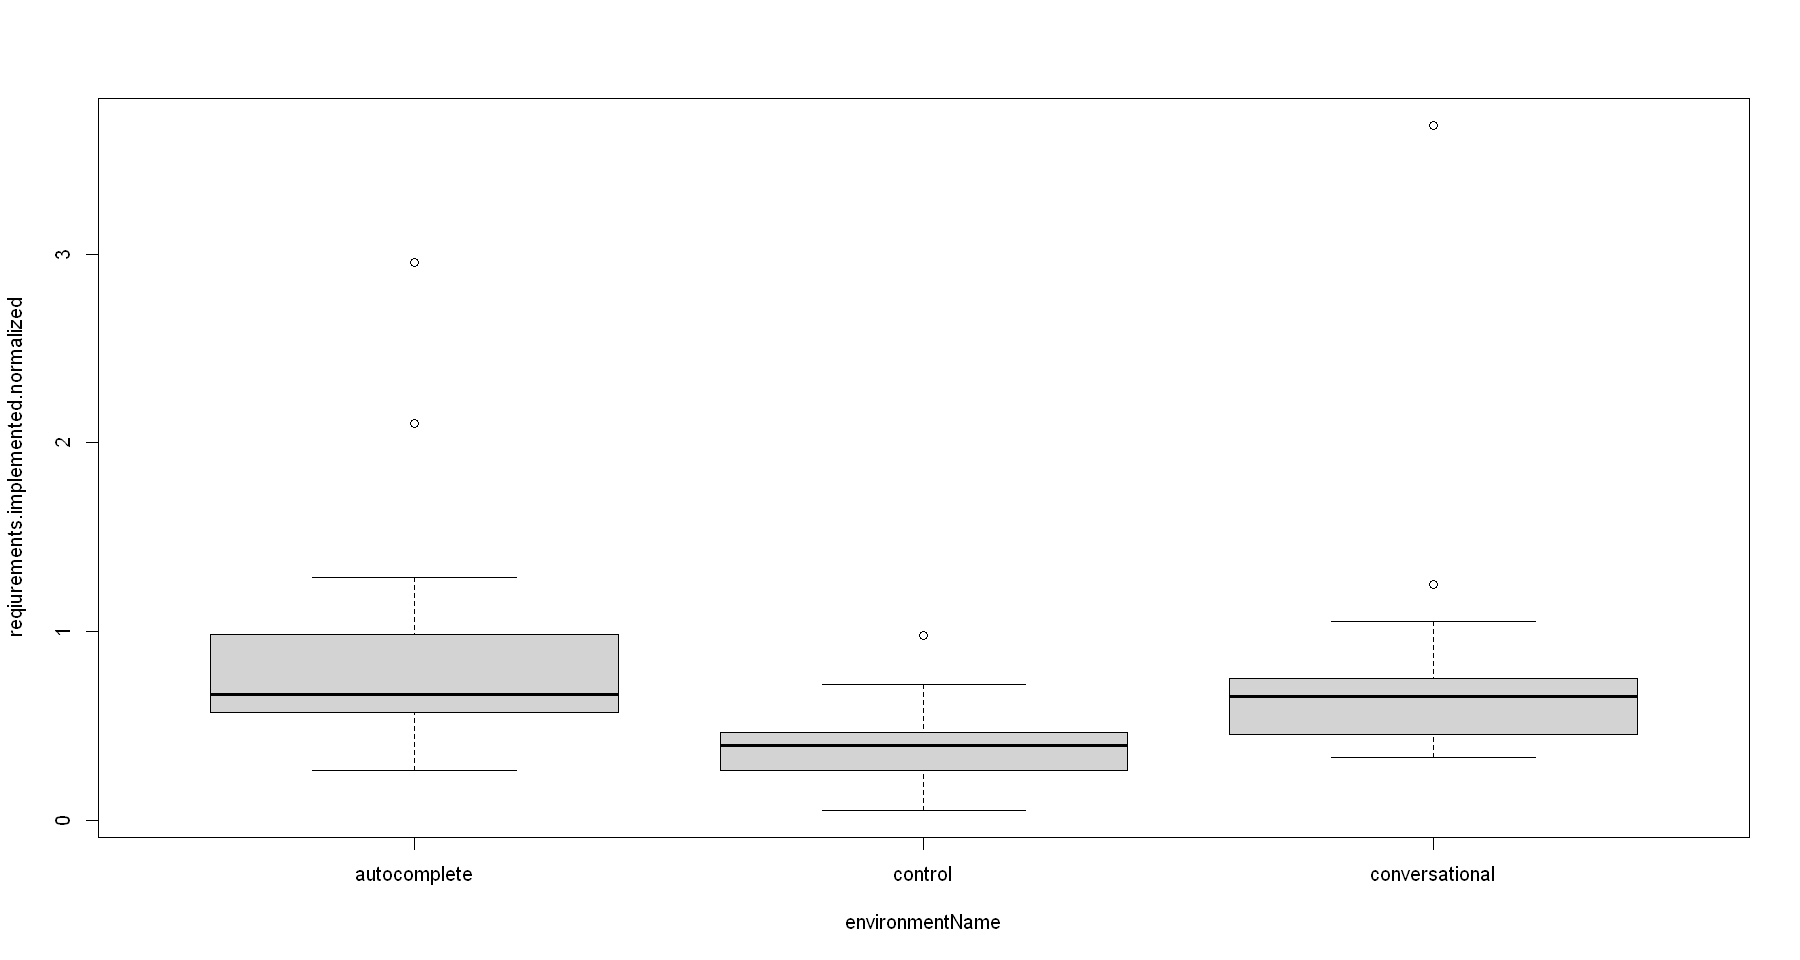

In [ ]:
df.conditions$reqiurements.implemented.normalized <- df.conditions$speedRequirementsImplemented / as.numeric(df.conditions$total.task.time) * 60

shapiro.test(df.conditions$reqiurements.implemented.normalized)

svglite("out/post-conditions/efficiency-requirements.svg", width = 3, height = 4)
  boxplot(reqiurements.implemented.normalized ~ environmentName, data = df.conditions)
dev.off()
boxplot(reqiurements.implemented.normalized ~ environmentName, data = df.conditions)
f <- friedman.test(reqiurements.implemented.normalized ~ environmentName | participantID, data = df.conditions)
print(f)

f.effect <- friedman_effsize(reqiurements.implemented.normalized ~ environmentName | participantID, data = df.conditions)
print(f.effect)

wilcox <- pairwise.wilcox.test(df.conditions$reqiurements.implemented.normalized, df.conditions$environmentName, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)


# Feedback from end survey

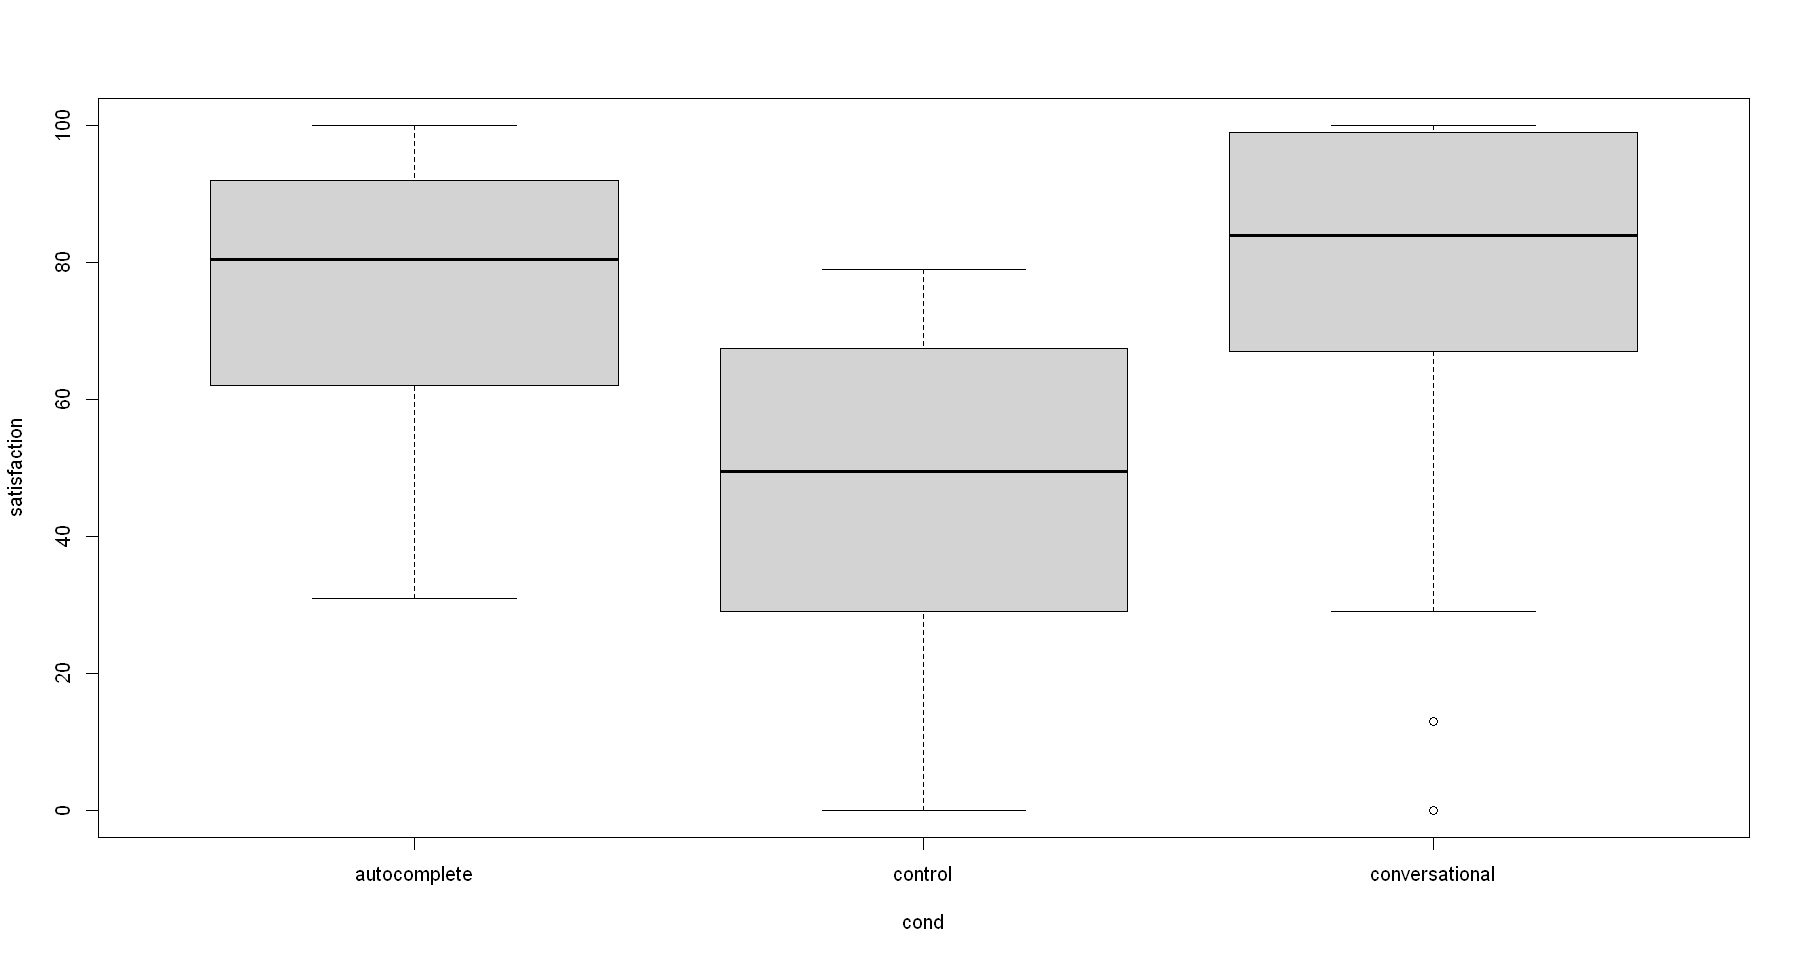

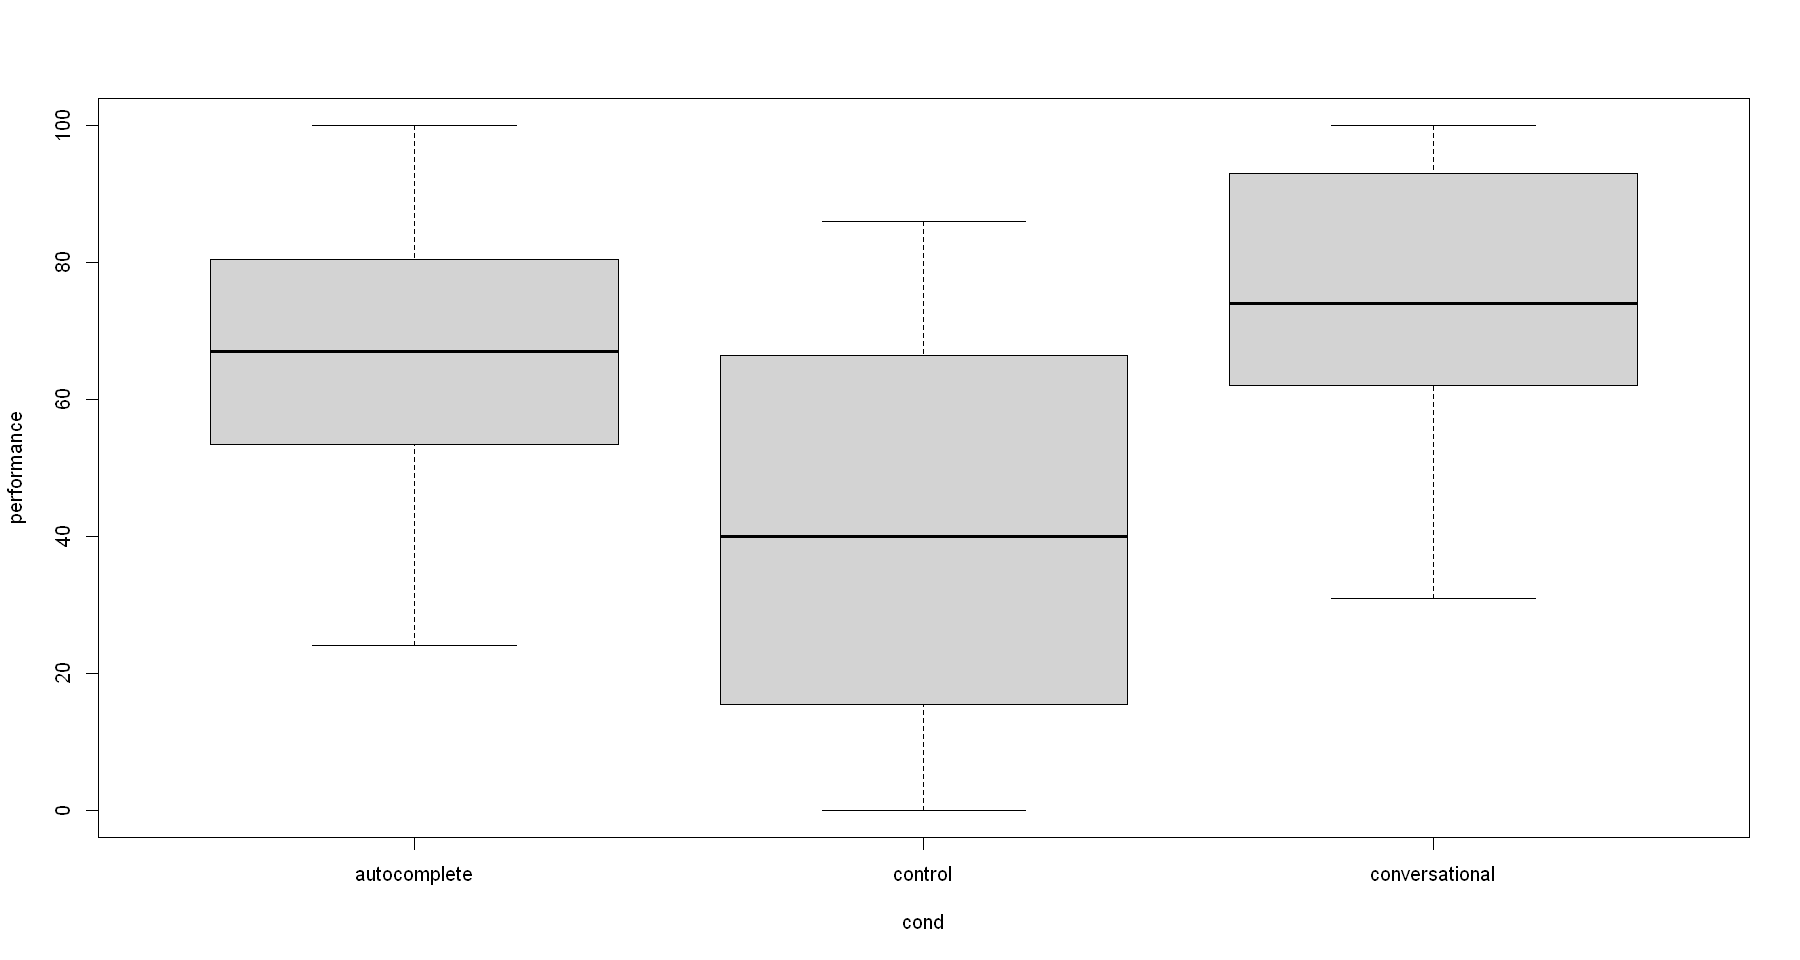

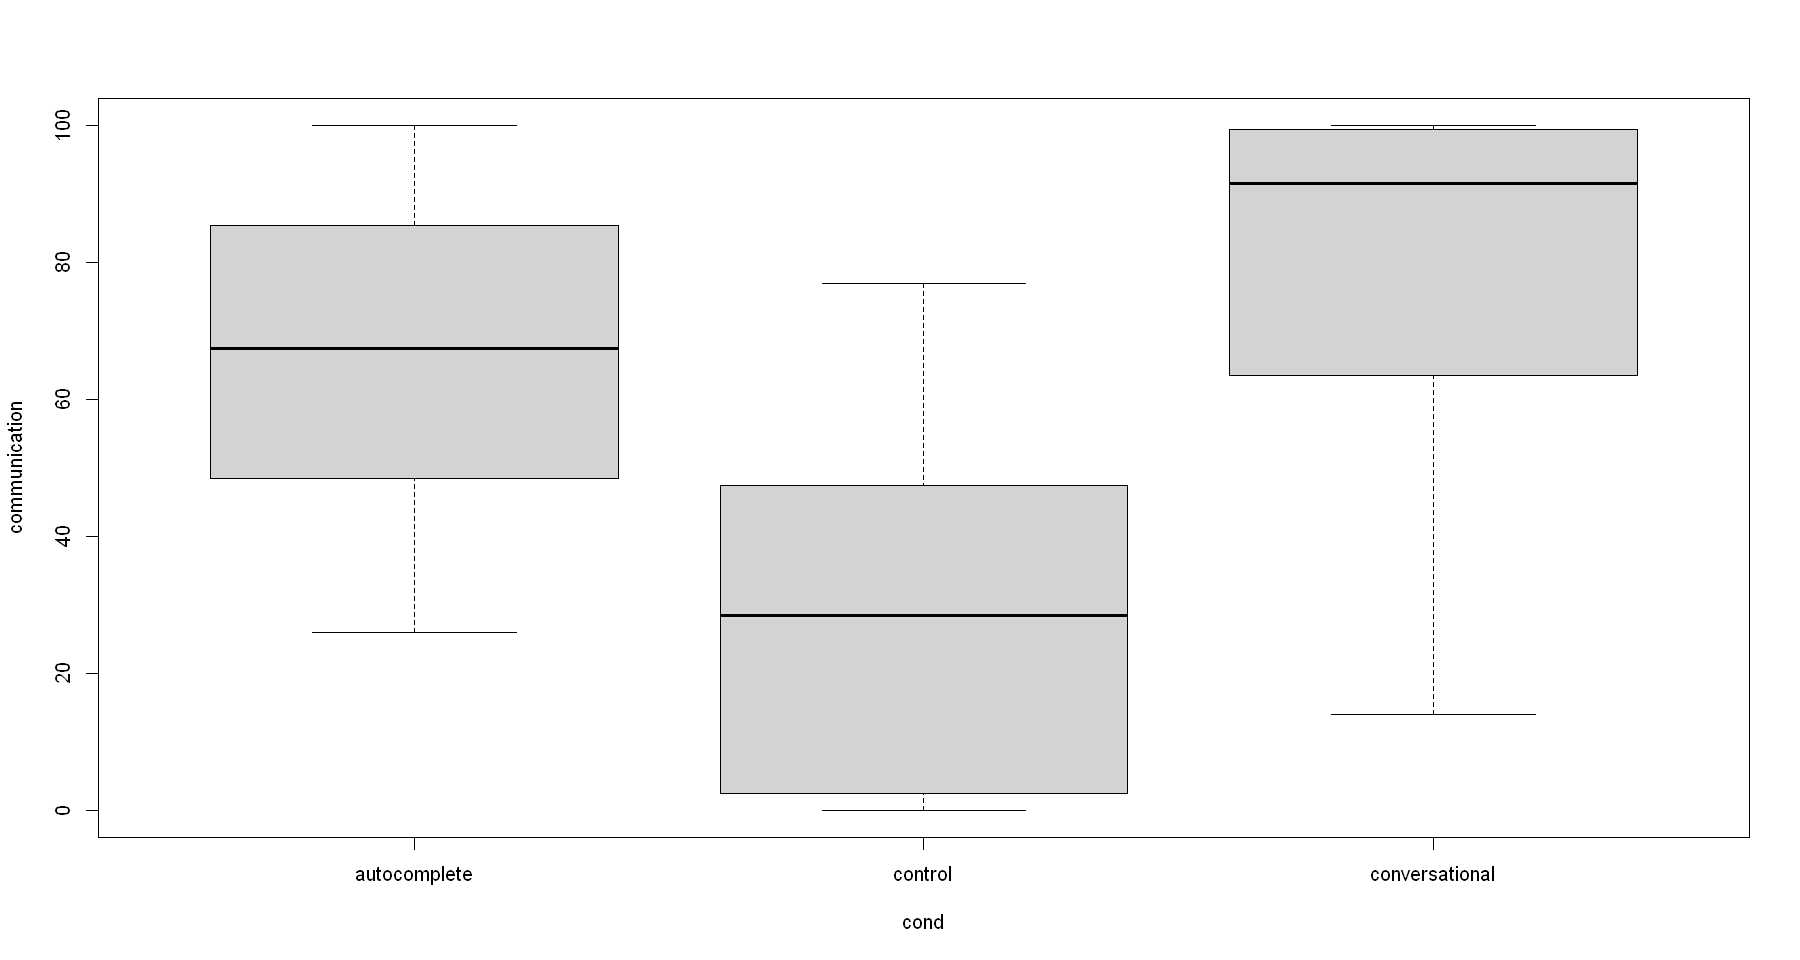

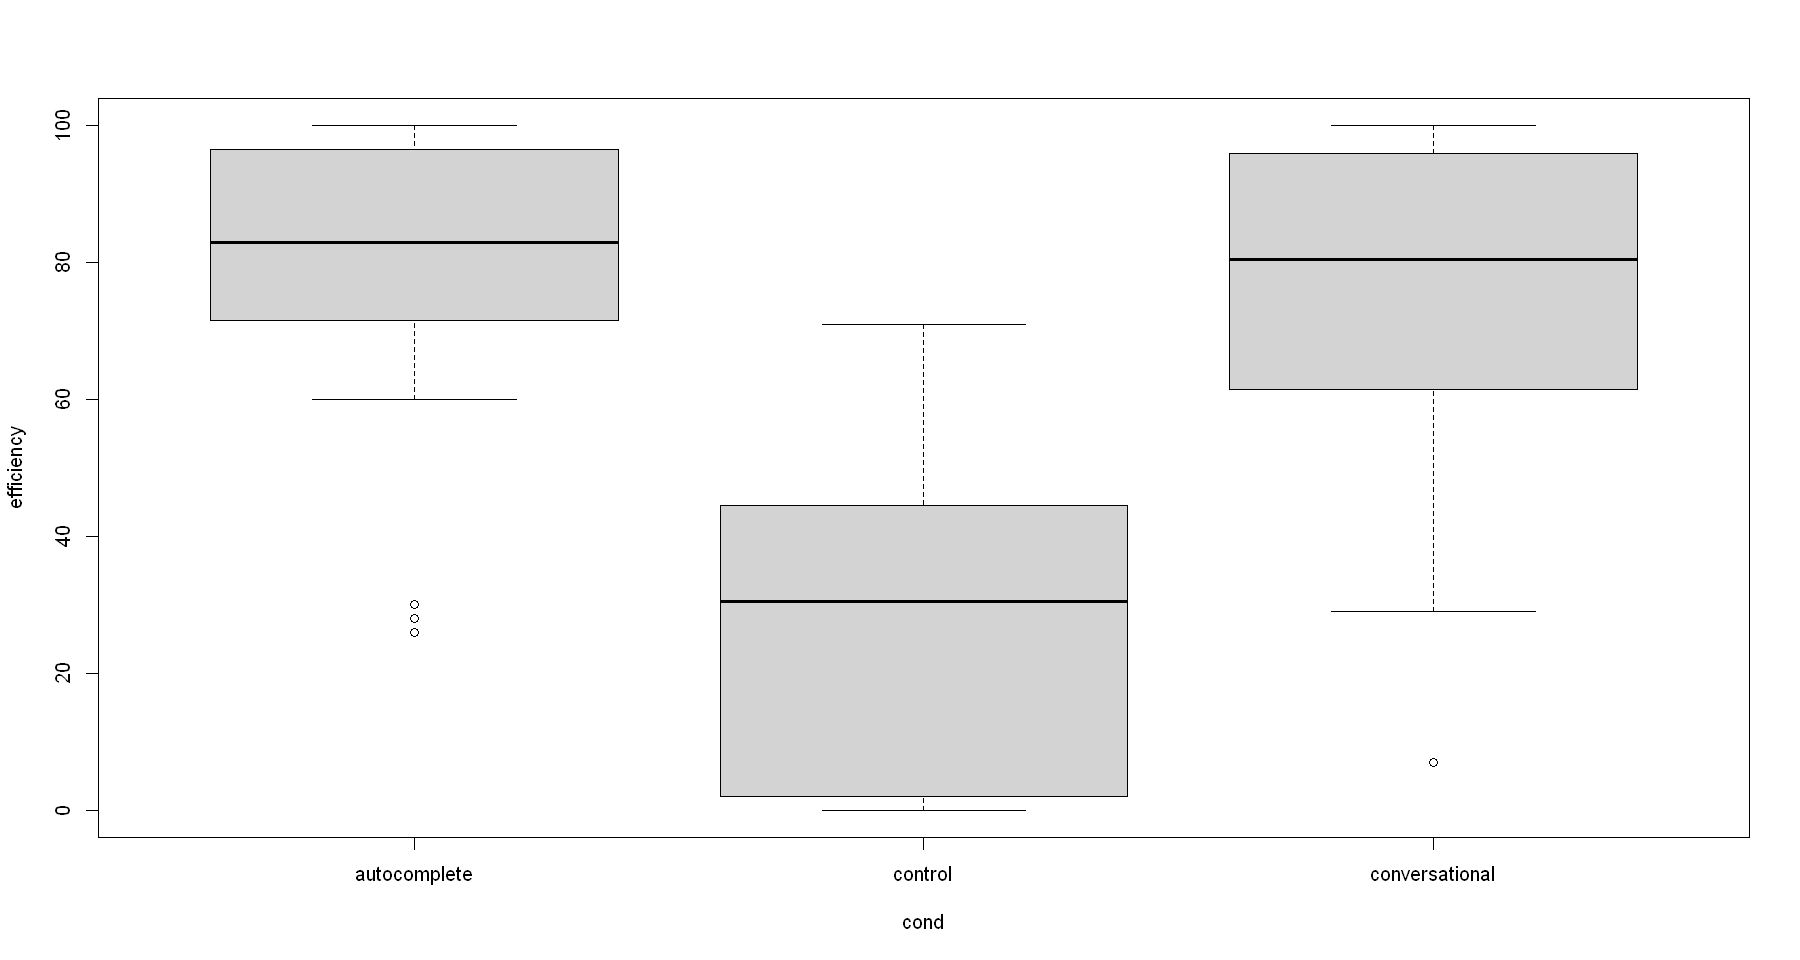

In [ ]:
# Post-Survey Self-Assessment

self.assessment.satisfaction <- rbind(
    data.frame(cond = 'control', pid = df.surveys$participantID, satisfaction = df.surveys$controlStatisfaction),
    data.frame(cond = 'autocomplete', pid = df.surveys$participantID, satisfaction = df.surveys$autocompleteStatisfaction),
    data.frame(cond = 'conversational', pid = df.surveys$participantID, satisfaction = df.surveys$conversationalStatisfaction))
boxplot(satisfaction ~ cond, data = self.assessment.satisfaction)

self.assessment.performance <- rbind(
    data.frame(cond = 'control', pid = df.surveys$participantID, performance = df.surveys$controlQuality),
    data.frame(cond = 'autocomplete', pid = df.surveys$participantID, performance = df.surveys$autocompleteQuality),
    data.frame(cond = 'conversational', pid = df.surveys$participantID, performance = df.surveys$conversationalQuality))
boxplot(performance  ~ cond, data = self.assessment.performance)

self.assessment.communication <- rbind(
    data.frame(cond = 'control', pid = df.surveys$participantID, communication = df.surveys$controlCommunication),
    data.frame(cond = 'autocomplete', pid = df.surveys$participantID, communication = df.surveys$autocompleteCommunication),
    data.frame(cond = 'conversational', pid = df.surveys$participantID, communication = df.surveys$conversationalCommunication))
boxplot(communication ~ cond, data = self.assessment.communication)

self.assessment.efficiency <- rbind(
    data.frame(cond = 'control', pid = df.surveys$participantID, efficiency = df.surveys$controlSpeed),
    data.frame(cond = 'autocomplete', pid = df.surveys$participantID, efficiency = df.surveys$autocompleteSpeed),
    data.frame(cond = 'conversational', pid = df.surveys$participantID, efficiency = df.surveys$conversationalSpeed))
boxplot(efficiency ~ cond, data = self.assessment.efficiency)



In [ ]:
shapiro.test(self.assessment.satisfaction$satisfaction)
shapiro.test(self.assessment.performance$performance)
shapiro.test(self.assessment.communication$communication)
shapiro.test(self.assessment.efficiency$efficiency)


	Shapiro-Wilk normality test

data:  self.assessment.satisfaction$satisfaction
W = 0.91405, p-value = 0.0001174



	Shapiro-Wilk normality test

data:  self.assessment.performance$performance
W = 0.95379, p-value = 0.009992



	Shapiro-Wilk normality test

data:  self.assessment.communication$communication
W = 0.92534, p-value = 0.0003737



	Shapiro-Wilk normality test

data:  self.assessment.efficiency$efficiency
W = 0.90076, p-value = 3.281e-05


> All self assessment are non-normal --> Non-parametric tests

In [ ]:
# Satisfaction

f <- friedman.test(satisfaction ~ cond | pid, data = self.assessment.satisfaction)
print(f)

f.effect <- friedman_effsize(satisfaction ~ cond | pid, data = self.assessment.satisfaction)
print(f.effect)

wilcox <- pairwise.wilcox.test(self.assessment.satisfaction$satisfaction, self.assessment.satisfaction$cond, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)


	Friedman rank sum test

data:  satisfaction and cond and pid
Friedman chi-squared = 21.894, df = 2, p-value = 1.761e-05

# A tibble: 1 × 5
  .y.              n effsize method    magnitude
* <chr>        <int>   <dbl> <chr>     <ord>    
1 satisfaction    24   0.456 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  self.assessment.satisfaction$satisfaction and self.assessment.satisfaction$cond 

               autocomplete control
control        0.0011       -      
conversational 1.0000       0.0162 

P value adjustment method: bonferroni 


In [ ]:
# Performance

f <- friedman.test(performance ~ cond | pid, data = self.assessment.performance)
print(f)

f.effect <- friedman_effsize(performance ~ cond | pid, data = self.assessment.performance)
print(f.effect)

wilcox <- pairwise.wilcox.test(self.assessment.performance$performance, self.assessment.performance$cond, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)


	Friedman rank sum test

data:  performance and cond and pid
Friedman chi-squared = 18.087, df = 2, p-value = 0.0001182

# A tibble: 1 × 5
  .y.             n effsize method    magnitude
* <chr>       <int>   <dbl> <chr>     <ord>    
1 performance    24   0.377 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  self.assessment.performance$performance and self.assessment.performance$cond 

               autocomplete control
control        0.0029       -      
conversational 0.2281       0.0020 

P value adjustment method: bonferroni 


In [ ]:
# Communicatoin

f <- friedman.test(communication ~ cond | pid, data = self.assessment.communication)
print(f)

f.effect <- friedman_effsize(communication ~ cond | pid, data = self.assessment.communication)
print(f.effect)

wilcox <- pairwise.wilcox.test(self.assessment.communication$communication, self.assessment.communication$cond, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)


	Friedman rank sum test

data:  communication and cond and pid
Friedman chi-squared = 18.083, df = 2, p-value = 0.0001184

# A tibble: 1 × 5
  .y.               n effsize method    magnitude
* <chr>         <int>   <dbl> <chr>     <ord>    
1 communication    24   0.377 Kendall W moderate 

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  self.assessment.communication$communication and self.assessment.communication$cond 

               autocomplete control
control        0.00354      -      
conversational 0.13607      0.00057

P value adjustment method: bonferroni 


In [ ]:
# Efficiency

f <- friedman.test(efficiency ~ cond | pid, data = self.assessment.efficiency)
print(f)

f.effect <- friedman_effsize(efficiency ~ cond | pid, data = self.assessment.efficiency)
print(f.effect)

wilcox <- pairwise.wilcox.test(self.assessment.efficiency$efficiency, self.assessment.efficiency$cond, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)


	Friedman rank sum test

data:  efficiency and cond and pid
Friedman chi-squared = 25.333, df = 2, p-value = 3.155e-06

# A tibble: 1 × 5
  .y.            n effsize method    magnitude
* <chr>      <int>   <dbl> <chr>     <ord>    
1 efficiency    24   0.528 Kendall W large    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  self.assessment.efficiency$efficiency and self.assessment.efficiency$cond 

               autocomplete control
control        8e-05        -      
conversational 1.00000      0.00081

P value adjustment method: bonferroni 


# Analysis of the generated source code

In [ ]:
# code.csv contains LoC and comments for each generated piece of code from the study
# uses cloc command line tool (https://cloc.sourceforge.net)
df.code <- read.csv('csv/code.csv')

In [ ]:
code.by.task <- rbind(
  data.frame(task = 'pdf', code = df.code[df.code$control.task == 'pdf',]$control.code, pid = df.code[df.code$control.task == 'pdf',]$pid),
  data.frame(task = 'pdf', code = df.code[df.code$auto.task == 'pdf',]$auto.code, pid = df.code[df.code$auto.task == 'pdf',]$pid),
  data.frame(task = 'pdf', code = df.code[df.code$conv.task == 'pdf',]$conv.code, pid = df.code[df.code$conv.task == 'pdf',]$pid),

  data.frame(task = 'csv', code = df.code[df.code$control.task == 'csv',]$control.code, pid = df.code[df.code$control.task == 'csv',]$pid),
  data.frame(task = 'csv', code = df.code[df.code$auto.task == 'csv',]$auto.code, pid = df.code[df.code$auto.task == 'csv',]$pid),
  data.frame(task = 'csv', code = df.code[df.code$conv.task == 'csv',]$conv.code, pid = df.code[df.code$conv.task == 'csv',]$pid),

  data.frame(task = 'txt', code = df.code[df.code$control.task == 'txt',]$control.code, pid = df.code[df.code$control.task == 'txt',]$pid),
  data.frame(task = 'txt', code = df.code[df.code$auto.task == 'txt',]$auto.code, pid = df.code[df.code$auto.task == 'txt',]$pid),
  data.frame(task = 'txt', code = df.code[df.code$conv.task == 'txt',]$conv.code, pid = df.code[df.code$conv.task == 'txt',]$pid)
)

df.code$control.percentage <- df.code$control.comments / (df.code$control.code + df.code$control.comments)
df.code$auto.percentage <- df.code$auto.comments / (df.code$auto.code + df.code$auto.comments)
df.code$conv.percentage <- df.code$conv.comments / (df.code$conv.code + df.code$conv.comments)

df.comment.percentage = rbind(
  data.frame(env = 'control', percentage = df.code$control.percentage, pid = df.code$pid),
  data.frame(env = 'autocomplete', percentage = df.code$auto.percentage, pid = df.code$pid),
  data.frame(env = 'conversational', percentage = df.code$conv.percentage, pid = df.code$pid)
)


	Shapiro-Wilk normality test

data:  df.comment.percentage$percentage
W = 0.92542, p-value = 0.0003769



	Friedman rank sum test

data:  percentage and env and pid
Friedman chi-squared = 8.5833, df = 2, p-value = 0.01368

# A tibble: 1 × 5
  .y.            n effsize method    magnitude
* <chr>      <int>   <dbl> <chr>     <ord>    
1 percentage    24   0.179 Kendall W small    

	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df.comment.percentage$percentage and df.comment.percentage$env 

               autocomplete control
control        0.0014       -      
conversational 0.2674       0.1072 

P value adjustment method: bonferroni 


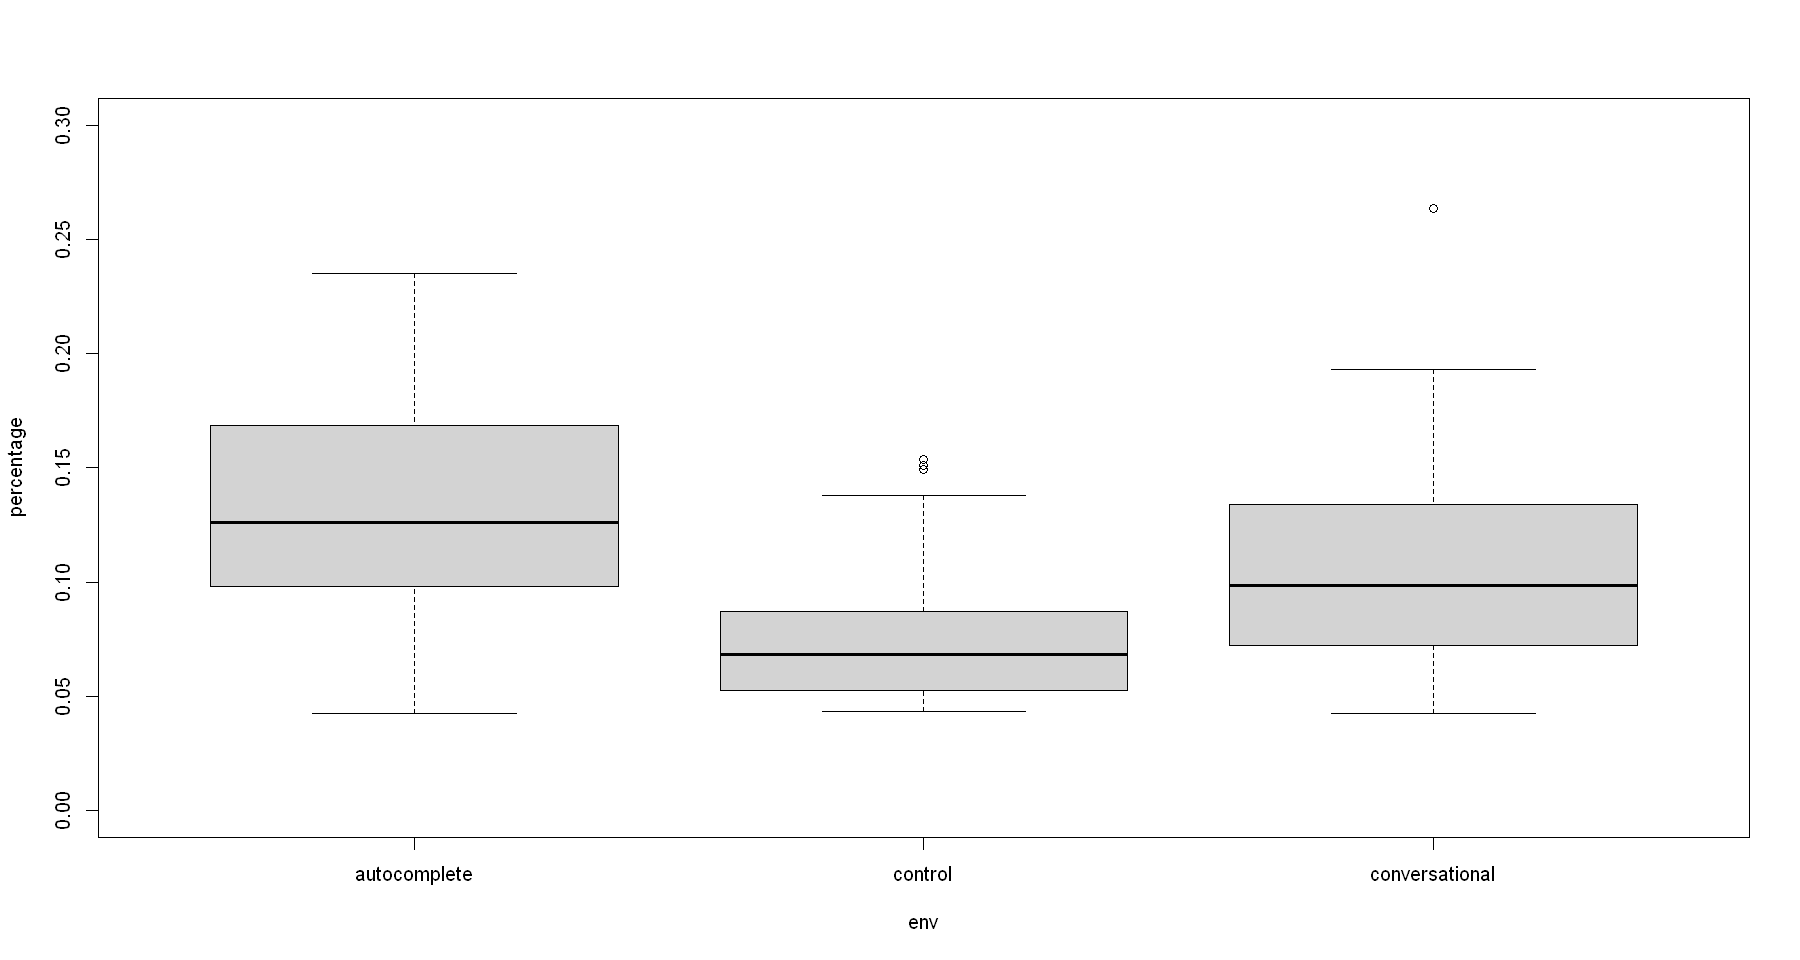

In [ ]:
boxplot(percentage ~ env, data = df.comment.percentage, ylim=c(0,0.3))

shapiro.test(df.comment.percentage$percentage)
f <- friedman.test(percentage ~ env | pid, data = df.comment.percentage)
print(f)

f.effect <- friedman_effsize(percentage ~ env | pid, data = df.comment.percentage)
print(f.effect)

wilcox <- pairwise.wilcox.test(df.comment.percentage$percentage, df.comment.percentage$env, p.adj = "bonf", paired=TRUE, exact=F)
print(wilcox)

# Analysis of the Outliers

In [ ]:
# The following categories have outliers as per visual analysis of the boxplots
# They have different formats in their respective data frames and thus are 
# preprocessed into a single data frame  for later analysis

# % of correctly implemented requirements
d1 <- cond.performance[c('percentage.quality', 'env', 'pid')]
# Percentage of comments
d2 <- df.comment.percentage

# Practical Quality 
# Hedonic Quality
d3 <- cond.satisfaction[c('pq', 'hq', 'pid', 'env')]

d4 <- df.conditions[c(
    # Total time on tasks
    'total.task.time',
    
    # Human output
    'activity.percentage.self', 

    # Communication
    'communicationBrowserNewSnippets',
    'communicationBrowserCharacters',
    'communicationBrowserSnippetSize',
    'communicationAINewSnippets',
    'communicationAICharacters',
    'communicationAISnippetSize',
    'communication.overall.new.snippets',
    'communication.overall.characters',
    'communication.overall.avg.size',

    # # of requirements implemented per minute
    'reqiurements.implemented.normalized',

    'participantID',
    'environmentName'
)]

# Subjective Satisfaction
d5 <- self.assessment.satisfaction
# Subjective Efficiency
d6 <- self.assessment.efficiency

d12 <- merge(d1, d2, by = c('env', 'pid'))
d123 <- merge(d12, d3, by = c('env', 'pid'))
d1234 <- merge(d123, d4, by.x = c('env', 'pid'), by.y = c('environmentName', 'participantID'))
d12345 <- merge(d1234, d5, by.x = c('env', 'pid'), by.y = c('cond', 'pid'))
d123456 <- merge(d12345, d6, by.x = c('env', 'pid'), by.y = c('cond', 'pid'))
df.outliers <- d123456

In [ ]:
names(df.outliers) <- c(
  'env',
  'pid',
  'percentage.of.correctly.implemented.requirements',
  'percentage.of.comments',
  'pragmatic.quality',
  'hedonic.quality',
  'total.task.time',
  'activity.percentage.code.from.human',
  'communication.Browser.number.of.snippets',
  'communication.Browser.number.of.characters',
  'communication.Browser.avg.snippet.size',
  'communication.AI.number.of.snippets',
  'communication.AI.number.of.characters',
  'communication.AI.avg.snippet.size',
  'communication.total.number.of.snippets',
  'communication.total.number.of.characters',
  'communication.total.avg.snippet.size',
  'num.of.correctly.implemented.requirements.per.minute',
  'subjective.satisfaction',
  'subjective.efficiency'
)

In [ ]:
# Generate a list of each column and condition where a participant prodcued outliers

for (col in names(df.outliers)) {
  if (col != 'env' && col != 'pid') {
    for (env in c('control', 'autocomplete', 'conversational')) {

      iqr <- IQR(df.outliers[df.outliers$env == env, col])
      tmin <- quantile(df.outliers[df.outliers$env == env, col], 0.25) - 1.5 * iqr
      tmax <- quantile(df.outliers[df.outliers$env == env, col], 0.75) + 1.5 * iqr

      # Get pid of all rows where col < tmin or col > tmax 
      outliers <- df.outliers[df.outliers$env == env & (df.outliers[,col] < tmin | df.outliers[,col] > tmax),]$pid

      if (length(outliers) > 0) {
        # print(paste(col, ' - ', env, sep=''))
        for (pid in outliers) {
          print(paste(col, env, pid, sep=', '))
        }
      }
    }
  }
}

[1] "percentage.of.correctly.implemented.requirements, control, 13"
[1] "percentage.of.correctly.implemented.requirements, control, 14"
[1] "percentage.of.correctly.implemented.requirements, conversational, 2"
[1] "percentage.of.comments, control, 13"
[1] "percentage.of.comments, control, 14"
[1] "percentage.of.comments, control, 18"
[1] "percentage.of.comments, control, 29"
[1] "percentage.of.comments, conversational, 10"
[1] "pragmatic.quality, autocomplete, 22"
[1] "pragmatic.quality, conversational, 6"
[1] "hedonic.quality, control, 14"
[1] "total.task.time, control, 1"
[1] "total.task.time, control, 10"
[1] "total.task.time, control, 17"
[1] "total.task.time, control, 23"
[1] "total.task.time, control, 24"
[1] "total.task.time, control, 26"
[1] "total.task.time, control, 29"
[1] "total.task.time, control, 4"
[1] "total.task.time, conversational, 11"
[1] "total.task.time, conversational, 14"
[1] "total.task.time, conversational, 19"
[1] "total.task.time, conversational, 24"
[1] "co

In [ ]:
# The majority (40) of these outliers was generated by the participants with these pids
outlier.pid <- c(2,4,14,19,22,24)
df.surveys.outliers <- df.surveys[df.surveys$participantID %in% outlier.pid,]
df.surveys.majority <- df.surveys[!(df.surveys$participantID %in% outlier.pid),]

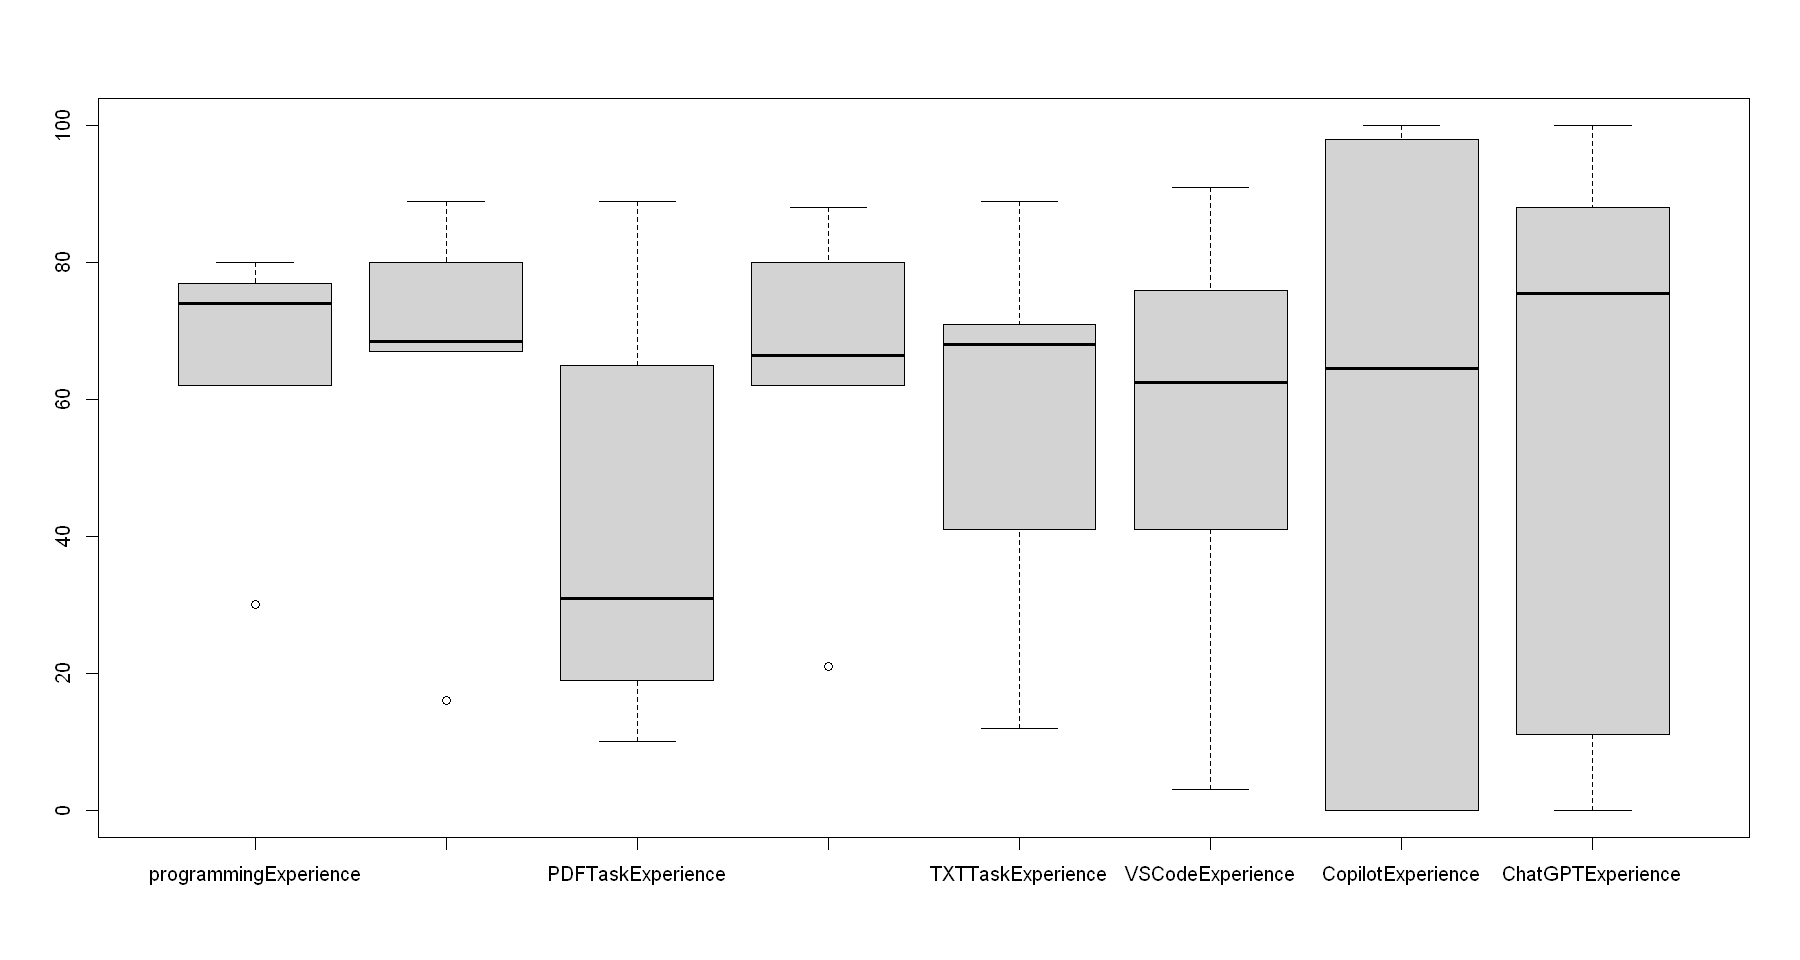

[1] "programmingExperience"


Warning message in wilcox.test.default(df.surveys.outliers[, col], df.surveys.majority[, :
"cannot compute exact p-value with ties"



	Wilcoxon rank sum test with continuity correction

data:  df.surveys.outliers[, col] and df.surveys.majority[, col]
W = 55.5, p-value = 0.9467
alternative hypothesis: true location shift is not equal to 0

[1] "pythonExperience"


Warning message in wilcox.test.default(df.surveys.outliers[, col], df.surveys.majority[, :
"cannot compute exact p-value with ties"



	Wilcoxon rank sum test with continuity correction

data:  df.surveys.outliers[, col] and df.surveys.majority[, col]
W = 74.5, p-value = 0.1821
alternative hypothesis: true location shift is not equal to 0

[1] "PDFTaskExperience"


...


	Wilcoxon rank sum test with continuity correction

data:  df.surveys.outliers[, col] and df.surveys.majority[, col]
W = 53, p-value = 0.9734
alternative hypothesis: true location shift is not equal to 0

[1] "CopilotExperience"


Warning message in wilcox.test.default(df.surveys.outliers[, col], df.surveys.majority[, :
"cannot compute exact p-value with ties"



	Wilcoxon rank sum test with continuity correction

data:  df.surveys.outliers[, col] and df.surveys.majority[, col]
W = 76, p-value = 0.1318
alternative hypothesis: true location shift is not equal to 0

[1] "ChatGPTExperience"


Warning message in wilcox.test.default(df.surveys.outliers[, col], df.surveys.majority[, :
"cannot compute exact p-value with ties"



	Wilcoxon rank sum test with continuity correction

data:  df.surveys.outliers[, col] and df.surveys.majority[, col]
W = 62, p-value = 0.6168
alternative hypothesis: true location shift is not equal to 0



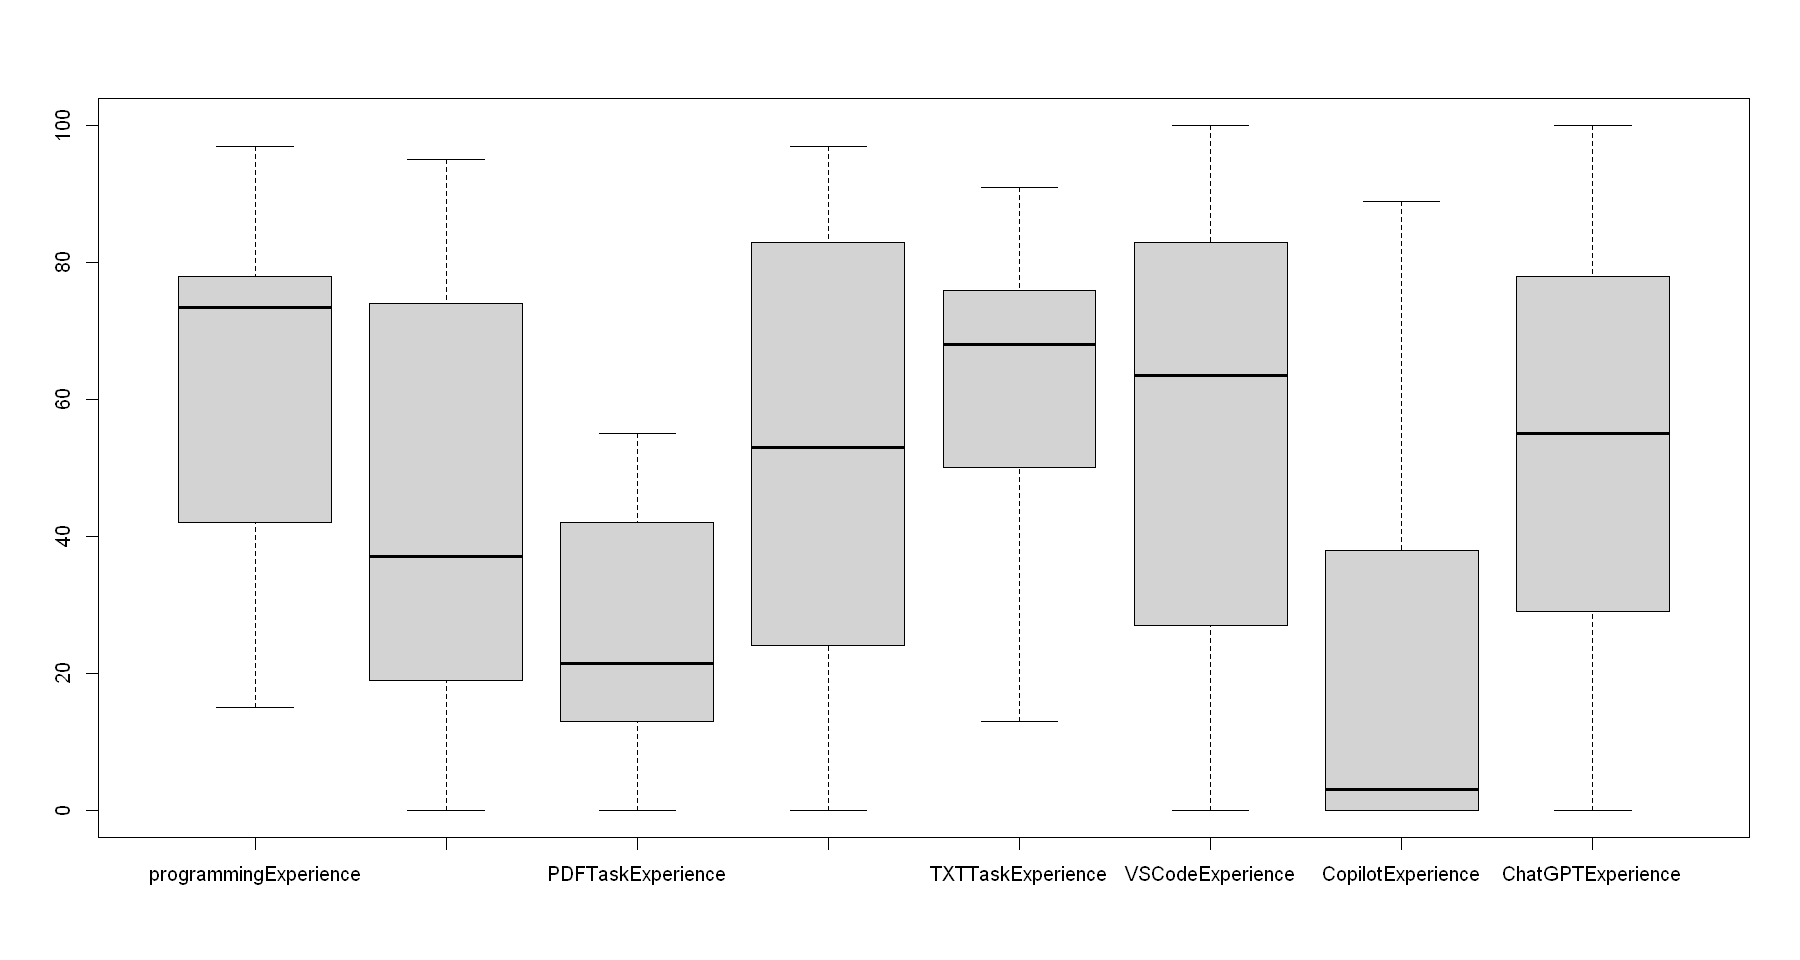

In [ ]:
# Are the outliers a result of the participants' experience with the tools?

experience.cols <- c(
  'programmingExperience',
  'pythonExperience',
  'PDFTaskExperience',
  'CSVTaskExperience',
  'TXTTaskExperience',
  'VSCodeExperience',
  'CopilotExperience',
  'ChatGPTExperience'
)

boxplot(df.surveys.outliers[experience.cols], ylim = c(0, 100))
boxplot(df.surveys.majority[experience.cols], ylim = c(0, 100))

# Is either of the group on average different than the other?
for (col in experience.cols) {
  print(col)
  swt <- shapiro.test(rbind(df.surveys.outliers[,col], df.surveys.majority[,col]))
  if (swt$p <= 0.05) {
    print(wilcox.test(df.surveys.outliers[,col], df.surveys.majority[,col]))
  } else {
    print(t.test(df.surveys.outliers[,col], df.surveys.majority[,col]))
  }
}

In [ ]:
combined.surveys.conditions <- merge(df.outliers, df.surveys, by.x = 'pid', by.y = 'participantID') 


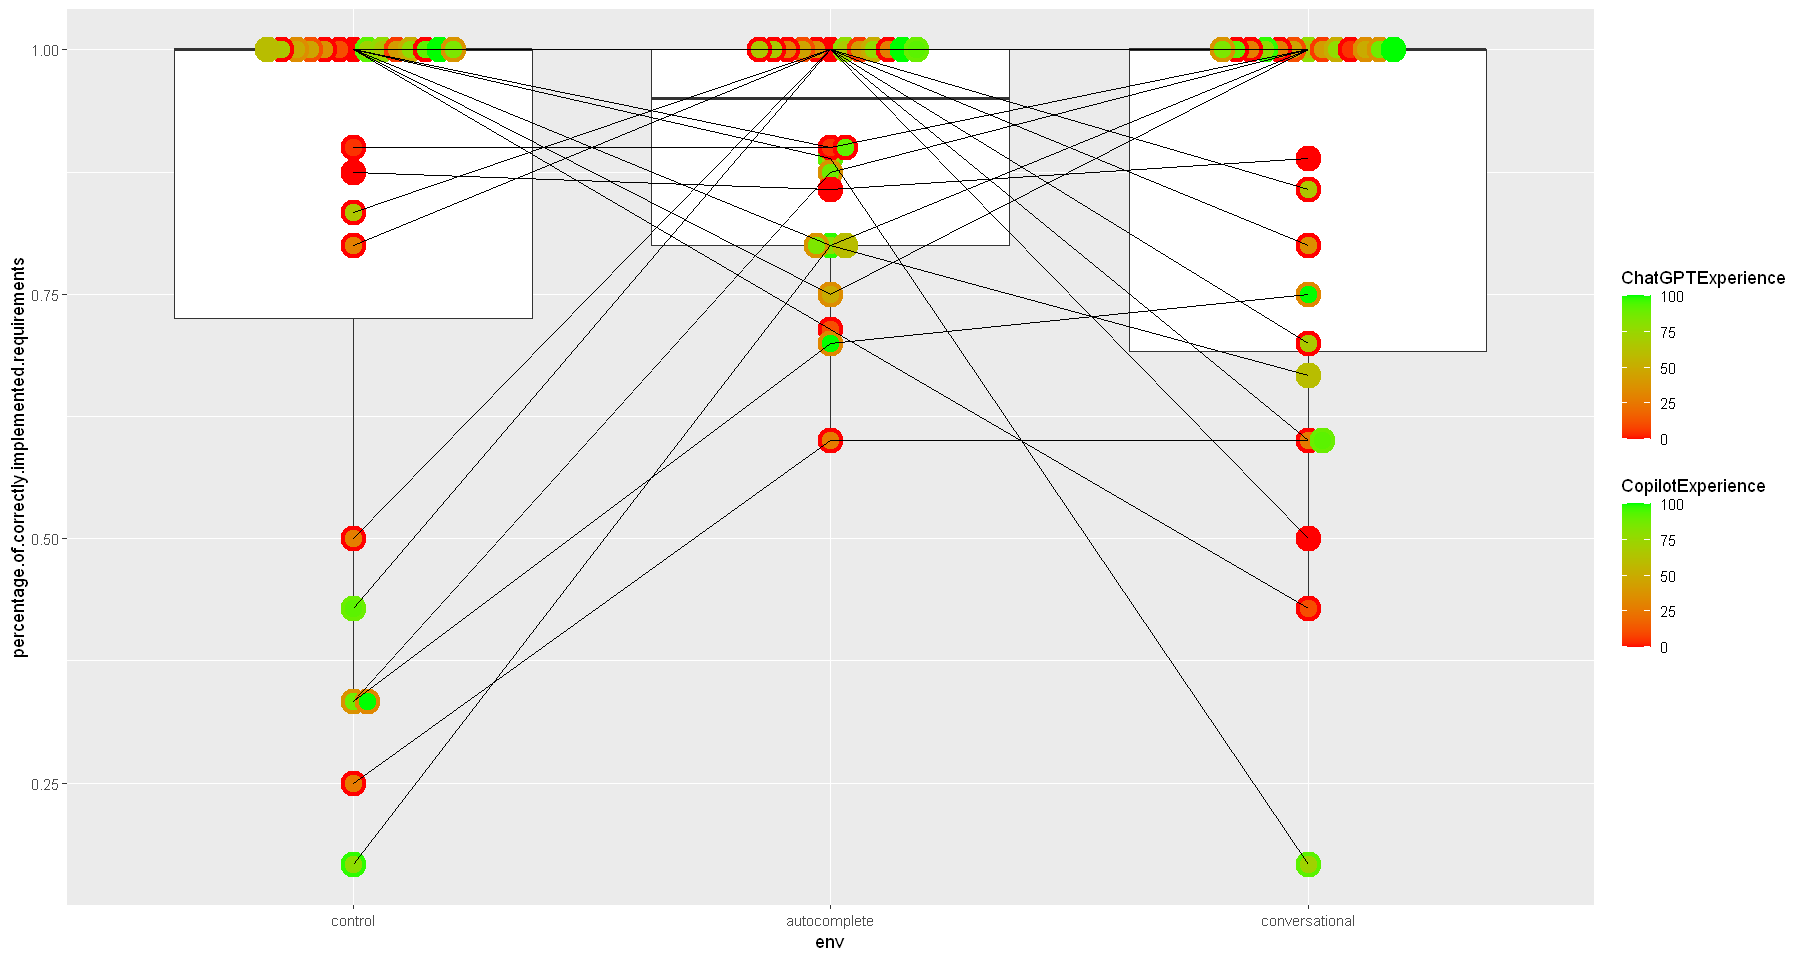

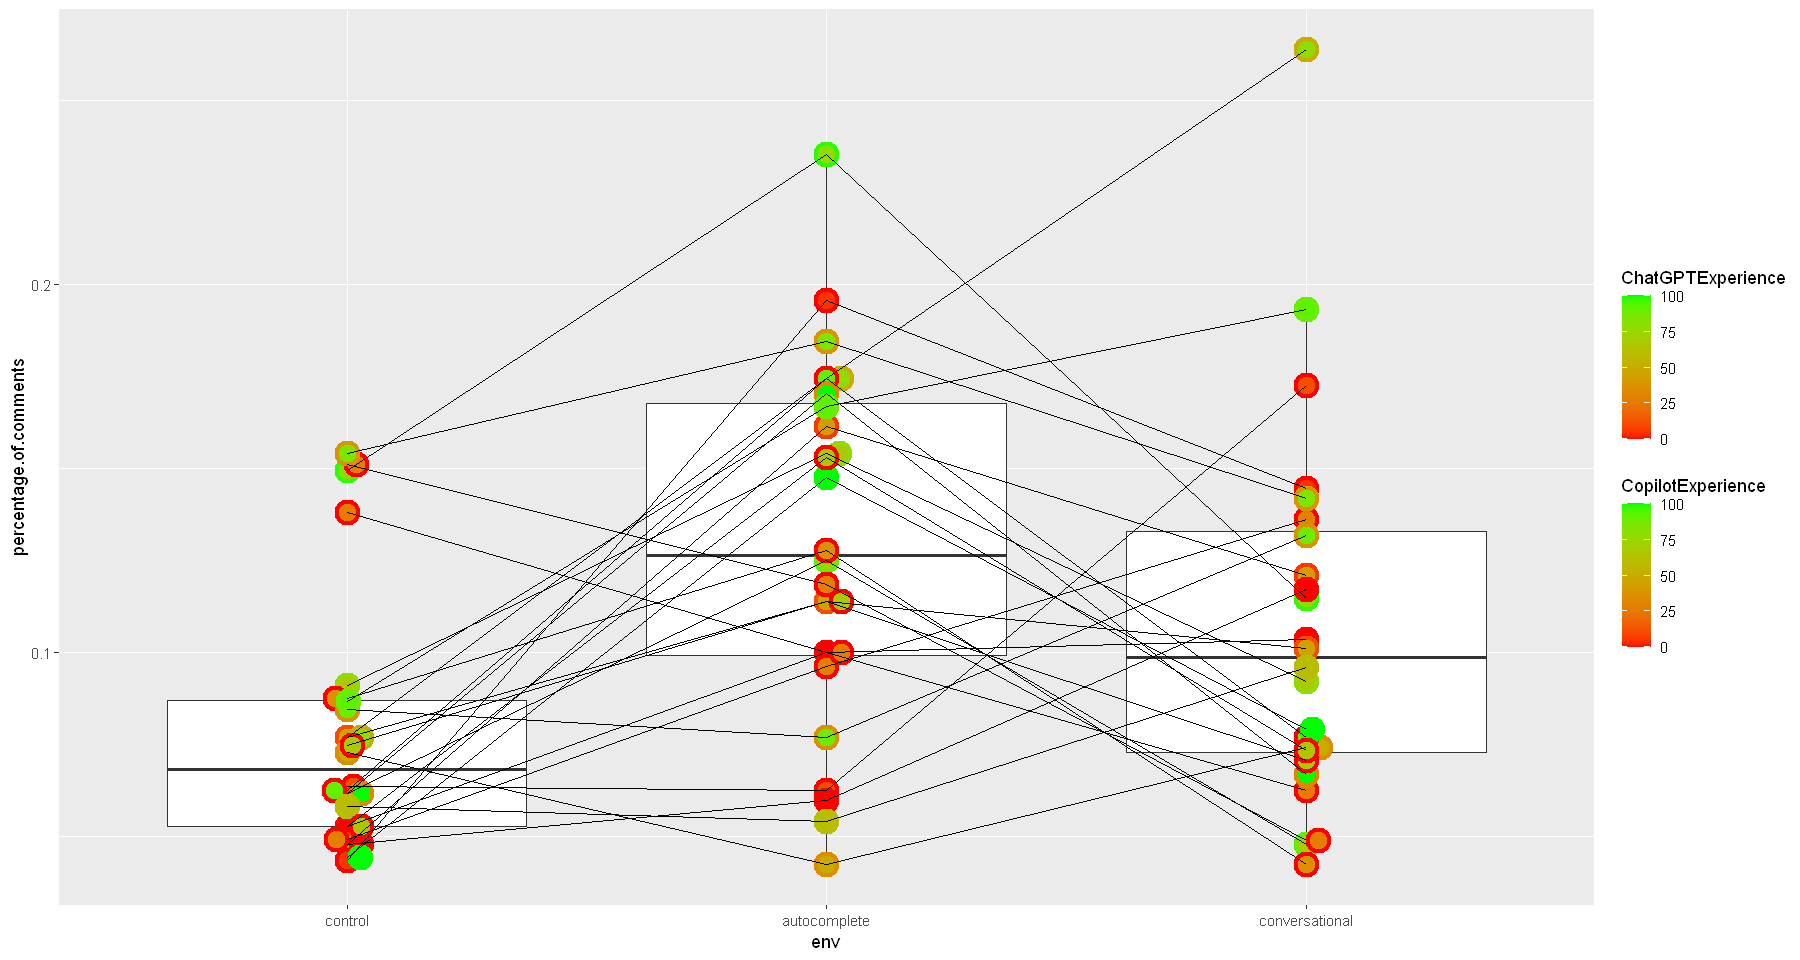

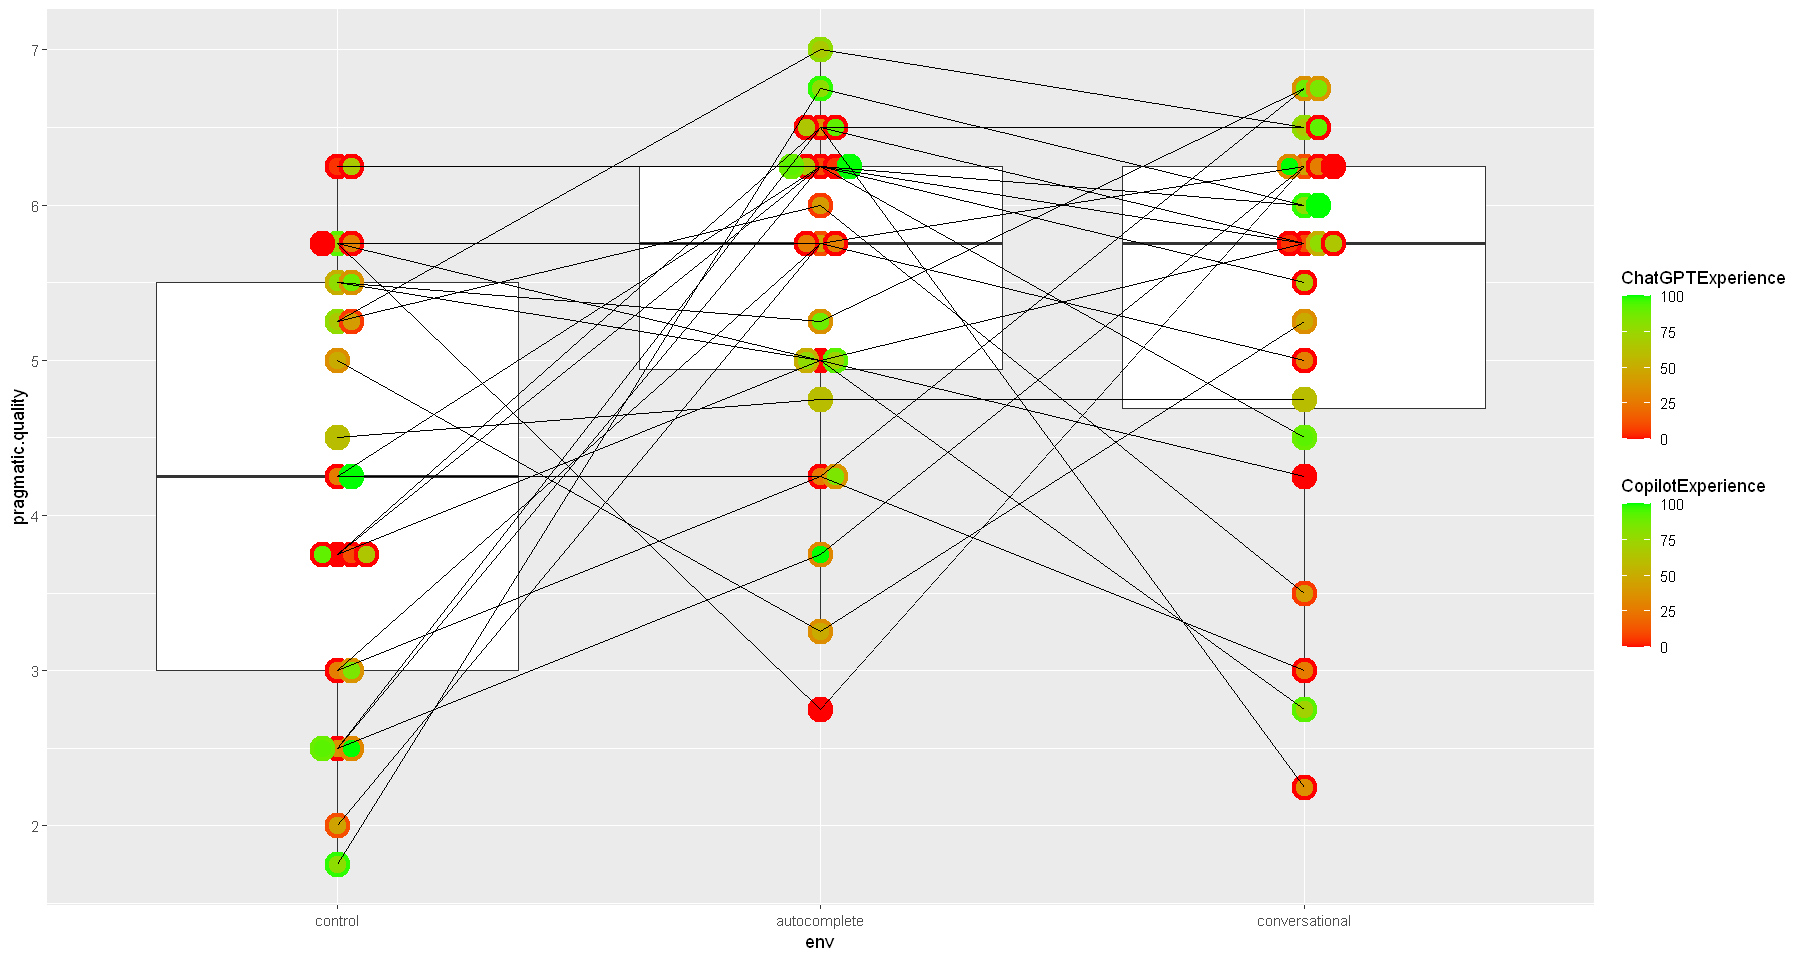

Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.


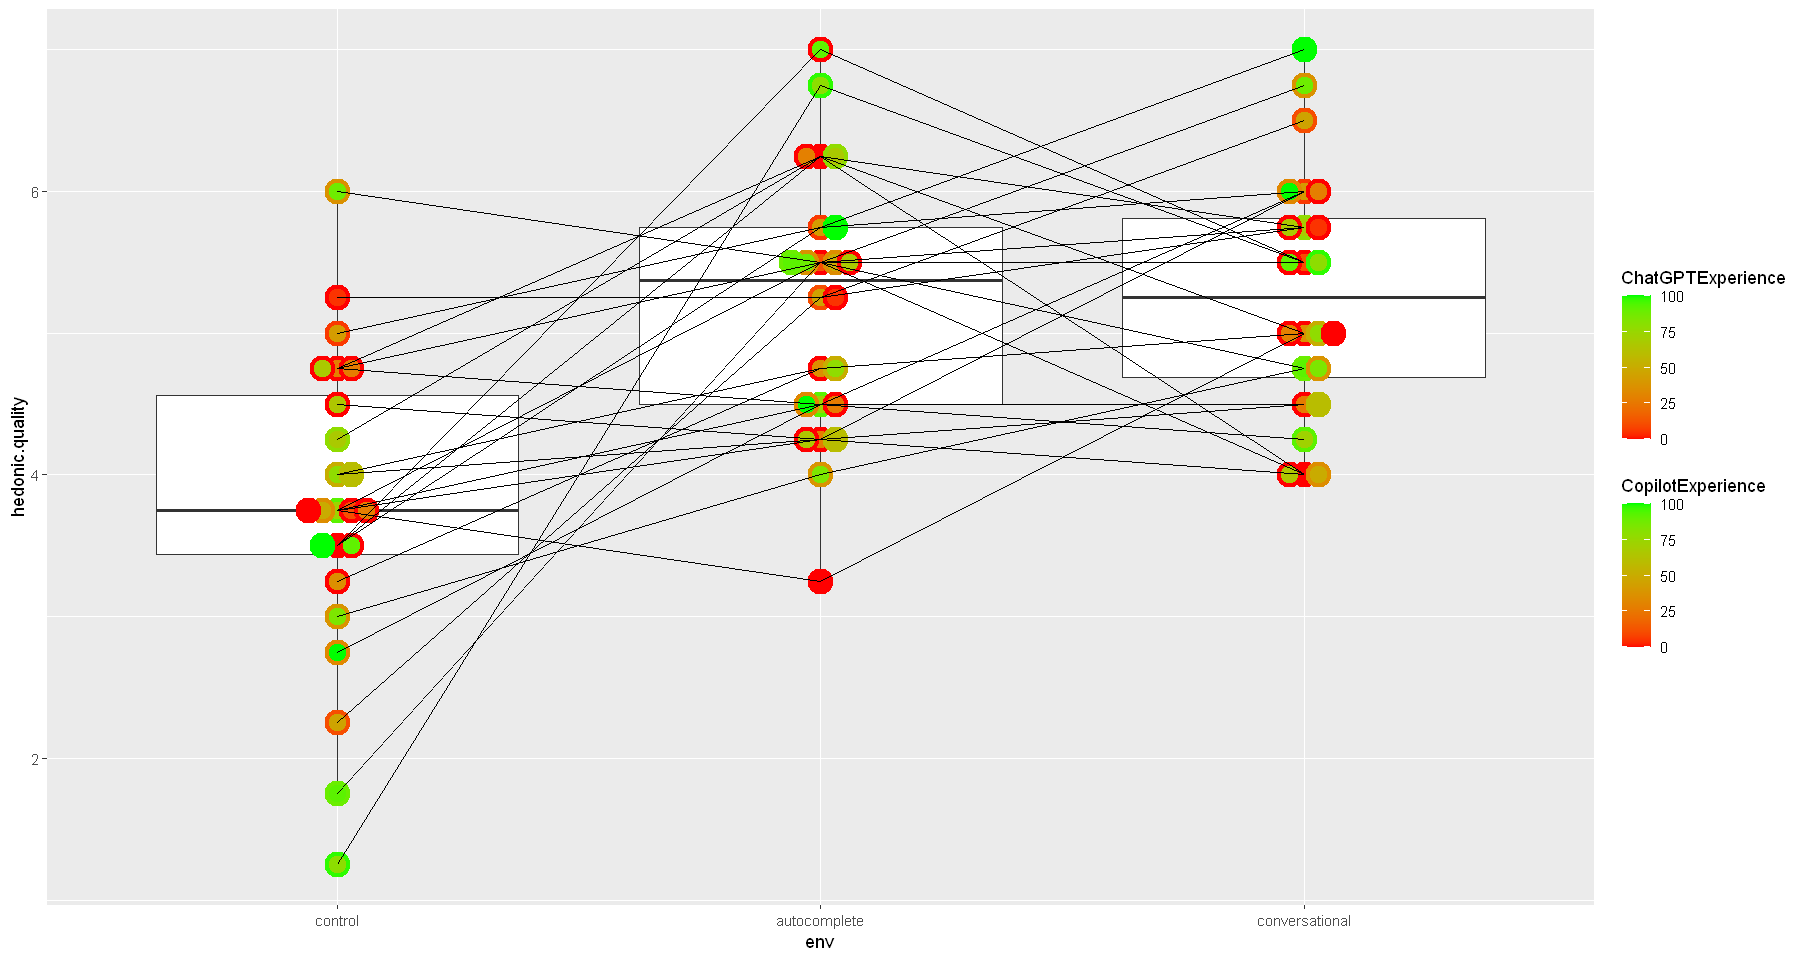

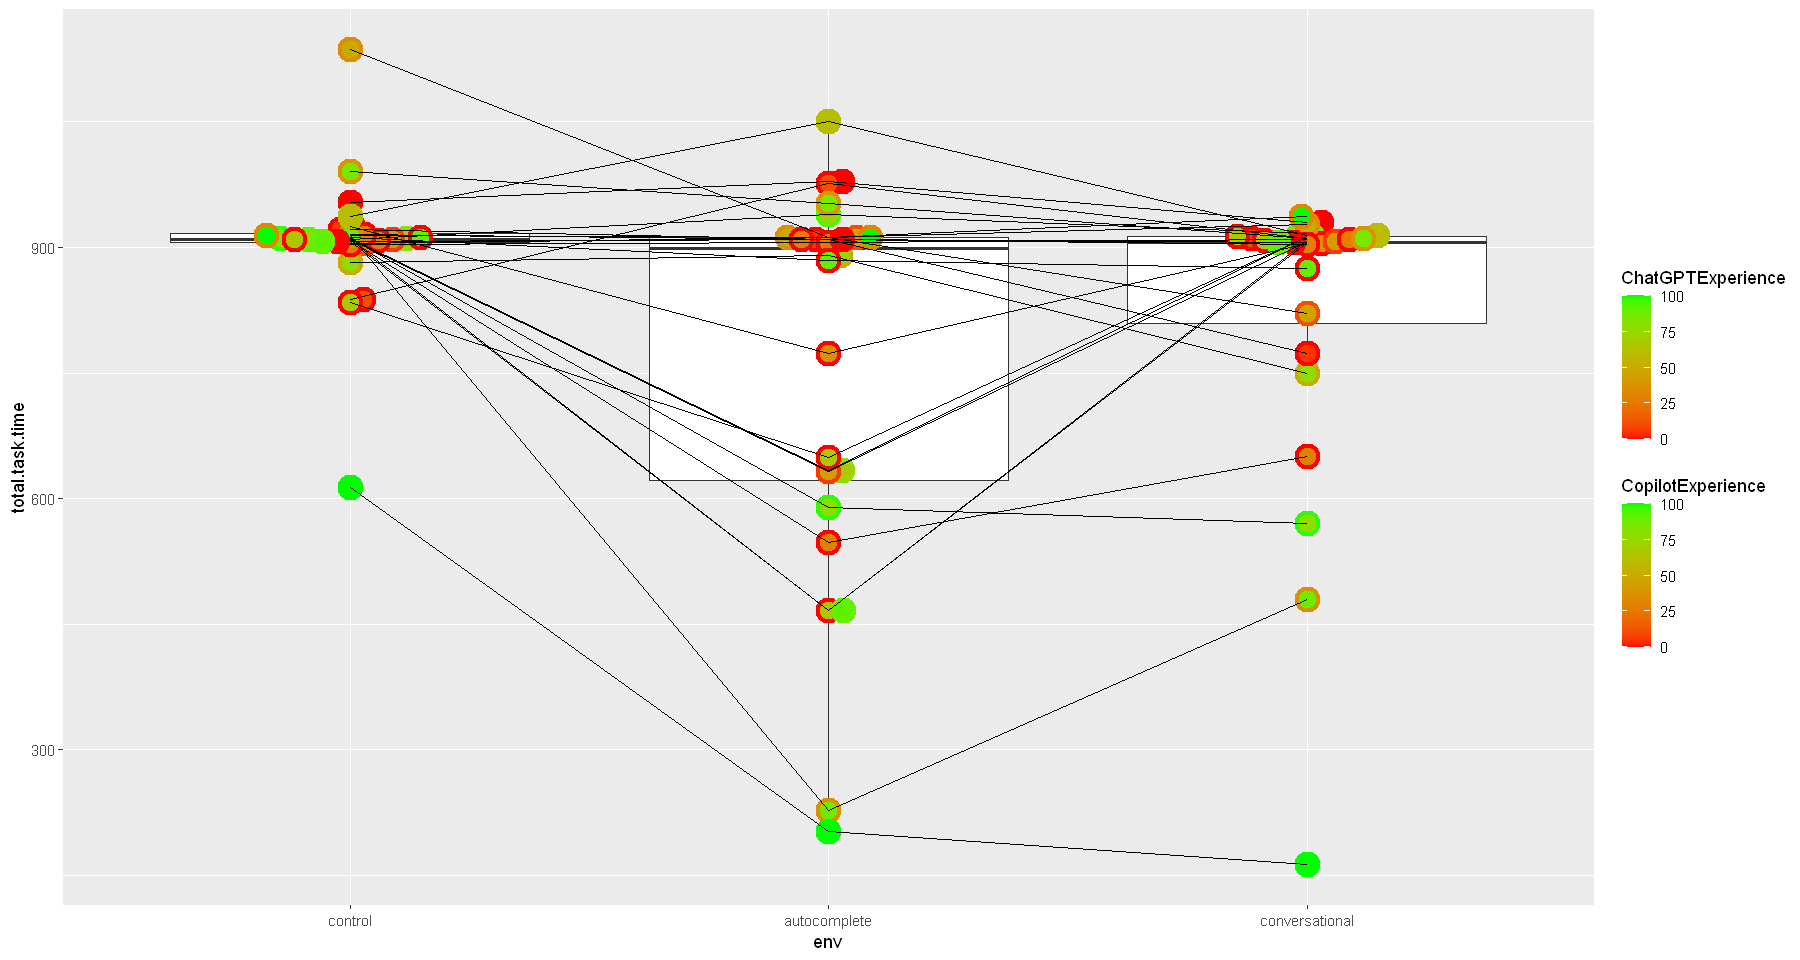

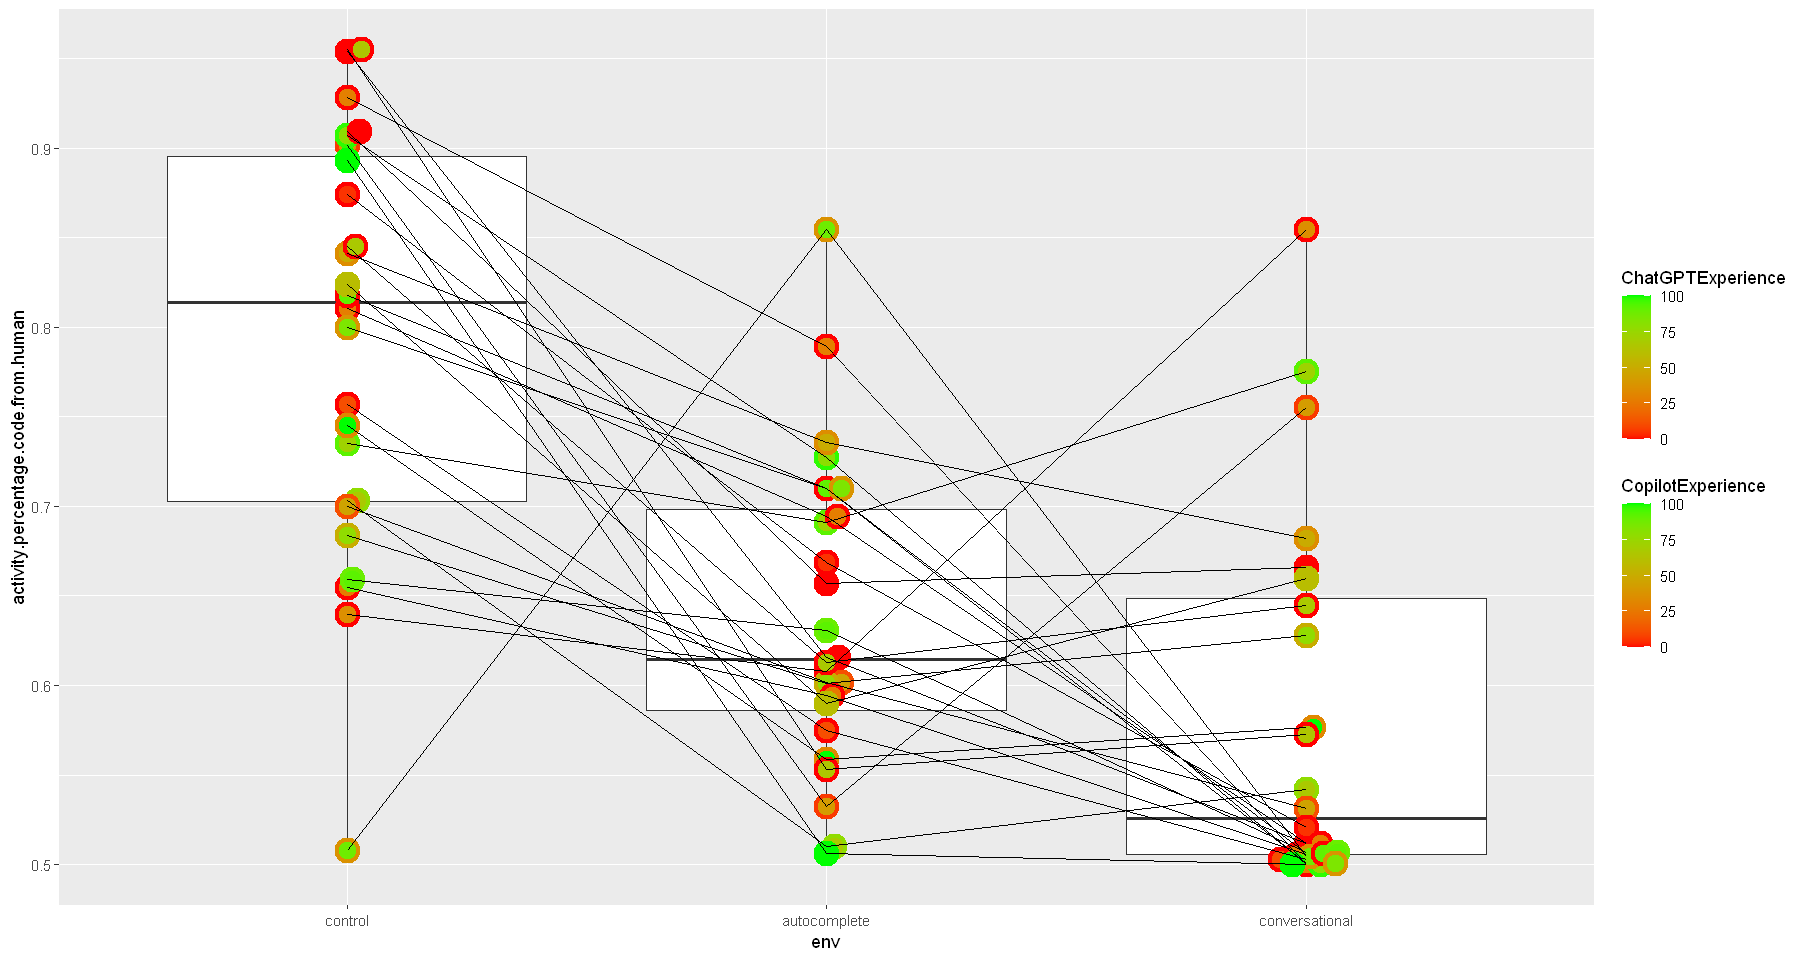

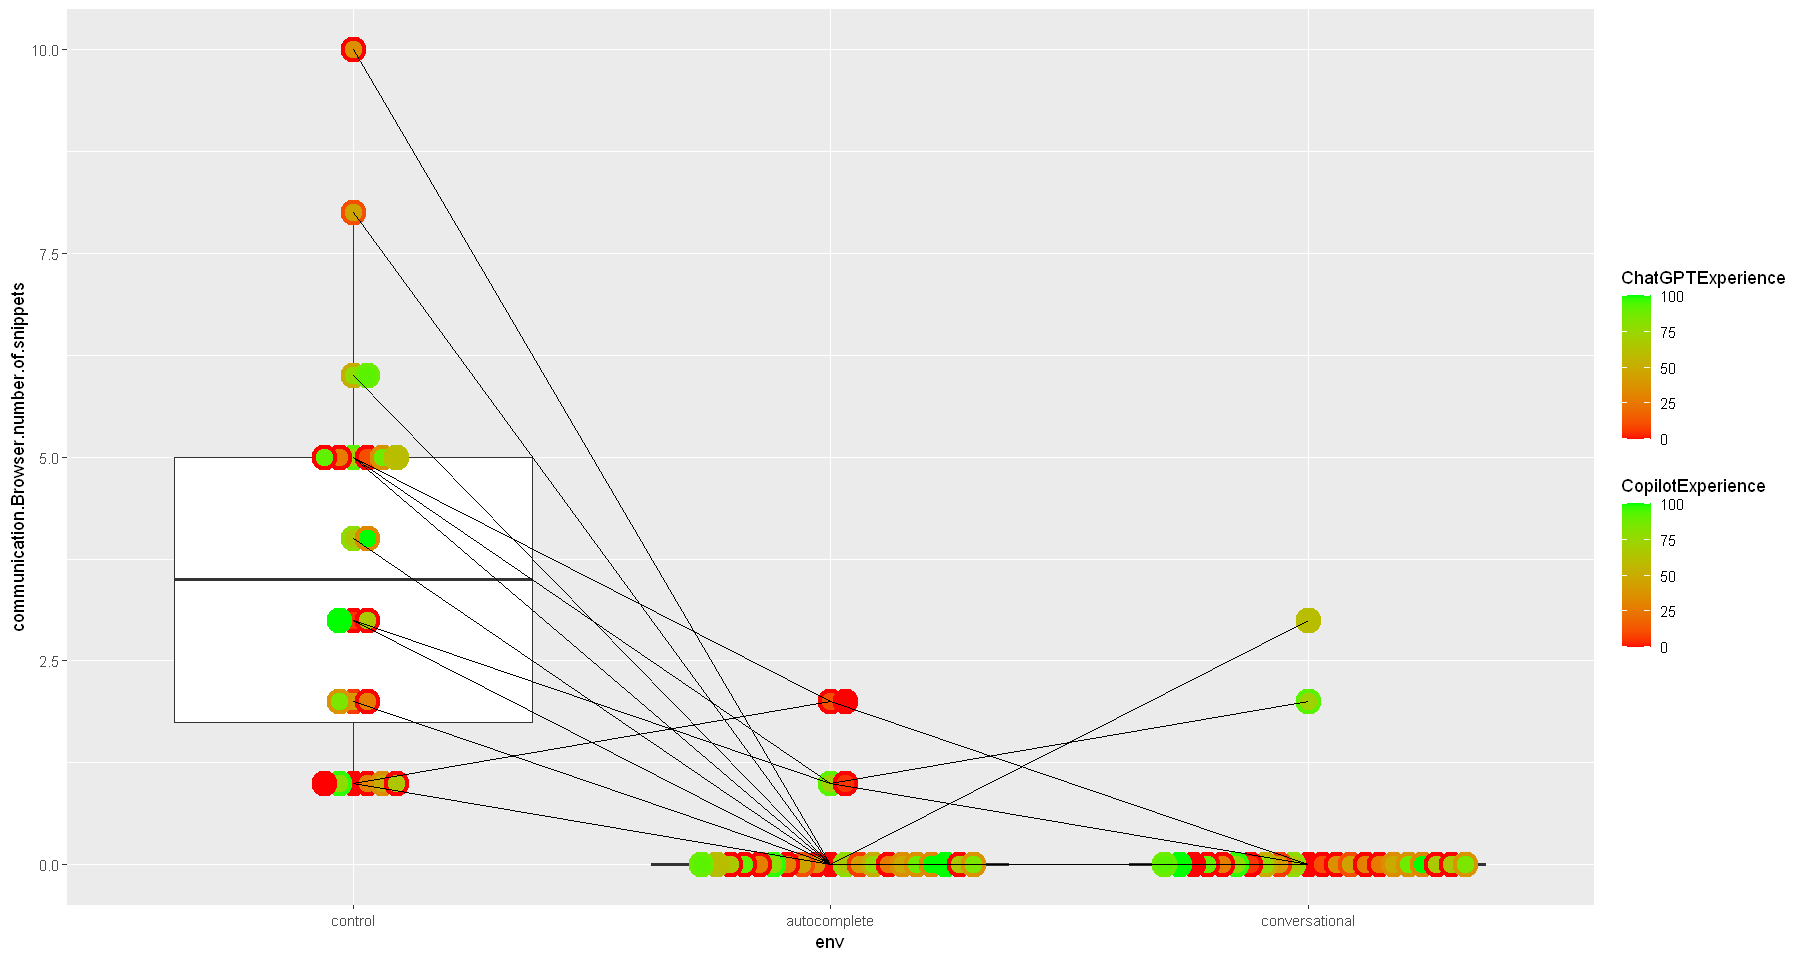

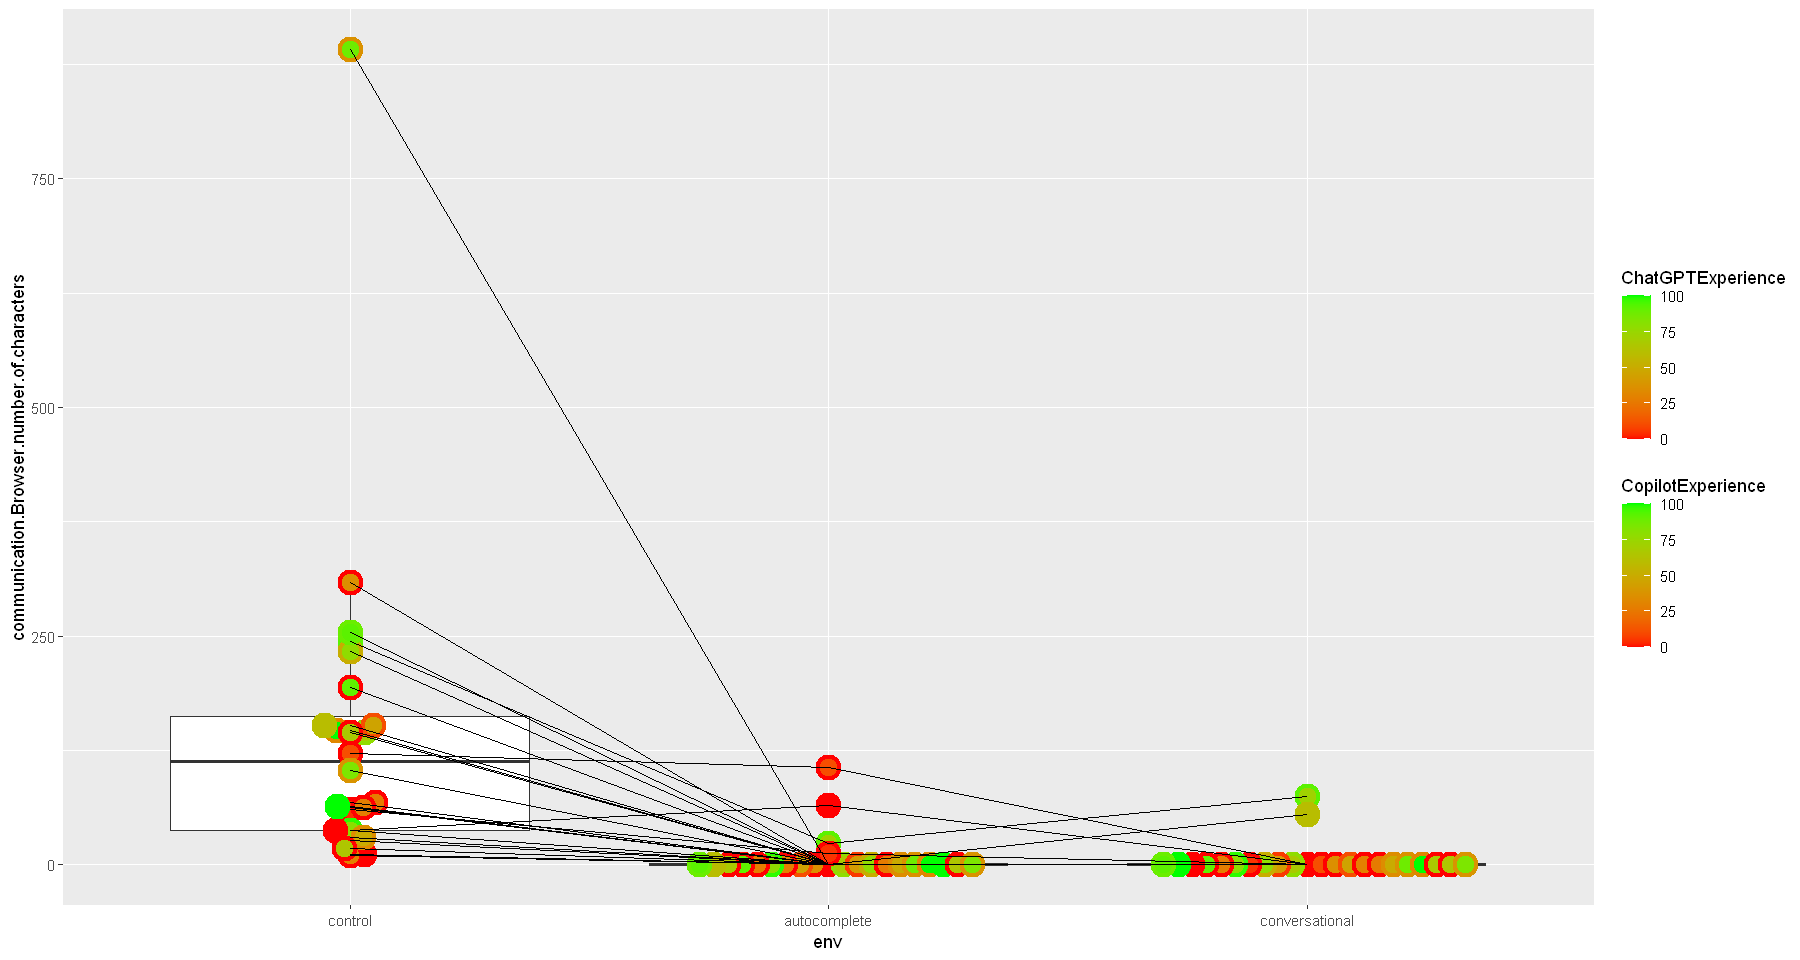

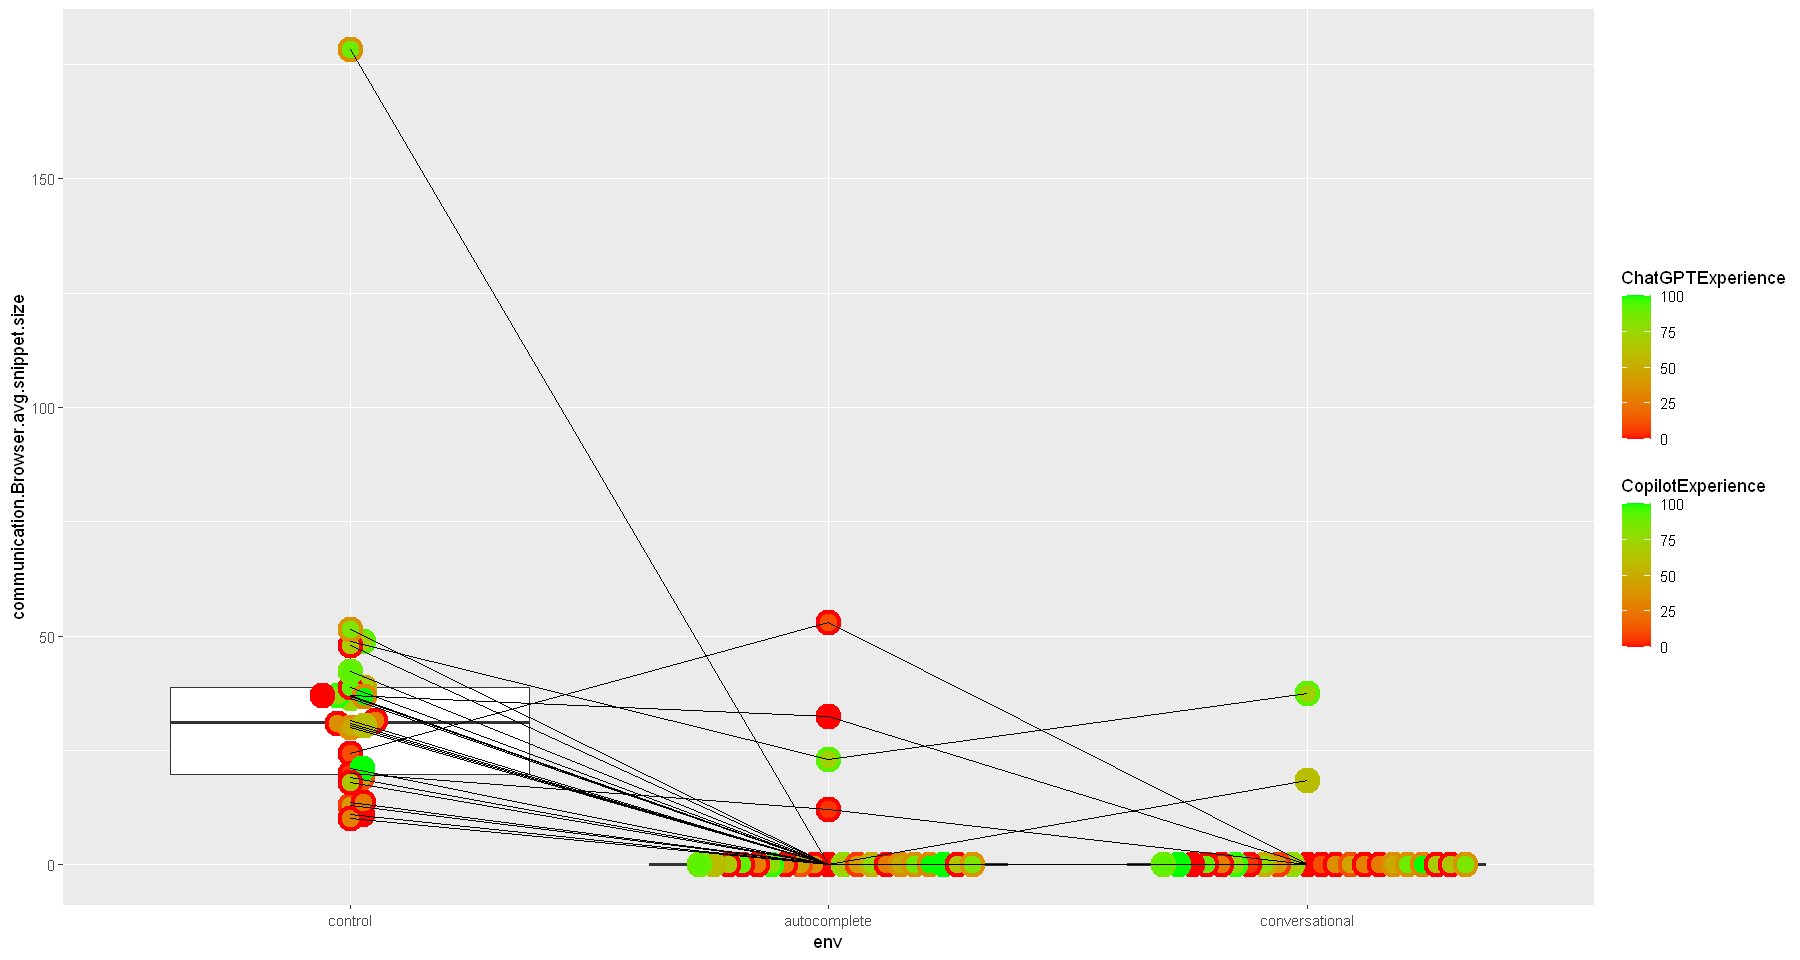

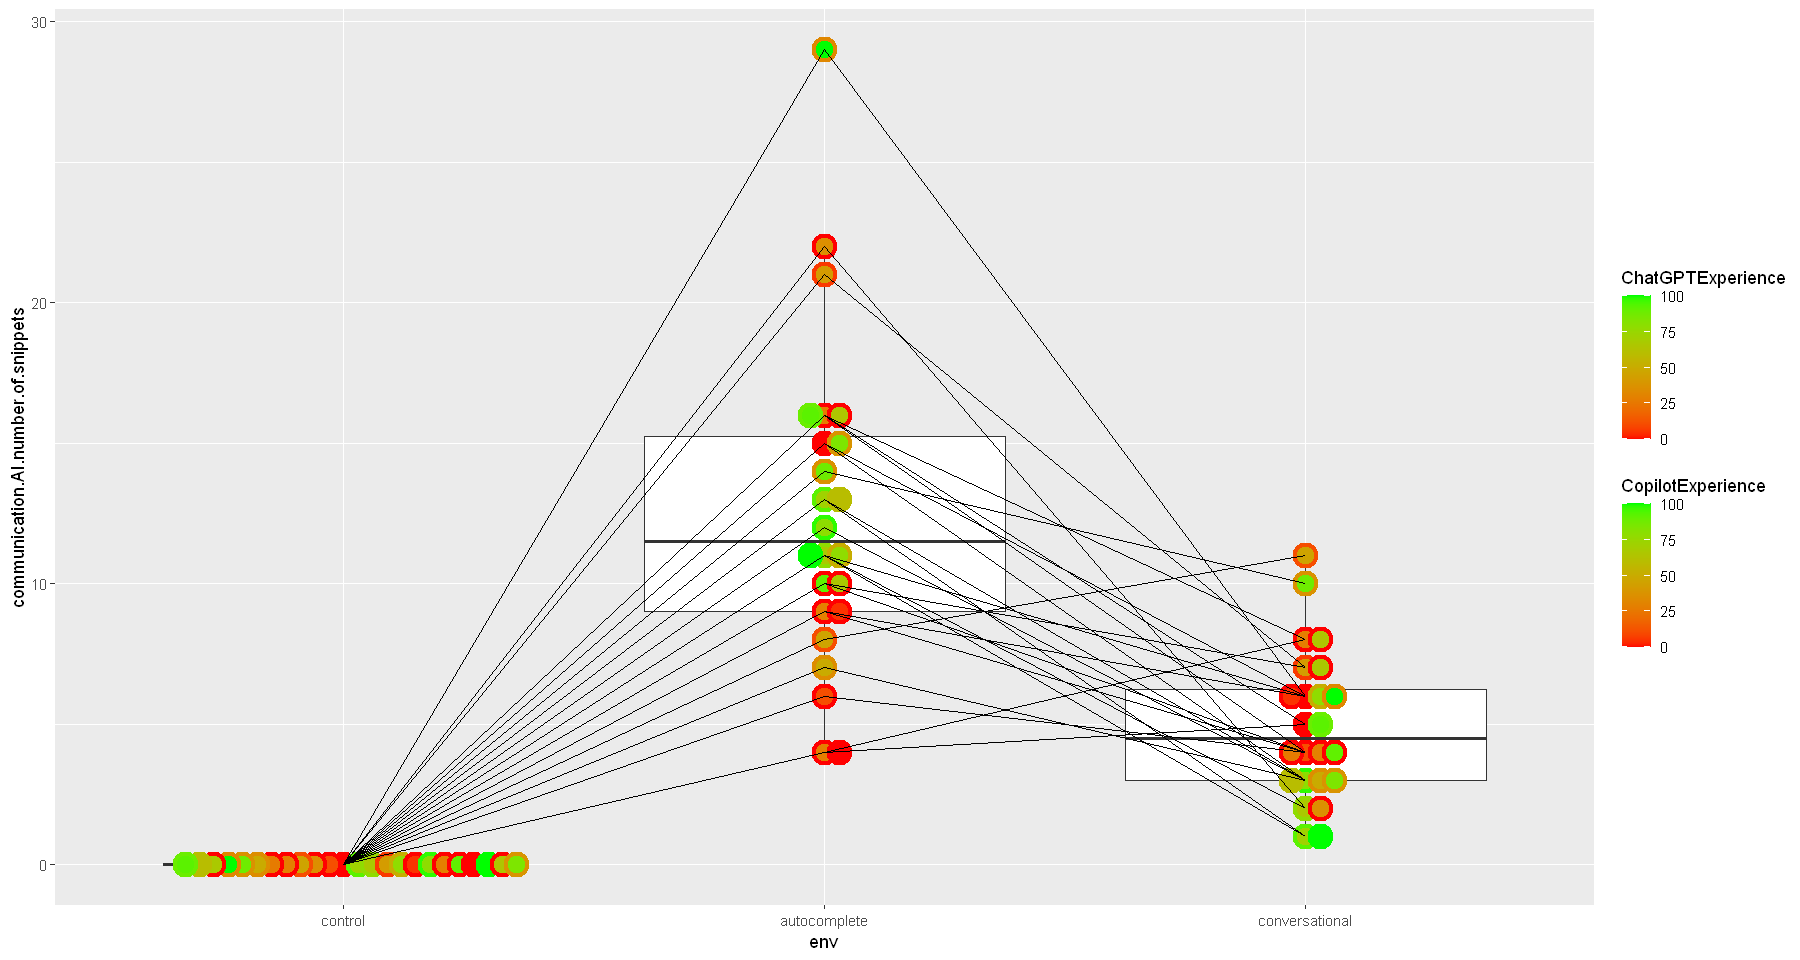

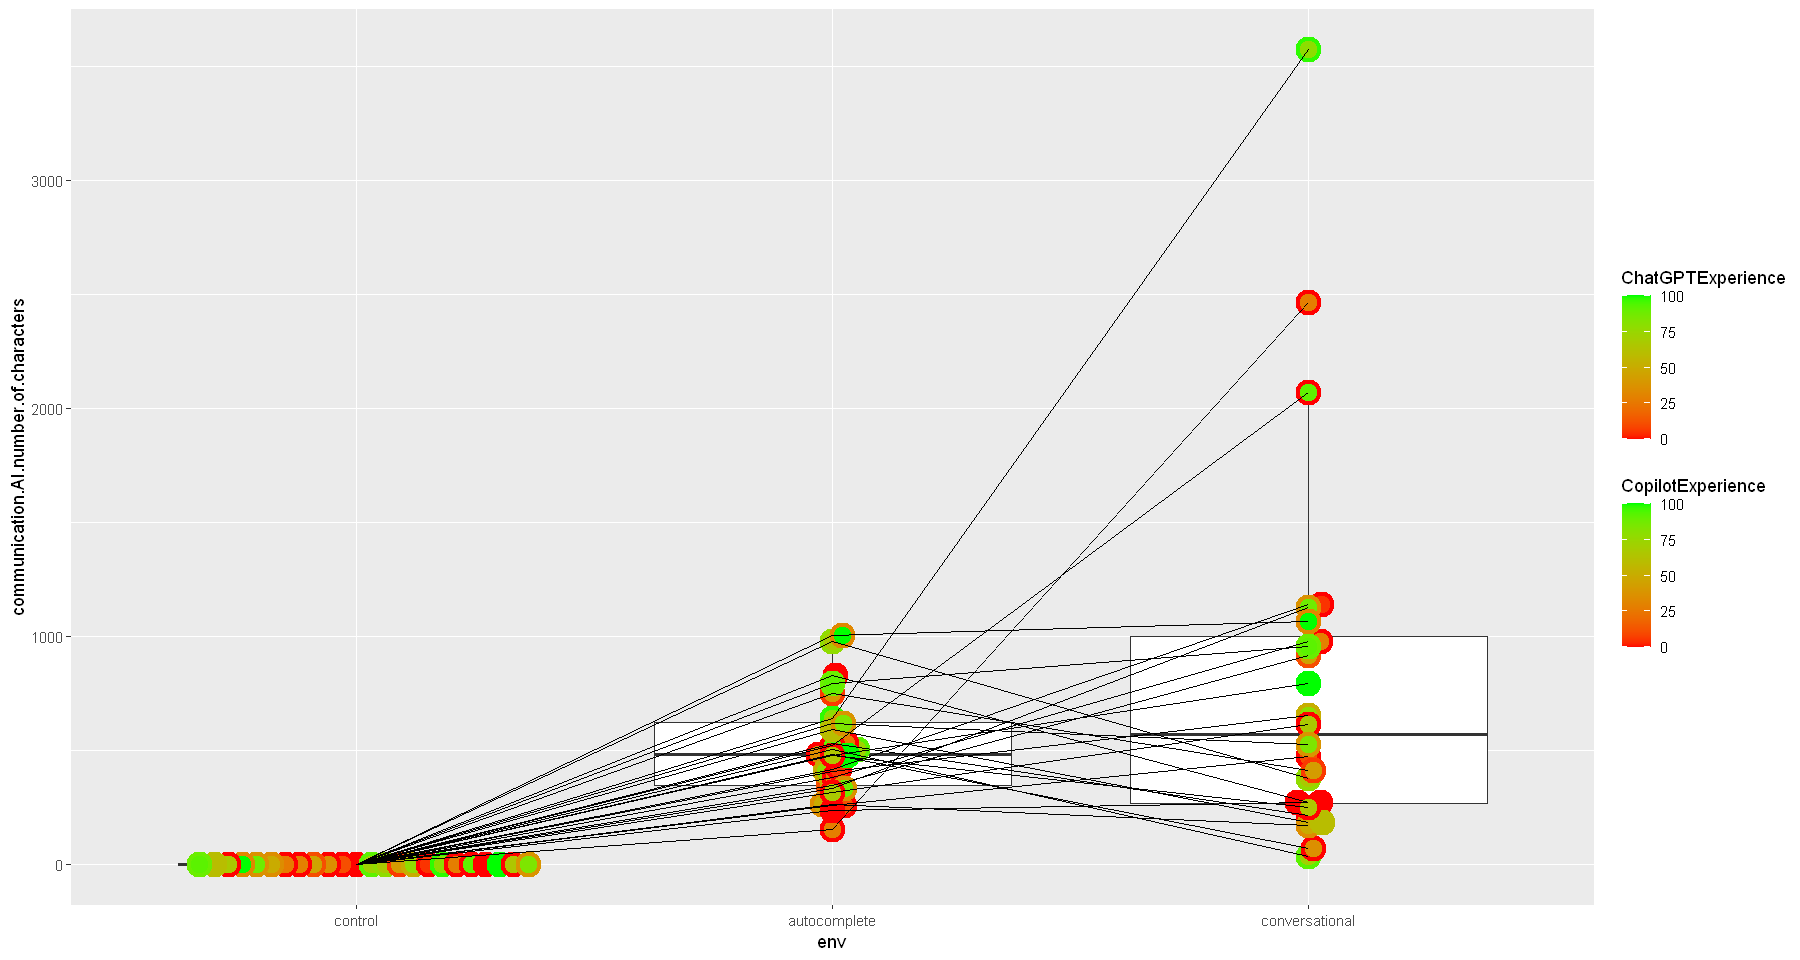

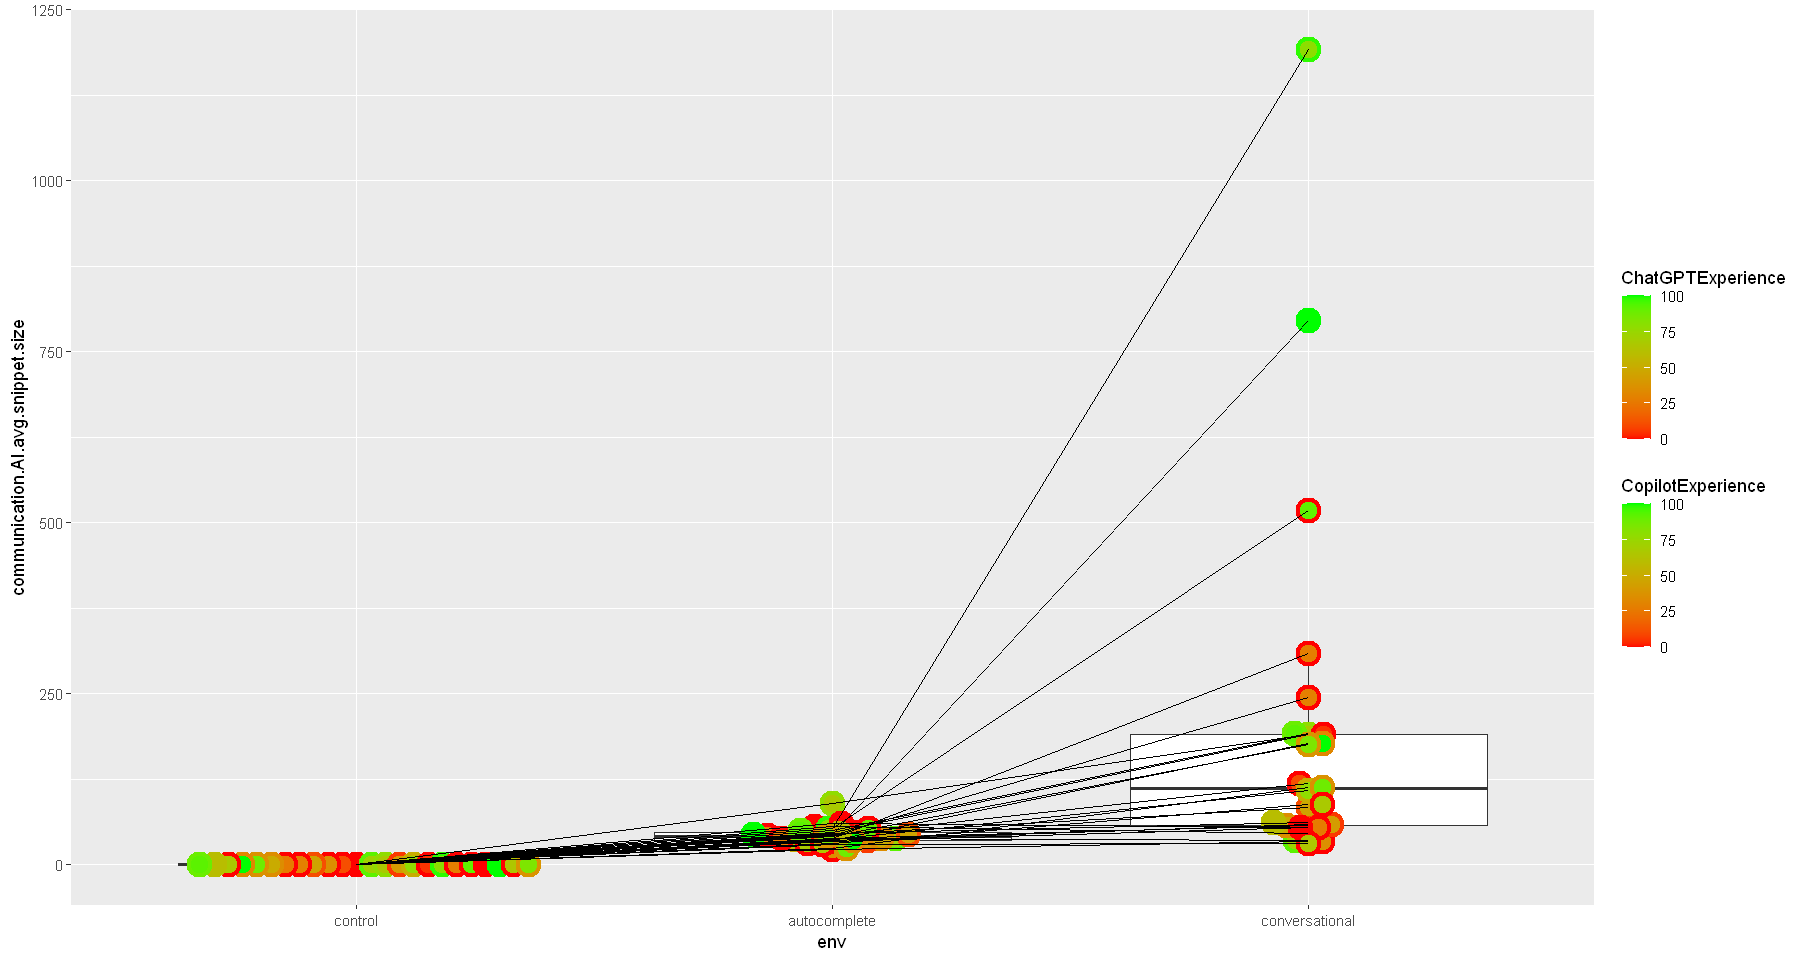

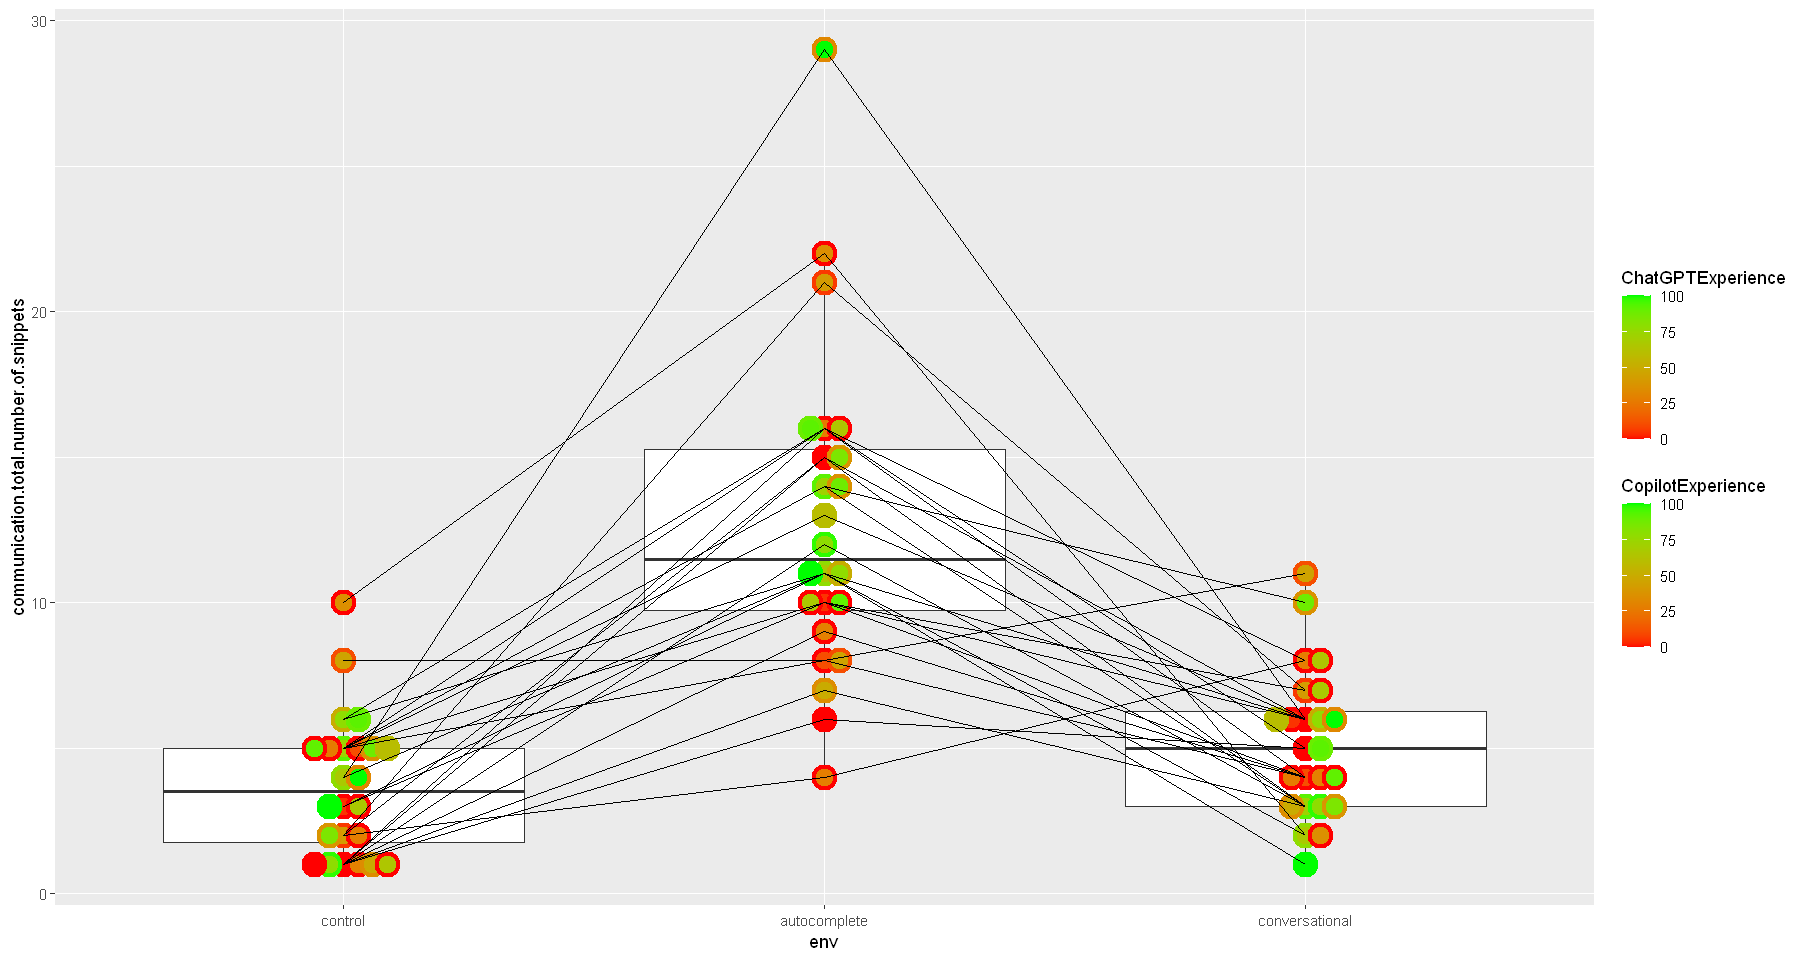

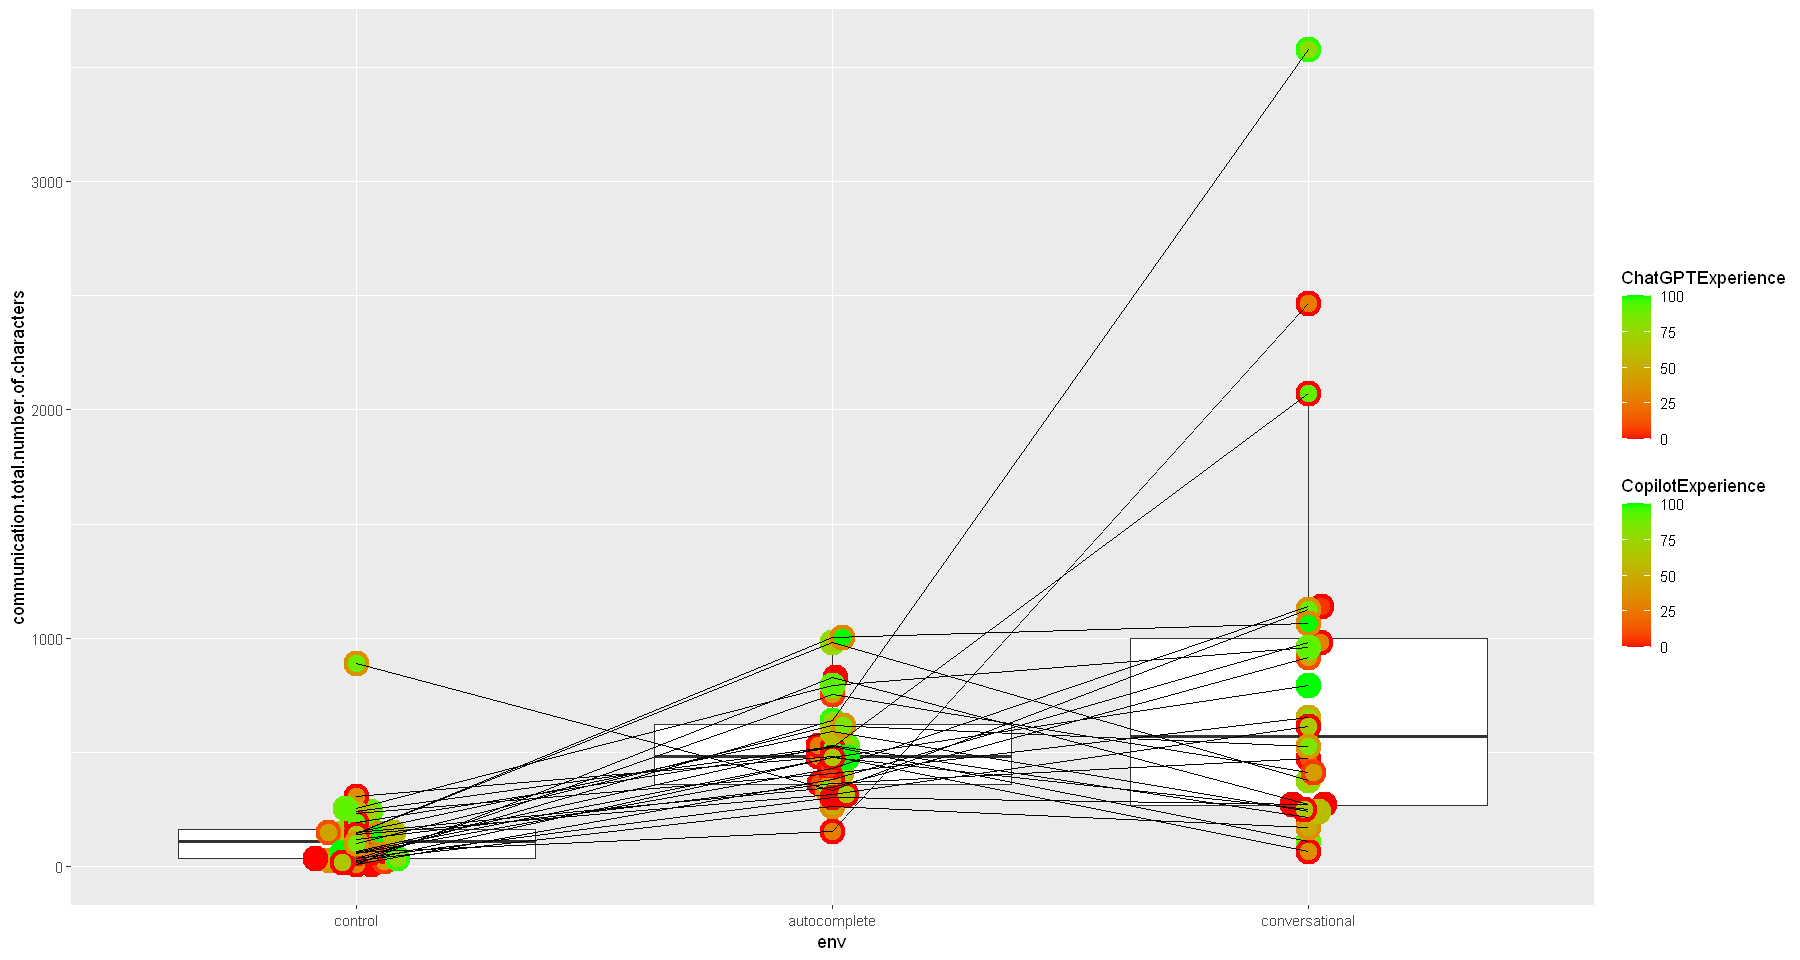

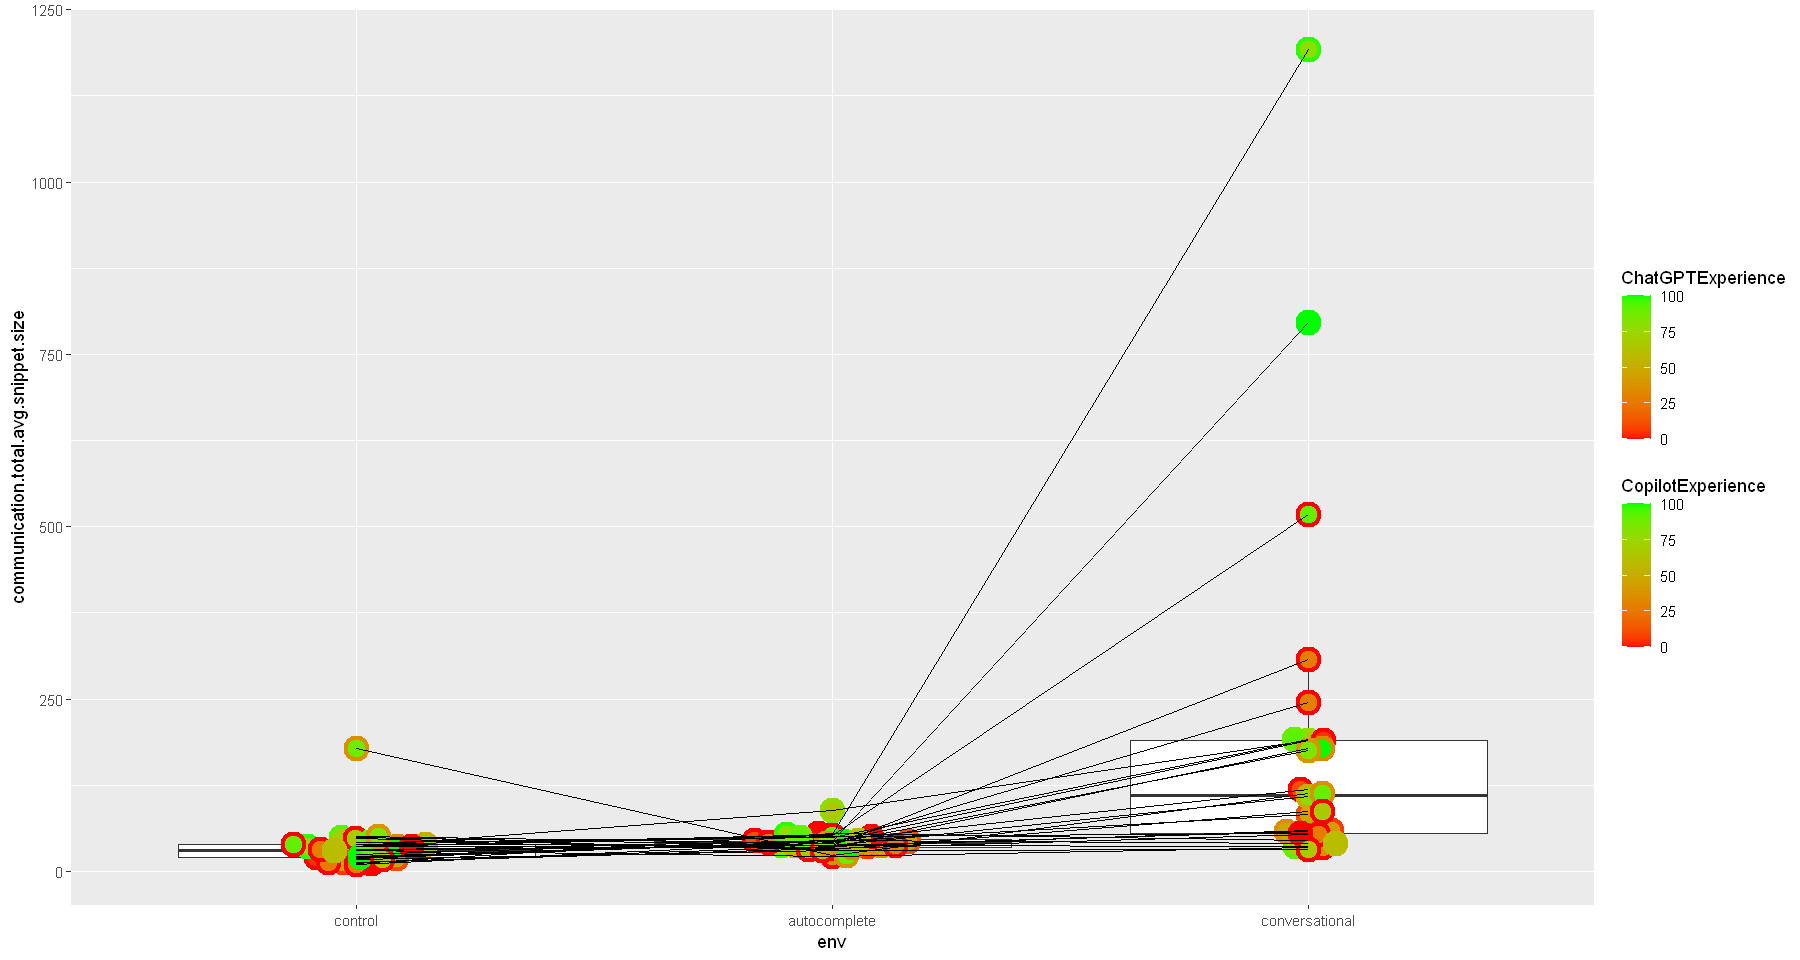

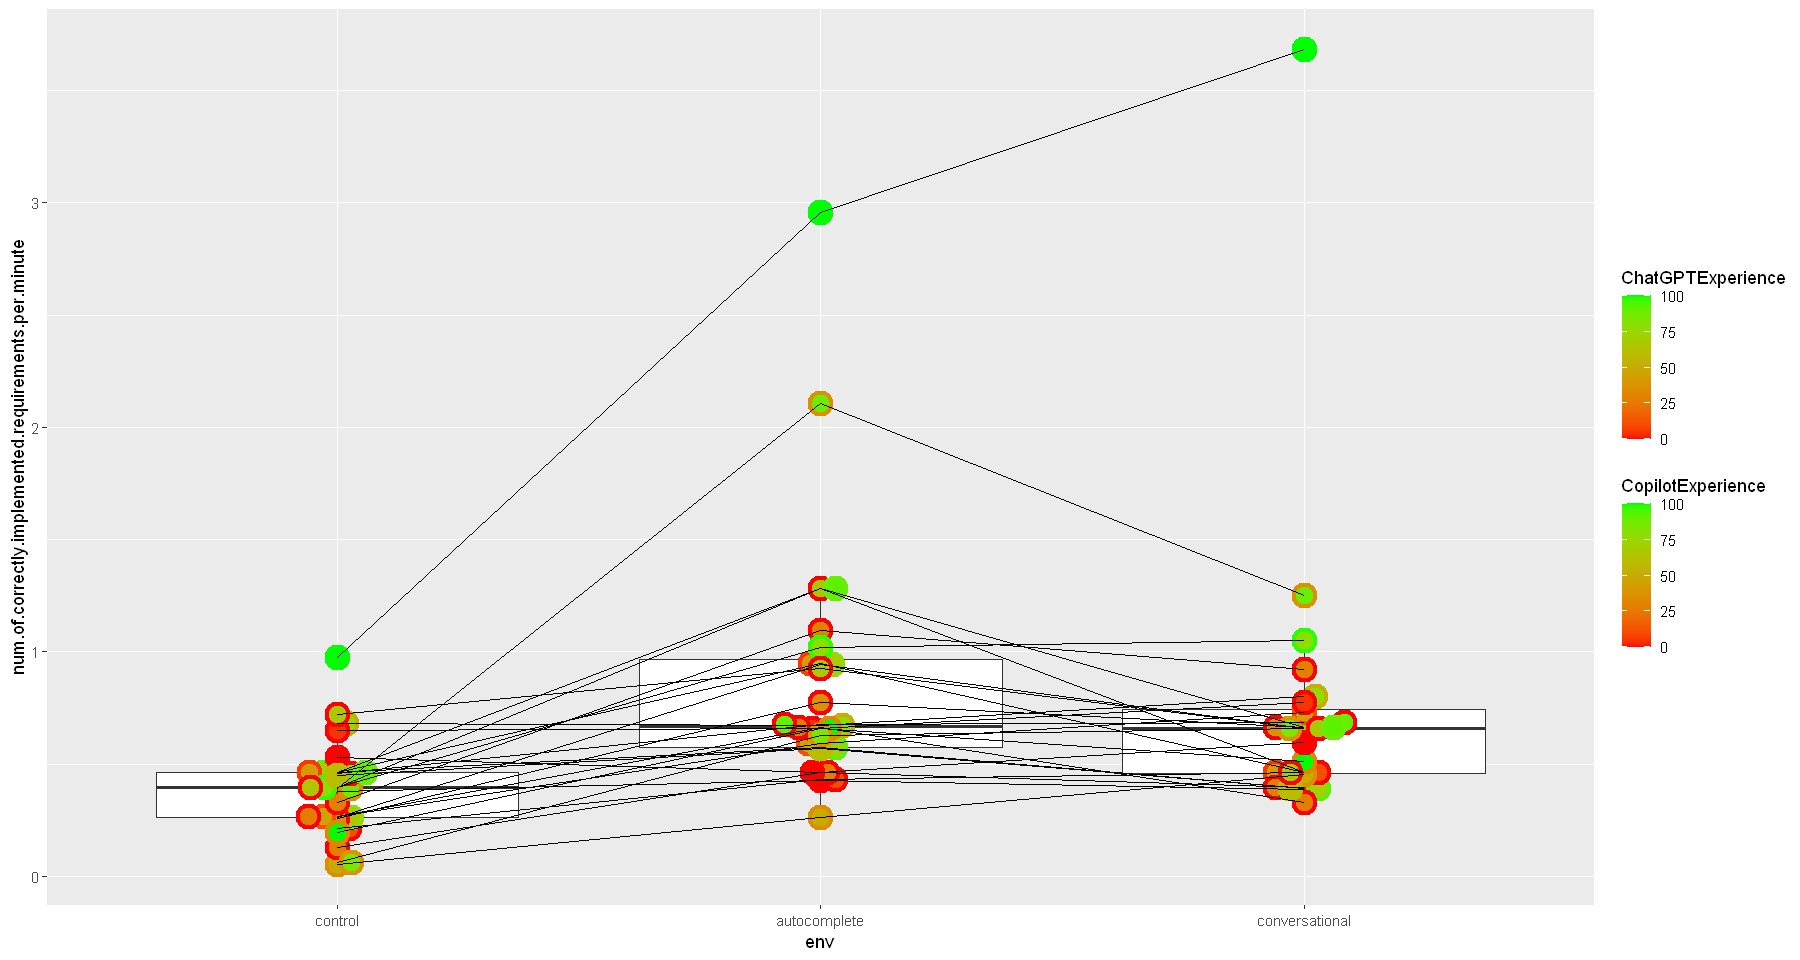

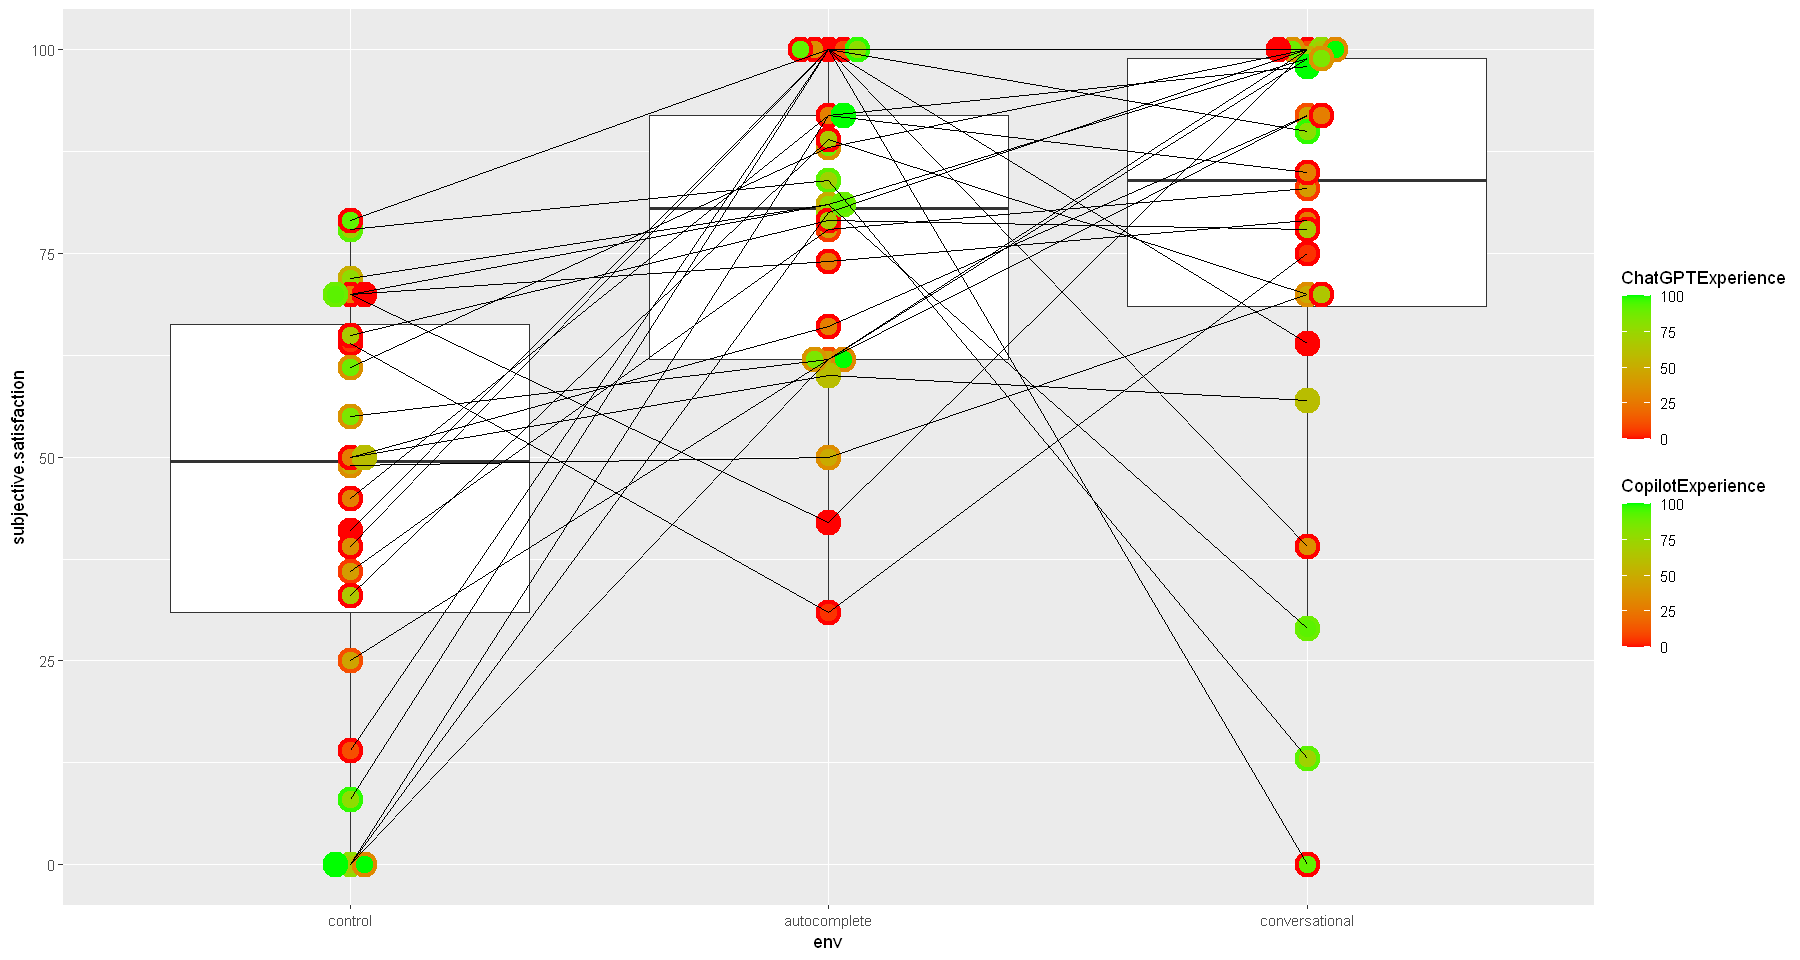

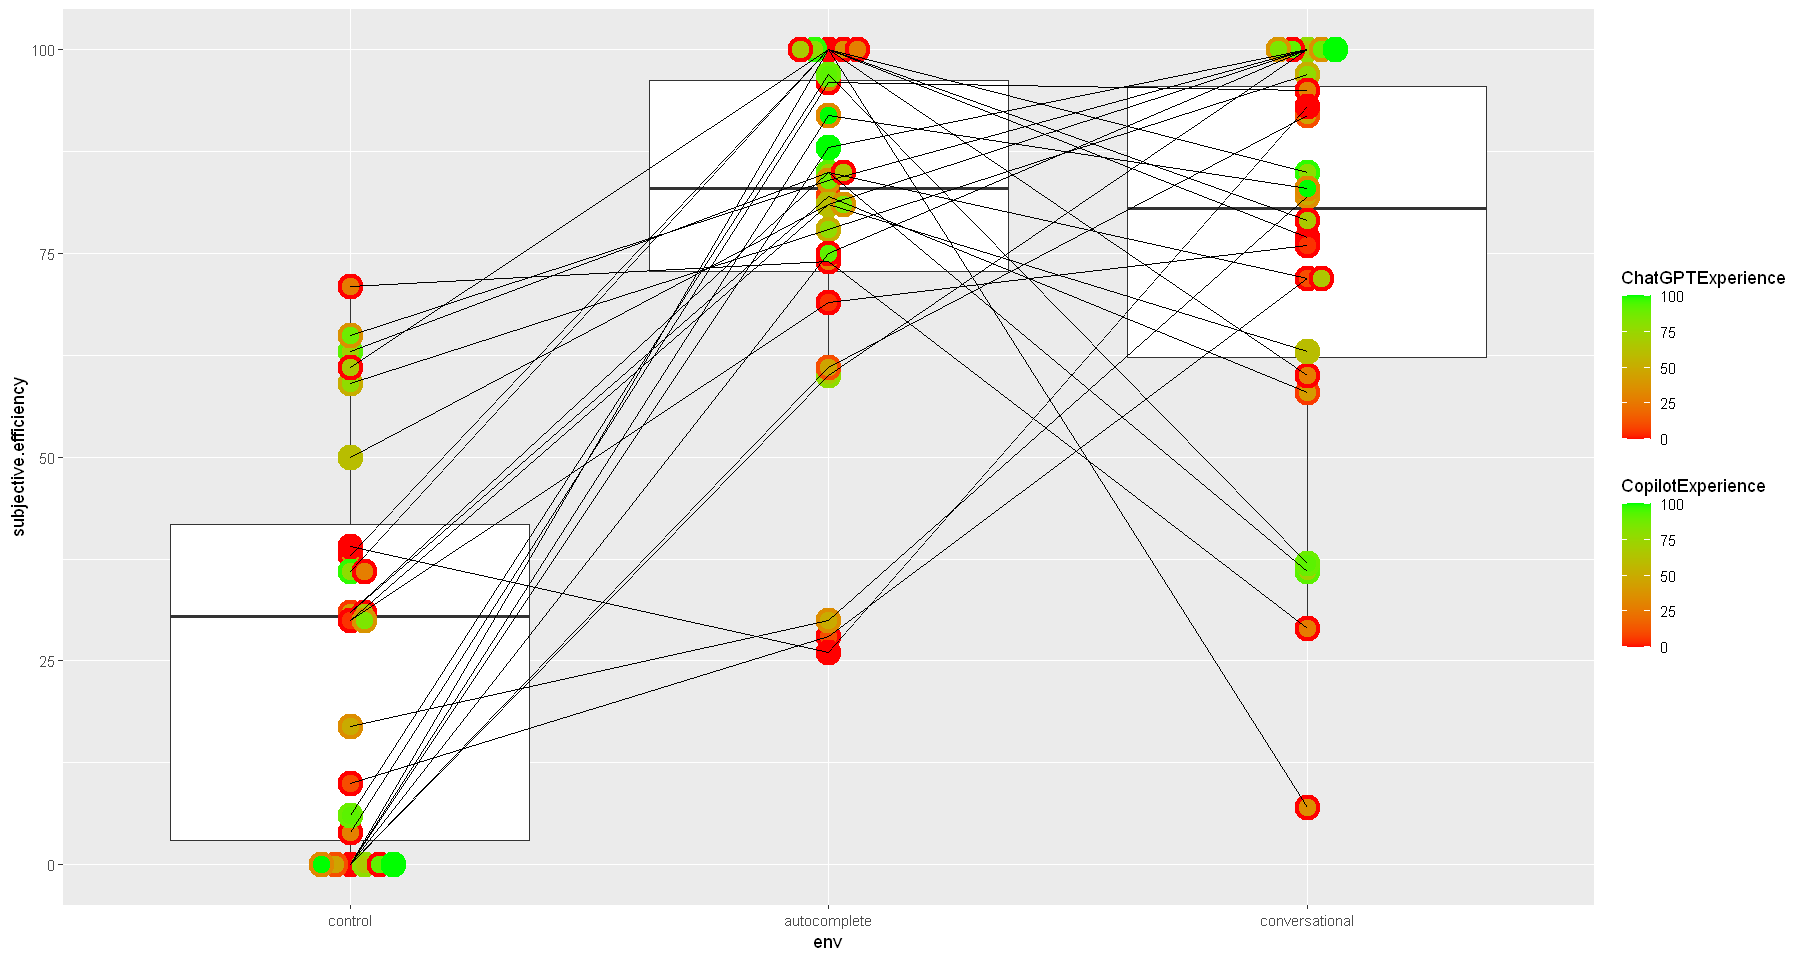

In [ ]:
# Generate plots for the outlier categories to see whether
# - Same participants are consistent with their outliers
# - Prior knowledge of AI tools plays a role in the outliers

outlying.categories <- c(
  'percentage.of.correctly.implemented.requirements',
  'percentage.of.comments',
  'pragmatic.quality',
  'hedonic.quality',
  'total.task.time',
  'activity.percentage.code.from.human',
  'communication.Browser.number.of.snippets',
  'communication.Browser.number.of.characters',
  'communication.Browser.avg.snippet.size',
  'communication.AI.number.of.snippets',
  'communication.AI.number.of.characters',
  'communication.AI.avg.snippet.size',
  'communication.total.number.of.snippets',
  'communication.total.number.of.characters',
  'communication.total.avg.snippet.size',
  'num.of.correctly.implemented.requirements.per.minute',
  'subjective.satisfaction',
  'subjective.efficiency'
)

options(repr.plot.width=15, repr.plot.height=8)

combined.surveys.conditions$env <- factor(combined.surveys.conditions$env, level=c('control', 'autocomplete', 'conversational'))

for (col in outlying.categories) {
  print(ggplot(combined.surveys.conditions, aes_string(x = 'env', y = col)) + 
    geom_boxplot() +
    geom_beeswarm(aes(fill = ChatGPTExperience, color = CopilotExperience), shape=21, stroke=2, size=5) +
    scale_colour_gradient(low='#ff0000', high='#00ff00') + 
    scale_fill_gradient(low='#ff0000', high='#00ff00') + 
    geom_line(aes(x=env, group=pid)))
}

In [ ]:
# List each outlier with its category, environment and value

tmp <- combined.surveys.conditions[c('pid', 'env', outlying.categories)]

for (col in names(tmp)) {
  if (col != 'env' && col != 'pid') {
    for (env in c('control', 'autocomplete', 'conversational')) {

      iqr <- IQR(tmp[tmp$env == env, col])
      tmin <- quantile(tmp[tmp$env == env, col], 0.25) - 1.5 * iqr
      tmax <- quantile(tmp[tmp$env == env, col], 0.75) + 1.5 * iqr

      # Get pid of all rows where col < tmin or col > tmax 
      outliers <- df.outliers[df.outliers$env == env & (df.outliers[,col] < tmin | df.outliers[,col] > tmax),]$pid

      if (length(outliers) > 0) {
        # print(paste(col, ' - ', env, sep=''))
        for (pid in outliers) {
          cat(paste(pid, col, env, tmp[tmp$pid == pid & tmp$env == env, c(col)], '\n', sep="\t\t"))
        }
      }
    }
  }
}


13		percentage.of.correctly.implemented.requirements		control		0.25		
14		percentage.of.correctly.implemented.requirements		control		0.166666666666667		
2		percentage.of.correctly.implemented.requirements		conversational		0.166666666666667		
13		percentage.of.comments		control		0.137931034482759		
14		percentage.of.comments		control		0.149253731343284		
18		percentage.of.comments		control		0.150943396226415		
29		percentage.of.comments		control		0.153846153846154		
10		percentage.of.comments		conversational		0.263636363636364		
22		pragmatic.quality		autocomplete		2.75		
6		pragmatic.quality		conversational		2.25		
14		hedonic.quality		control		1.25		
1		total.task.time		control		954		
10		total.task.time		control		882		
17		total.task.time		control		1136		
23		total.task.time		control		834		
24		total.task.time		control		614		
26		total.task.time		control		937		
29		total.task.time		control		991		
4		total.task.time		control		838		
11		total.task.time		conversational		650		
14		total.